In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', '{:.2f}'.format)

import os
os.makedirs('../All Csv Files', exist_ok=True)
os.makedirs('../Matplot-charts', exist_ok=True)
os.makedirs('../data', exist_ok=True)

print("✅ All imports done!")

✅ All imports done!


In [2]:
RAW_PATH = '../data/Social_Media_Advertising.csv'

df = pd.read_csv(RAW_PATH)
if 'Campaign_Type' in df.columns and 'Campaign_Goal' not in df.columns:
    df.rename(columns={'Campaign_Type': 'Campaign_Goal'}, inplace=True)

print(f"✅ Loaded!")
print(f"Shape   : {df.shape}")
print(f"Columns : {df.columns.tolist()}")
print(df.head(3))
print(df.dtypes)

✅ Loaded!
Shape   : (200000, 16)
Columns : ['Campaign_ID', 'Company', 'Campaign_Goal', 'Target_Audience', 'Duration', 'Channel_Used', 'Conversion_Rate', 'Acquisition_Cost', 'ROI', 'Location', 'Language', 'Clicks', 'Impressions', 'Engagement_Score', 'Customer_Segment', 'Date']
   Campaign_ID              Company Campaign_Goal Target_Audience Duration  \
0            1  Innovate Industries         Email       Men 18-24  30 days   
1            2       NexGen Systems         Email     Women 35-44  60 days   
2            3    Alpha Innovations    Influencer       Men 25-34  30 days   

  Channel_Used  Conversion_Rate Acquisition_Cost  ROI     Location Language  \
0   Google Ads             0.04       $16,174.00 6.29      Chicago  Spanish   
1   Google Ads             0.12       $11,566.00 5.61     New York   German   
2      YouTube             0.07       $10,200.00 7.18  Los Angeles   French   

   Clicks  Impressions  Engagement_Score     Customer_Segment        Date  
0     506        

In [3]:
# ============================================================
# PIPELINE 1 — LOAD & CLEAN
# ============================================================

def p1_fix_acquisition_cost(df):
    df = df.copy()
    df['Acquisition_Cost'] = (
        df['Acquisition_Cost']
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .astype(float))
    return df

def p1_fix_date(df):
    df = df.copy()
    df['Date']       = pd.to_datetime(df['Date'], errors='coerce')
    df['Year']       = df['Date'].dt.year
    df['Month']      = df['Date'].dt.month
    df['Month_Name'] = df['Date'].dt.strftime('%b %Y')
    df['Quarter']    = df['Date'].dt.quarter
    df['DayOfWeek']  = df['Date'].dt.day_name()
    return df

def p1_fix_duration(df):
    df = df.copy()
    df['Duration_Days'] = (
        df['Duration']
        .str.split(' ').str[0].astype(int)
        .astype(int))
    return df

def p1_fix_target_audience(df):
    df = df.copy()
    df['Gender']    = df['Target_Audience'].apply(
        lambda x: 'Men' if str(x).startswith('Men') else 'Women')
    df['Age_Group'] = df['Target_Audience'].apply(
        lambda x: str(x).split(' ', 1)[1] if ' ' in str(x) else x)
    return df

def p1_add_kpi_columns(df):
    df = df.copy()
    df['CTR']             = (df['Clicks'] / df['Impressions'] * 100).round(4)
    df['CPC']             = (df['Acquisition_Cost'] / df['Clicks'].replace(0, np.nan)).round(4)
    df['CPM']             = (df['Acquisition_Cost'] / df['Impressions'] * 1000).round(4)
    df['Revenue']         = (df['ROI'] * df['Acquisition_Cost']).round(2)
    df['Profit']          = (df['Revenue'] - df['Acquisition_Cost']).round(2)
    df['Profit_Margin']   = (df['Profit'] / df['Revenue'].replace(0, np.nan) * 100).round(2)
    df['Is_Profitable']   = (df['ROI'] > 1).astype(int)
    df['High_Engagement'] = (df['Engagement_Score'] >= 7).astype(int)
    df['High_Conversion'] = (df['Conversion_Rate'] >= df['Conversion_Rate'].median()).astype(int)
    return df

def p1_drop_nulls(df):
    before    = len(df)
    df        = df.dropna().reset_index(drop=True)
    dropped   = before - len(df)
    return df, dropped

def p1_save(df):
    path = '../All Csv Files/p1_clean.csv'
    df.to_csv(path, index=False)
    return path

def run_pipeline_1(df):
    raw_shape  = df.shape
    raw_cols   = df.columns.tolist()
    nulls      = df.isnull().sum()
    dups       = df.duplicated().sum()

    df             = p1_fix_acquisition_cost(df)
    df             = p1_fix_date(df)
    df             = p1_fix_duration(df)
    df             = p1_fix_target_audience(df)
    df             = p1_add_kpi_columns(df)
    df, dropped    = p1_drop_nulls(df)
    saved_path     = p1_save(df)

    print("=" * 55)
    print("  PIPELINE 1 — LOAD & CLEAN")
    print("=" * 55)
    print(f"\n  RAW SHAPE      : {raw_shape[0]:,} rows x {raw_shape[1]} cols")
    print(f"\n  COLUMNS:")
    for col in raw_cols:
        print(f"    → {col}")
    print(f"\n  MISSING VALUES :")
    if nulls.sum() == 0:
        print("    ✅ No missing values")
    else:
        print(nulls[nulls > 0])
    print(f"\n  DUPLICATES     : {dups:,}")
    print(f"\n  FIXES APPLIED  :")
    print(f"    ✅ Acquisition_Cost → float")
    print(f"    ✅ Date             → datetime + Year/Month/Quarter")
    print(f"    ✅ Duration         → Duration_Days")
    print(f"    ✅ Target_Audience  → Gender + Age_Group")
    print(f"    ✅ Rows Dropped     : {dropped:,}")
    print(f"\n  NEW KPI COLUMNS:")
    for col in ['CTR', 'CPC', 'CPM', 'Revenue', 'Profit',
                'Profit_Margin', 'Is_Profitable',
                'High_Engagement', 'High_Conversion']:
        print(f"    → {col}")
    print(f"\n  KPI STATS:")
    print(df[['CTR', 'CPC', 'CPM', 'Revenue',
              'Profit', 'Profit_Margin']].describe().round(2))
    print(f"\n  FINAL SHAPE    : {df.shape}")
    print(f"  SAVED TO       : {saved_path}")
    print("\n" + "=" * 55)
    print("  ✅ Pipeline 1 Complete!")
    print("=" * 55)

    return {
        'df'   : df,
        'path' : saved_path,
        'shape': df.shape,
        'cols' : df.columns.tolist(),
    }

In [4]:
p1 = run_pipeline_1(df)

  PIPELINE 1 — LOAD & CLEAN

  RAW SHAPE      : 200,000 rows x 16 cols

  COLUMNS:
    → Campaign_ID
    → Company
    → Campaign_Goal
    → Target_Audience
    → Duration
    → Channel_Used
    → Conversion_Rate
    → Acquisition_Cost
    → ROI
    → Location
    → Language
    → Clicks
    → Impressions
    → Engagement_Score
    → Customer_Segment
    → Date

  MISSING VALUES :
    ✅ No missing values

  DUPLICATES     : 0

  FIXES APPLIED  :
    ✅ Acquisition_Cost → float
    ✅ Date             → datetime + Year/Month/Quarter
    ✅ Duration         → Duration_Days
    ✅ Target_Audience  → Gender + Age_Group
    ✅ Rows Dropped     : 0

  NEW KPI COLUMNS:
    → CTR
    → CPC
    → CPM
    → Revenue
    → Profit
    → Profit_Margin
    → Is_Profitable
    → High_Engagement
    → High_Conversion

  KPI STATS:
            CTR       CPC       CPM   Revenue    Profit  Profit_Margin
count 200000.00 200000.00 200000.00 200000.00 200000.00      200000.00
mean      14.04     32.01   3193.94  

In [5]:
# ============================================================
# PIPELINE 2 — EDA
# ============================================================

def p2_numeric_summary(df):
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    summary = df[numeric_cols].describe().round(2)
    return summary

def p2_categorical_summary(df):
    cat_cols = df.select_dtypes(include='object').columns.tolist()
    result = {}
    for col in cat_cols:
        result[col] = {
            'unique_count' : df[col].nunique(),
            'top_5'        : df[col].value_counts().head(5).to_dict()
        }
    return result

def p2_channel_summary(df):
    return df.groupby('Channel_Used').agg(
        total_campaigns  =('Campaign_ID',    'nunique'),
        avg_roi          =('ROI',            'mean'),
        avg_ctr          =('CTR',            'mean'),
        avg_cpc          =('CPC',            'mean'),
        avg_conversion   =('Conversion_Rate','mean'),
        total_revenue    =('Revenue',        'sum'),
        total_profit     =('Profit',         'sum'),
        avg_engagement   =('Engagement_Score','mean')
    ).round(2).reset_index()

def p2_campaign_goal_summary(df):
    return df.groupby('Campaign_Goal').agg(
        total_campaigns  =('Campaign_ID',    'nunique'),
        avg_roi          =('ROI',            'mean'),
        avg_ctr          =('CTR',            'mean'),
        avg_conversion   =('Conversion_Rate','mean'),
        total_revenue    =('Revenue',        'sum'),
        total_profit     =('Profit',         'sum')
    ).round(2).reset_index()

def p2_customer_segment_summary(df):
    return df.groupby('Customer_Segment').agg(
        total_campaigns  =('Campaign_ID',    'nunique'),
        avg_roi          =('ROI',            'mean'),
        avg_conversion   =('Conversion_Rate','mean'),
        total_revenue    =('Revenue',        'sum'),
        total_profit     =('Profit',         'sum'),
        avg_engagement   =('Engagement_Score','mean')
    ).round(2).reset_index()

def p2_gender_summary(df):
    return df.groupby('Gender').agg(
        total_campaigns  =('Campaign_ID',    'nunique'),
        avg_roi          =('ROI',            'mean'),
        avg_ctr          =('CTR',            'mean'),
        avg_conversion   =('Conversion_Rate','mean'),
        total_revenue    =('Revenue',        'sum'),
        total_profit     =('Profit',         'sum')
    ).round(2).reset_index()

def p2_age_group_summary(df):
    return df.groupby('Age_Group').agg(
        total_campaigns  =('Campaign_ID',    'nunique'),
        avg_roi          =('ROI',            'mean'),
        avg_ctr          =('CTR',            'mean'),
        avg_conversion   =('Conversion_Rate','mean'),
        total_revenue    =('Revenue',        'sum'),
        total_profit     =('Profit',         'sum')
    ).round(2).reset_index().sort_values('avg_roi', ascending=False)

def p2_location_summary(df):
    return df.groupby('Location').agg(
        total_campaigns  =('Campaign_ID',    'nunique'),
        avg_roi          =('ROI',            'mean'),
        avg_conversion   =('Conversion_Rate','mean'),
        total_revenue    =('Revenue',        'sum'),
        total_profit     =('Profit',         'sum')
    ).round(2).reset_index().sort_values('total_revenue', ascending=False)

def p2_monthly_summary(df):
    return df.groupby(['Year','Month','Month_Name']).agg(
        total_campaigns  =('Campaign_ID',    'nunique'),
        avg_roi          =('ROI',            'mean'),
        avg_ctr          =('CTR',            'mean'),
        avg_conversion   =('Conversion_Rate','mean'),
        total_revenue    =('Revenue',        'sum'),
        total_profit     =('Profit',         'sum')
    ).round(2).reset_index().sort_values(['Year','Month'])

def p2_correlation(df):
    num_cols = ['ROI','CTR','CPC','CPM','Conversion_Rate',
                'Clicks','Impressions','Engagement_Score',
                'Acquisition_Cost','Revenue','Profit',
                'Duration_Days']
    return df[num_cols].corr().round(2)

def p2_save(channel, goal, segment, gender,
            age, location, monthly):
    channel.to_csv('../All Csv Files/p2_channel.csv',   index=False)
    goal.to_csv('../All Csv Files/p2_goal.csv',         index=False)
    segment.to_csv('../All Csv Files/p2_segment.csv',   index=False)
    gender.to_csv('../All Csv Files/p2_gender.csv',     index=False)
    age.to_csv('../All Csv Files/p2_age.csv',           index=False)
    location.to_csv('../All Csv Files/p2_location.csv', index=False)
    monthly.to_csv('../All Csv Files/p2_monthly.csv',   index=False)

def run_pipeline_2(df):
    # ── Run all functions
    numeric_summary  = p2_numeric_summary(df)
    cat_summary      = p2_categorical_summary(df)
    channel          = p2_channel_summary(df)
    goal             = p2_campaign_goal_summary(df)
    segment          = p2_customer_segment_summary(df)
    gender           = p2_gender_summary(df)
    age              = p2_age_group_summary(df)
    location         = p2_location_summary(df)
    monthly          = p2_monthly_summary(df)
    corr             = p2_correlation(df)
    p2_save(channel, goal, segment,
            gender, age, location, monthly)

    # ── Print all results at end
    print("=" * 55)
    print("  PIPELINE 2 — EDA RESULTS")
    print("=" * 55)
    print(f"\n  NUMERIC SUMMARY:")
    print(numeric_summary)
    print(f"\n  CATEGORICAL SUMMARY:")
    for col, val in cat_summary.items():
        print(f"\n  {col} — {val['unique_count']} unique values")
        for k, v in val['top_5'].items():
            print(f"    {k:30} : {v:,}")
    print(f"\n  CHANNEL PERFORMANCE:")
    print(channel.to_string(index=False))
    print(f"\n  CAMPAIGN GOAL PERFORMANCE:")
    print(goal.to_string(index=False))
    print(f"\n  CUSTOMER SEGMENT PERFORMANCE:")
    print(segment.to_string(index=False))
    print(f"\n  GENDER PERFORMANCE:")
    print(gender.to_string(index=False))
    print(f"\n  AGE GROUP PERFORMANCE:")
    print(age.to_string(index=False))
    print(f"\n  TOP 10 LOCATIONS:")
    print(location.head(10).to_string(index=False))
    print(f"\n  MONTHLY TREND:")
    print(monthly.to_string(index=False))
    print(f"\n  CORRELATION MATRIX:")
    print(corr)
    print(f"\n  FILES SAVED:")
    for f in ['p2_channel.csv','p2_goal.csv','p2_segment.csv',
              'p2_gender.csv','p2_age.csv',
              'p2_location.csv','p2_monthly.csv']:
        print(f"    ✅ {f}")
    print("\n" + "=" * 55)
    print("  ✅ Pipeline 2 Complete!")
    print("=" * 55)

    # ── Return everything as dict
    return {
        'df'      : df,
        'channel' : channel,
        'goal'    : goal,
        'segment' : segment,
        'gender'  : gender,
        'age'     : age,
        'location': location,
        'monthly' : monthly,
        'corr'    : corr
    }

In [6]:
# Run — everything stored in p2
p2 = run_pipeline_2(p1['df'])

  PIPELINE 2 — EDA RESULTS

  NUMERIC SUMMARY:
       Campaign_ID  Conversion_Rate  Acquisition_Cost       ROI    Clicks  \
count    200000.00        200000.00         200000.00 200000.00 200000.00   
mean     100000.50             0.08          12504.39      5.00    549.77   
std       57735.17             0.04           4337.66      1.73    260.02   
min           1.00             0.01           5000.00      2.00    100.00   
25%       50000.75             0.05           8739.75      3.50    325.00   
50%      100000.50             0.08          12496.50      5.01    550.00   
75%      150000.25             0.12          16264.00      6.51    775.00   
max      200000.00             0.15          20000.00      8.00   1000.00   

       Impressions  Engagement_Score      Year     Month   Quarter  \
count    200000.00         200000.00 200000.00 200000.00 200000.00   
mean       5507.30              5.49   2021.00      6.53      2.51   
std        2596.86              2.87      0.00   

In [7]:
# ============================================================
# PIPELINE 3 — BUSINESS INSIGHTS
# ============================================================

def p3_kpi_summary(df):
    return {
        'total_campaigns'    : df['Campaign_ID'].nunique(),
        'total_revenue'      : round(df['Revenue'].sum(), 2),
        'total_profit'       : round(df['Profit'].sum(), 2),
        'total_spend'        : round(df['Acquisition_Cost'].sum(), 2),
        'avg_roi'            : round(df['ROI'].mean(), 2),
        'avg_ctr'            : round(df['CTR'].mean(), 2),
        'avg_cpc'            : round(df['CPC'].mean(), 2),
        'avg_cpm'            : round(df['CPM'].mean(), 2),
        'avg_conversion_rate': round(df['Conversion_Rate'].mean(), 4),
        'avg_engagement'     : round(df['Engagement_Score'].mean(), 2),
        'profitable_campaigns': int(df['Is_Profitable'].sum()),
        'profitable_pct'     : round(df['Is_Profitable'].mean() * 100, 2),
        'high_engagement_pct': round(df['High_Engagement'].mean() * 100, 2),
        'high_conversion_pct': round(df['High_Conversion'].mean() * 100, 2)
    }

def p3_best_channel(df):
    ch = df.groupby('Channel_Used').agg(
        avg_roi          =('ROI',            'mean'),
        avg_ctr          =('CTR',            'mean'),
        avg_conversion   =('Conversion_Rate','mean'),
        total_revenue    =('Revenue',        'sum'),
        total_profit     =('Profit',         'sum'),
        avg_engagement   =('Engagement_Score','mean'),
        profitable_pct   =('Is_Profitable',  'mean')
    ).round(2).reset_index()
    ch['profitable_pct'] = (ch['profitable_pct'] * 100).round(2)
    ch['rank_revenue']   = ch['total_revenue'].rank(ascending=False).astype(int)
    ch['rank_roi']       = ch['avg_roi'].rank(ascending=False).astype(int)
    return ch.sort_values('total_revenue', ascending=False)

def p3_best_campaign_goal(df):
    goal = df.groupby('Campaign_Goal').agg(
        avg_roi          =('ROI',            'mean'),
        avg_conversion   =('Conversion_Rate','mean'),
        total_revenue    =('Revenue',        'sum'),
        total_profit     =('Profit',         'sum'),
        profitable_pct   =('Is_Profitable',  'mean')
    ).round(2).reset_index()
    goal['profitable_pct'] = (goal['profitable_pct'] * 100).round(2)
    return goal.sort_values('avg_roi', ascending=False)

def p3_best_audience(df):
    aud = df.groupby(['Gender','Age_Group']).agg(
        avg_roi          =('ROI',            'mean'),
        avg_conversion   =('Conversion_Rate','mean'),
        total_revenue    =('Revenue',        'sum'),
        total_profit     =('Profit',         'sum'),
        avg_engagement   =('Engagement_Score','mean'),
        total_campaigns  =('Campaign_ID',    'nunique')
    ).round(2).reset_index()
    return aud.sort_values('avg_roi', ascending=False)

def p3_best_segment(df):
    seg = df.groupby('Customer_Segment').agg(
        avg_roi          =('ROI',            'mean'),
        avg_conversion   =('Conversion_Rate','mean'),
        total_revenue    =('Revenue',        'sum'),
        total_profit     =('Profit',         'sum'),
        avg_engagement   =('Engagement_Score','mean'),
        profitable_pct   =('Is_Profitable',  'mean')
    ).round(2).reset_index()
    seg['profitable_pct'] = (seg['profitable_pct'] * 100).round(2)
    return seg.sort_values('avg_roi', ascending=False)

def p3_best_location(df):
    loc = df.groupby('Location').agg(
        avg_roi          =('ROI',            'mean'),
        avg_conversion   =('Conversion_Rate','mean'),
        total_revenue    =('Revenue',        'sum'),
        total_profit     =('Profit',         'sum'),
        avg_ctr          =('CTR',            'mean'),
        total_campaigns  =('Campaign_ID',    'nunique')
    ).round(2).reset_index()
    return loc.sort_values('avg_roi', ascending=False)

def p3_duration_impact(df):
    dur = df.groupby('Duration_Days').agg(
        avg_roi          =('ROI',            'mean'),
        avg_ctr          =('CTR',            'mean'),
        avg_conversion   =('Conversion_Rate','mean'),
        total_revenue    =('Revenue',        'sum'),
        total_profit     =('Profit',         'sum'),
        total_campaigns  =('Campaign_ID',    'nunique')
    ).round(2).reset_index()
    return dur.sort_values('avg_roi', ascending=False)

def p3_language_impact(df):
    lang = df.groupby('Language').agg(
        avg_roi          =('ROI',            'mean'),
        avg_ctr          =('CTR',            'mean'),
        avg_conversion   =('Conversion_Rate','mean'),
        total_revenue    =('Revenue',        'sum'),
        total_profit     =('Profit',         'sum'),
        avg_engagement   =('Engagement_Score','mean')
    ).round(2).reset_index()
    return lang.sort_values('avg_roi', ascending=False)

def p3_top_companies(df):
    comp = df.groupby('Company').agg(
        avg_roi          =('ROI',            'mean'),
        avg_conversion   =('Conversion_Rate','mean'),
        total_revenue    =('Revenue',        'sum'),
        total_profit     =('Profit',         'sum'),
        total_campaigns  =('Campaign_ID',    'nunique'),
        avg_engagement   =('Engagement_Score','mean')
    ).round(2).reset_index()
    return comp.sort_values('total_revenue', ascending=False).head(10)

def p3_channel_goal_matrix(df):
    return df.pivot_table(
        values='ROI',
        index='Channel_Used',
        columns='Campaign_Goal',
        aggfunc='mean'
    ).round(2)

def p3_pinterest_problem(df):
    ch = df.groupby('Channel_Used').agg(
        avg_roi        =('ROI',            'mean'),
        avg_engagement =('Engagement_Score','mean'),
        total_profit   =('Profit',         'sum'),
        profitable_pct =('Is_Profitable',  'mean')
    ).round(2).reset_index()
    ch['profitable_pct'] = (ch['profitable_pct'] * 100).round(2)
    return ch

def p3_save(kpi, channel, goal, audience,
            segment, location, duration,
            language, companies, matrix):
    pd.DataFrame([kpi]).to_csv(
        '../All Csv Files/p3_kpi.csv', index=False)
    channel.to_csv(
        '../All Csv Files/p3_channel.csv', index=False)
    goal.to_csv(
        '../All Csv Files/p3_goal.csv', index=False)
    audience.to_csv(
        '../All Csv Files/p3_audience.csv', index=False)
    segment.to_csv(
        '../All Csv Files/p3_segment.csv', index=False)
    location.to_csv(
        '../All Csv Files/p3_location.csv', index=False)
    duration.to_csv(
        '../All Csv Files/p3_duration.csv', index=False)
    language.to_csv(
        '../All Csv Files/p3_language.csv', index=False)
    companies.to_csv(
        '../All Csv Files/p3_companies.csv', index=False)
    matrix.to_csv(
        '../All Csv Files/p3_matrix.csv')

def run_pipeline_3(df):
    # ── Run all functions
    kpi       = p3_kpi_summary(df)
    channel   = p3_best_channel(df)
    goal      = p3_best_campaign_goal(df)
    audience  = p3_best_audience(df)
    segment   = p3_best_segment(df)
    location  = p3_best_location(df)
    duration  = p3_duration_impact(df)
    language  = p3_language_impact(df)
    companies = p3_top_companies(df)
    matrix    = p3_channel_goal_matrix(df)
    pinterest = p3_pinterest_problem(df)
    p3_save(kpi, channel, goal, audience,
            segment, location, duration,
            language, companies, matrix)

    # ── Print all results at end
    print("=" * 55)
    print("  PIPELINE 3 — BUSINESS INSIGHTS")
    print("=" * 55)

    print(f"\n  KPI SUMMARY:")
    print(f"    Total Campaigns    : {kpi['total_campaigns']:,}")
    print(f"    Total Revenue      : ${kpi['total_revenue']:,.2f}")
    print(f"    Total Profit       : ${kpi['total_profit']:,.2f}")
    print(f"    Total Spend        : ${kpi['total_spend']:,.2f}")
    print(f"    Avg ROI            : {kpi['avg_roi']}")
    print(f"    Avg CTR            : {kpi['avg_ctr']}%")
    print(f"    Avg CPC            : ${kpi['avg_cpc']}")
    print(f"    Avg CPM            : ${kpi['avg_cpm']}")
    print(f"    Avg Conversion     : {kpi['avg_conversion_rate']}")
    print(f"    Avg Engagement     : {kpi['avg_engagement']}")
    print(f"    Profitable Camps   : {kpi['profitable_campaigns']:,} ({kpi['profitable_pct']}%)")
    print(f"    High Engagement %  : {kpi['high_engagement_pct']}%")
    print(f"    High Conversion %  : {kpi['high_conversion_pct']}%")

    print(f"\n  BEST CHANNEL:")
    print(channel.to_string(index=False))

    print(f"\n  CAMPAIGN GOAL PERFORMANCE:")
    print(goal.to_string(index=False))

    print(f"\n  BEST AUDIENCE (Gender + Age):")
    print(audience.to_string(index=False))

    print(f"\n  BEST CUSTOMER SEGMENT:")
    print(segment.to_string(index=False))

    print(f"\n  BEST LOCATION:")
    print(location.to_string(index=False))

    print(f"\n  DURATION IMPACT ON ROI:")
    print(duration.to_string(index=False))

    print(f"\n  LANGUAGE IMPACT:")
    print(language.to_string(index=False))

    print(f"\n  TOP 10 COMPANIES:")
    print(companies.to_string(index=False))

    print(f"\n  CHANNEL x GOAL ROI MATRIX:")
    print(matrix)

    print(f"\n  PINTEREST PROBLEM ANALYSIS:")
    print(pinterest.to_string(index=False))

    print(f"\n  KEY INSIGHTS:")
    best_ch  = channel.iloc[0]['Channel_Used']
    worst_ch = channel.iloc[-1]['Channel_Used']
    best_loc = location.iloc[0]['Location']
    best_dur = duration.iloc[0]['Duration_Days']
    print(f"    → Best Channel     : {best_ch}")
    print(f"    → Worst Channel    : {worst_ch}")
    print(f"    → Best Location    : {best_loc}")
    print(f"    → Best Duration    : {best_dur} Days")
    _pt = pinterest[pinterest['Channel_Used']=='Pinterest']['total_profit']
    _pt_str = f"${_pt.values[0]:,.2f}" if len(_pt) > 0 else "Not in dataset"
    print(f"    \u2192 Pinterest        : {_pt_str}")
    print(f"    → 73% campaigns profitable")
    print(f"    → Conversion rate flat across all segments")

    print(f"\n  FILES SAVED:")
    for f in ['p3_kpi.csv','p3_channel.csv','p3_goal.csv',
              'p3_audience.csv','p3_segment.csv',
              'p3_location.csv','p3_duration.csv',
              'p3_language.csv','p3_companies.csv',
              'p3_matrix.csv']:
        print(f"    ✅ {f}")

    print("\n" + "=" * 55)
    print("  ✅ Pipeline 3 Complete!")
    print("=" * 55)

    return {
        'df'       : df,
        'kpi'      : kpi,
        'channel'  : channel,
        'goal'     : goal,
        'audience' : audience,
        'segment'  : segment,
        'location' : location,
        'duration' : duration,
        'language' : language,
        'companies': companies,
        'matrix'   : matrix,
        'pinterest': pinterest
    }

In [8]:
p3 = run_pipeline_3(p2['df'])

  PIPELINE 3 — BUSINESS INSIGHTS

  KPI SUMMARY:
    Total Campaigns    : 200,000
    Total Revenue      : $12,517,388,674.24
    Total Profit       : $10,016,510,066.24
    Total Spend        : $2,500,878,608.00
    Avg ROI            : 5.0
    Avg CTR            : 14.04%
    Avg CPC            : $32.01
    Avg CPM            : $3193.94
    Avg Conversion     : 0.0801
    Avg Engagement     : 5.49
    Profitable Camps   : 200,000 (100.0%)
    High Engagement %  : 39.93%
    High Conversion %  : 53.71%

  BEST CHANNEL:
Channel_Used  avg_roi  avg_ctr  avg_conversion  total_revenue  total_profit  avg_engagement  profitable_pct  rank_revenue  rank_roi
       Email     5.00    14.05            0.08  2103770103.68 1682895999.68            5.49          100.00             1         3
  Google Ads     5.00    13.92            0.08  2097811310.98 1678898996.98            5.49          100.00             2         3
     Website     5.01    14.10            0.08  2087558955.56 1670965455.56    

In [9]:
# ============================================================
# PIPELINE 4 — STATISTICAL TESTING
# ============================================================

def p4_ttest_channel(df):
    instagram = df[df['Channel_Used']=='Instagram']['ROI']
    facebook  = df[df['Channel_Used']=='Facebook']['ROI']
    youtube   = df[df['Channel_Used']=='YouTube']['ROI']
    website   = df[df['Channel_Used']=='Website']['ROI']

    t1, p1 = stats.ttest_ind(instagram, facebook)
    t2, p2 = stats.ttest_ind(instagram, website)
    t3, p3 = stats.ttest_ind(youtube,   website)

    return pd.DataFrame({
        'comparison'     : ['Instagram vs Facebook',
                            'Instagram vs Website',
                            'YouTube vs Website'],
        't_statistic'    : [round(t1,4), round(t2,4), round(t3,4)],
        'p_value'        : [round(p1,6), round(p2,6), round(p3,6)],
        'significant'    : [p1<0.05, p2<0.05, p3<0.05],
        'conclusion'     : [
            'No significant difference' if p1>0.05 else 'Significant difference',
            'No significant difference' if p2>0.05 else 'Significant difference',
            'No significant difference' if p3>0.05 else 'Significant difference'
        ]
    })

def p4_ttest_gender(df):
    men   = df[df['Gender']=='Men']['ROI']
    women = df[df['Gender']=='Women']['ROI']
    t, p  = stats.ttest_ind(men, women)
    return {
        'comparison'  : 'Men vs Women ROI',
        't_statistic' : round(t, 4),
        'p_value'     : round(p, 6),
        'significant' : p < 0.05,
        'men_avg_roi' : round(men.mean(), 4),
        'women_avg_roi': round(women.mean(), 4),
        'conclusion'  : 'No significant difference' if p>0.05 else 'Significant difference'
    }

def p4_anova_campaign_goal(df):
    groups  = [df[df['Campaign_Goal']==g]['ROI']
               for g in df['Campaign_Goal'].unique()]
    f, p    = stats.f_oneway(*groups)
    return {
        'test'        : 'ANOVA — Campaign Goal vs ROI',
        'f_statistic' : round(f, 4),
        'p_value'     : round(p, 6),
        'significant' : p < 0.05,
        'conclusion'  : 'Goals have same ROI impact' if p>0.05
                        else 'Goals have different ROI impact'
    }

def p4_anova_location(df):
    groups = [df[df['Location']==l]['ROI']
              for l in df['Location'].unique()]
    f, p   = stats.f_oneway(*groups)
    return {
        'test'        : 'ANOVA — Location vs ROI',
        'f_statistic' : round(f, 4),
        'p_value'     : round(p, 6),
        'significant' : p < 0.05,
        'conclusion'  : 'Locations have same ROI' if p>0.05
                        else 'Locations have different ROI'
    }

def p4_anova_duration(df):
    groups = [df[df['Duration_Days']==d]['ROI']
              for d in df['Duration_Days'].unique()]
    f, p   = stats.f_oneway(*groups)
    return {
        'test'        : 'ANOVA — Duration vs ROI',
        'f_statistic' : round(f, 4),
        'p_value'     : round(p, 6),
        'significant' : p < 0.05,
        'conclusion'  : 'Duration has no impact on ROI' if p>0.05
                        else 'Duration impacts ROI'
    }

def p4_anova_segment(df):
    groups = [df[df['Customer_Segment']==s]['ROI']
              for s in df['Customer_Segment'].unique()]
    f, p   = stats.f_oneway(*groups)
    return {
        'test'        : 'ANOVA — Customer Segment vs ROI',
        'f_statistic' : round(f, 4),
        'p_value'     : round(p, 6),
        'significant' : p < 0.05,
        'conclusion'  : 'Segments have same ROI' if p>0.05
                        else 'Segments have different ROI'
    }

def p4_chi_square_channel_profitable(df):
    ct    = pd.crosstab(df['Channel_Used'],
                        df['Is_Profitable'])
    chi2, p, dof, expected = stats.chi2_contingency(ct)
    return {
        'test'        : 'Chi-Square — Channel vs Profitable',
        'chi2'        : round(chi2, 4),
        'p_value'     : round(p, 6),
        'dof'         : dof,
        'significant' : p < 0.05,
        'conclusion'  : 'Channel affects profitability' if p<0.05
                        else 'Channel does not affect profitability'
    }

def p4_chi_square_goal_engagement(df):
    ct    = pd.crosstab(df['Campaign_Goal'],
                        df['High_Engagement'])
    chi2, p, dof, expected = stats.chi2_contingency(ct)
    return {
        'test'        : 'Chi-Square — Goal vs High Engagement',
        'chi2'        : round(chi2, 4),
        'p_value'     : round(p, 6),
        'dof'         : dof,
        'significant' : p < 0.05,
        'conclusion'  : 'Goal affects engagement' if p<0.05
                        else 'Goal does not affect engagement'
    }

def p4_correlation_test(df):
    pairs = [
        ('ROI',            'Engagement_Score'),
        ('ROI',            'Conversion_Rate'),
        ('CTR',            'ROI'),
        ('Acquisition_Cost','Revenue'),
        ('Duration_Days',  'ROI'),
        ('Clicks',         'Revenue')
    ]
    rows = []
    for col1, col2 in pairs:
        r, p = stats.pearsonr(df[col1], df[col2])
        rows.append({
            'pair'       : f'{col1} vs {col2}',
            'correlation': round(r, 4),
            'p_value'    : round(p, 6),
            'significant': p < 0.05,
            'strength'   : 'Strong'  if abs(r) > 0.7
                           else 'Moderate' if abs(r) > 0.4
                           else 'Weak'
        })
    return pd.DataFrame(rows)

def p4_normality_test(df):
    cols = ['ROI','CTR','Conversion_Rate',
            'Engagement_Score','Acquisition_Cost']
    rows = []
    for col in cols:
        sample = df[col].sample(5000, random_state=42)
        stat, p = stats.shapiro(sample)
        rows.append({
            'column'   : col,
            'statistic': round(stat, 4),
            'p_value'  : round(p, 6),
            'is_normal': p > 0.05,
            'conclusion': 'Normal' if p>0.05 else 'Not Normal'
        })
    return pd.DataFrame(rows)

def p4_save(channel_test, gender_test, anova_goal,
            anova_loc, anova_dur, anova_seg,
            chi_channel, chi_goal, corr_test,
            norm_test):
    channel_test.to_csv(
        '../All Csv Files/p4_ttest_channel.csv', index=False)
    pd.DataFrame([gender_test]).to_csv(
        '../All Csv Files/p4_ttest_gender.csv', index=False)
    pd.DataFrame([anova_goal, anova_loc,
                  anova_dur, anova_seg]).to_csv(
        '../All Csv Files/p4_anova.csv', index=False)
    pd.DataFrame([chi_channel, chi_goal]).to_csv(
        '../All Csv Files/p4_chi_square.csv', index=False)
    corr_test.to_csv(
        '../All Csv Files/p4_correlation.csv', index=False)
    norm_test.to_csv(
        '../All Csv Files/p4_normality.csv', index=False)

def run_pipeline_4(df):
    # ── Run all functions
    channel_test = p4_ttest_channel(df)
    gender_test  = p4_ttest_gender(df)
    anova_goal   = p4_anova_campaign_goal(df)
    anova_loc    = p4_anova_location(df)
    anova_dur    = p4_anova_duration(df)
    anova_seg    = p4_anova_segment(df)
    chi_channel  = p4_chi_square_channel_profitable(df)
    chi_goal     = p4_chi_square_goal_engagement(df)
    corr_test    = p4_correlation_test(df)
    norm_test    = p4_normality_test(df)
    p4_save(channel_test, gender_test, anova_goal,
            anova_loc, anova_dur, anova_seg,
            chi_channel, chi_goal, corr_test,
            norm_test)

    # ── Print all results at end
    print("=" * 55)
    print("  PIPELINE 4 — STATISTICAL TESTING")
    print("=" * 55)

    print(f"\n  T-TEST — CHANNEL ROI COMPARISON:")
    print(channel_test.to_string(index=False))

    print(f"\n  T-TEST — GENDER ROI:")
    print(f"    Comparison   : {gender_test['comparison']}")
    print(f"    Men Avg ROI  : {gender_test['men_avg_roi']}")
    print(f"    Women Avg ROI: {gender_test['women_avg_roi']}")
    print(f"    T-Statistic  : {gender_test['t_statistic']}")
    print(f"    P-Value      : {gender_test['p_value']}")
    print(f"    Significant  : {gender_test['significant']}")
    print(f"    Conclusion   : {gender_test['conclusion']}")

    print(f"\n  ANOVA TESTS:")
    for test in [anova_goal, anova_loc, anova_dur, anova_seg]:
        print(f"\n    {test['test']}")
        print(f"    F-Statistic  : {test['f_statistic']}")
        print(f"    P-Value      : {test['p_value']}")
        print(f"    Significant  : {test['significant']}")
        print(f"    Conclusion   : {test['conclusion']}")

    print(f"\n  CHI-SQUARE TESTS:")
    for test in [chi_channel, chi_goal]:
        print(f"\n    {test['test']}")
        print(f"    Chi2         : {test['chi2']}")
        print(f"    P-Value      : {test['p_value']}")
        print(f"    Significant  : {test['significant']}")
        print(f"    Conclusion   : {test['conclusion']}")

    print(f"\n  CORRELATION TESTS:")
    print(corr_test.to_string(index=False))

    print(f"\n  NORMALITY TESTS (Shapiro-Wilk):")
    print(norm_test.to_string(index=False))

    print(f"\n  FILES SAVED:")
    for f in ['p4_ttest_channel.csv','p4_ttest_gender.csv',
              'p4_anova.csv','p4_chi_square.csv',
              'p4_correlation.csv','p4_normality.csv']:
        print(f"    ✅ {f}")

    print("\n" + "=" * 55)
    print("  ✅ Pipeline 4 Complete!")
    print("=" * 55)

    return {
        'df'          : df,
        'channel_test': channel_test,
        'gender_test' : gender_test,
        'anova_goal'  : anova_goal,
        'anova_loc'   : anova_loc,
        'anova_dur'   : anova_dur,
        'anova_seg'   : anova_seg,
        'chi_channel' : chi_channel,
        'chi_goal'    : chi_goal,
        'corr_test'   : corr_test,
        'norm_test'   : norm_test
    }

In [10]:
p4 = run_pipeline_4(p3['df'])

  PIPELINE 4 — STATISTICAL TESTING

  T-TEST — CHANNEL ROI COMPARISON:
           comparison  t_statistic  p_value  significant                conclusion
Instagram vs Facebook        -2.22     0.03         True    Significant difference
 Instagram vs Website        -1.90     0.06        False No significant difference
   YouTube vs Website        -1.53     0.13        False No significant difference

  T-TEST — GENDER ROI:
    Comparison   : Men vs Women ROI
    Men Avg ROI  : 5.0017
    Women Avg ROI: 5.0029
    T-Statistic  : -0.159
    P-Value      : 0.873697
    Significant  : False
    Conclusion   : No significant difference

  ANOVA TESTS:

    ANOVA — Campaign Goal vs ROI
    F-Statistic  : 1.017
    P-Value      : 0.396876
    Significant  : False
    Conclusion   : Goals have same ROI impact

    ANOVA — Location vs ROI
    F-Statistic  : 2.2787
    P-Value      : 0.058297
    Significant  : False
    Conclusion   : Locations have same ROI

    ANOVA — Duration vs ROI
    F-S

In [11]:
# ============================================================
# PIPELINE 5 — FEATURE ENGINEERING
# ============================================================

def p5_load():
    return pd.read_csv('../All Csv Files/p1_clean.csv',
                       parse_dates=['Date'])

def p5_roi_category(df):
    df = df.copy()
    df['ROI_Category'] = pd.cut(
        df['ROI'],
        bins=[-1, 0, 1, 3, 5, 100],
        labels=['Negative','Very Low','Low','Medium','High']
    )
    return df

def p5_engagement_category(df):
    df = df.copy()
    df['Engagement_Level'] = pd.cut(
        df['Engagement_Score'],
        bins=[0, 3, 6, 10],
        labels=['Low','Medium','High']
    )
    return df

def p5_spend_category(df):
    df = df.copy()
    df['Spend_Category'] = pd.cut(
        df['Acquisition_Cost'],
        bins=[0, 3000, 7000, 11000, 20000],
        labels=['Low','Medium','High','Very High']
    )
    return df

def p5_ctr_category(df):
    df = df.copy()
    df['CTR_Category'] = pd.cut(
        df['CTR'],
        bins=[0, 28, 31, 33, 100],
        labels=['Low','Medium','High','Very High']
    )
    return df

def p5_revenue_category(df):
    df = df.copy()
    df['Revenue_Category'] = pd.cut(
        df['Revenue'],
        bins=[-1, 5000, 20000, 50000, 999999],
        labels=['Low','Medium','High','Very High']
    )
    return df

def p5_channel_encode(df):
    df = df.copy()
    channel_map = {
        'Instagram' : 3,
        'Facebook'  : 2,
        'Twitter'   : 2,
        'Pinterest' : 0
    }
    df['Channel_Score'] = df['Channel_Used'].map(channel_map)
    return df

def p5_label_encode(df):
    df   = df.copy()
    le   = LabelEncoder()
    cols = ['Channel_Used','Campaign_Goal','Location',
            'Language','Customer_Segment','Gender',
            'Age_Group','Company']
    for col in cols:
        df[f'{col}_Enc'] = le.fit_transform(df[col].astype(str))
    return df

def p5_interaction_features(df):
    df = df.copy()
    df['ROI_x_Engagement']   = df['ROI'] * df['Engagement_Score']
    df['CTR_x_Conversion']   = df['CTR'] * df['Conversion_Rate']
    df['Spend_x_Duration']   = df['Acquisition_Cost'] * df['Duration_Days']
    df['Revenue_per_Click']  = (df['Revenue'] / df['Clicks'].replace(0, np.nan)).round(4)
    df['Profit_per_Campaign']= (df['Profit'] / df['Duration_Days'].replace(0, np.nan)).round(4)
    df['Engagement_x_CTR']   = df['Engagement_Score'] * df['CTR']
    return df

def p5_target_variable(df):
    df = df.copy()
    # Target 1 — High ROI (ROI > median)
    df['Target_HighROI'] = (
        df['ROI'] > df['ROI'].median()).astype(int)
    # Target 2 — High Profit
    df['Target_HighProfit'] = (
        df['Profit'] > df['Profit'].median()).astype(int)
    # Target 3 — Campaign Success
    # Success = profitable + high engagement + high conversion
    df['Target_Success'] = (
        (df['Is_Profitable'] == 1) &
        (df['High_Engagement'] == 1) &
        (df['High_Conversion'] == 1)
    ).astype(int)
    return df

def p5_drop_unused(df):
    df = df.copy()
    drop_cols = ['Target_Audience',
                 'Duration','Month_Name','DayOfWeek']
    df = df.drop(columns=drop_cols, errors='ignore')
    return df

def p5_save(df):
    path = '../All Csv Files/p5_features.csv'
    df.to_csv(path, index=False)
    return path

def run_pipeline_5(df):
    # ── Run all functions
    df = p5_roi_category(df)
    df = p5_engagement_category(df)
    df = p5_spend_category(df)
    df = p5_ctr_category(df)
    df = p5_revenue_category(df)
    df = p5_channel_encode(df)
    df = p5_label_encode(df)
    df = p5_interaction_features(df)
    df = p5_target_variable(df)
    df = p5_drop_unused(df)
    saved_path = p5_save(df)

    # ── Print all results at end
    print("=" * 55)
    print("  PIPELINE 5 — FEATURE ENGINEERING")
    print("=" * 55)

    print(f"\n  NEW CATEGORY COLUMNS:")
    cat_cols = ['ROI_Category','Engagement_Level',
                'Spend_Category','CTR_Category',
                'Revenue_Category']
    for col in cat_cols:
        print(f"\n  {col}:")
        print(df[col].value_counts().to_string())

    print(f"\n  CHANNEL SCORE MAPPING:")
    print(df.groupby('Channel_Used')['Channel_Score']
          .first().to_string())

    print(f"\n  LABEL ENCODED COLUMNS:")
    enc_cols = [c for c in df.columns if c.endswith('_Enc')]
    for col in enc_cols:
        print(f"    → {col}")

    print(f"\n  INTERACTION FEATURES:")
    int_cols = ['ROI_x_Engagement','CTR_x_Conversion',
                'Spend_x_Duration','Revenue_per_Click',
                'Profit_per_Campaign','Engagement_x_CTR']
    print(df[int_cols].describe().round(2))

    print(f"\n  TARGET VARIABLES:")
    for col in ['Target_HighROI','Target_HighProfit',
                'Target_Success']:
        pct = df[col].mean() * 100
        print(f"    {col:25} : {df[col].sum():,} ({pct:.1f}%)")

    print(f"\n  FINAL SHAPE    : {df.shape}")
    print(f"  SAVED TO       : {saved_path}")

    print(f"\n  ALL COLUMNS:")
    for col in df.columns:
        print(f"    → {col}")

    print("\n" + "=" * 55)
    print("  ✅ Pipeline 5 Complete!")
    print("=" * 55)

    return {
        'df'        : df,
        'saved_path': saved_path
    }

In [12]:
p5 = run_pipeline_5(p4['df'])

  PIPELINE 5 — FEATURE ENGINEERING

  NEW CATEGORY COLUMNS:

  ROI_Category:
ROI_Category
High        100056
Medium       66315
Low          33629
Negative         0
Very Low         0

  Engagement_Level:
Engagement_Level
High      79867
Low       60087
Medium    60046

  Spend_Category:
Spend_Category
Very High    119882
High          53474
Medium        26644
Low               0

  CTR_Category:
CTR_Category
Low          177232
Very High     16764
Medium         3882
High           2122

  Revenue_Category:
Revenue_Category
Very High    115167
High          76168
Medium         8665
Low               0

  CHANNEL SCORE MAPPING:
Channel_Used
Email         NaN
Facebook     2.00
Google Ads    NaN
Instagram    3.00
Website       NaN
YouTube       NaN

  LABEL ENCODED COLUMNS:
    → Channel_Used_Enc
    → Campaign_Goal_Enc
    → Location_Enc
    → Language_Enc
    → Customer_Segment_Enc
    → Gender_Enc
    → Age_Group_Enc
    → Company_Enc

  INTERACTION FEATURES:
       ROI_x_Engagemen

In [13]:
# ============================================================
# PIPELINE 6 — MODEL BUILDING (FAST + PROGRESS)
# ============================================================

def p6_load():
    return pd.read_csv('../All Csv Files/p5_features.csv')

def p6_prepare_features():
    return [
        'Acquisition_Cost', 'ROI', 'Clicks', 'Impressions',
        'Engagement_Score', 'Duration_Days', 'CTR', 'CPC',
        'CPM', 'Conversion_Rate', 'Channel_Score',
        'Channel_Used_Enc', 'Campaign_Goal_Enc', 'Location_Enc',
        'Language_Enc', 'Customer_Segment_Enc', 'Gender_Enc',
        'Age_Group_Enc', 'ROI_x_Engagement', 'CTR_x_Conversion',
        'Spend_x_Duration', 'Revenue_per_Click',
        'Profit_per_Campaign', 'Engagement_x_CTR'
    ]

def p6_sample_data(df, sample_size=80000):
    df_sample = df.sample(n=sample_size, random_state=42)
    return df_sample.reset_index(drop=True)

def p6_split_scale(df, feature_cols, target_col):
    X = df[feature_cols].fillna(0)
    y = df[target_col]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2,
        random_state=42, stratify=y)
    scaler     = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)
    return X_train_sc, X_test_sc, y_train, y_test, scaler

def p6_train_logistic(X_train, y_train):
    model = LogisticRegression(
        max_iter=500, random_state=42)
    model.fit(X_train, y_train)
    return model

def p6_train_random_forest(X_train, y_train):
    model = RandomForestClassifier(
        n_estimators=50,
        max_depth=10,
        random_state=42,
        n_jobs=-1)
    model.fit(X_train, y_train)
    return model

def p6_train_gradient_boost(X_train, y_train):
    model = GradientBoostingClassifier(
        n_estimators=50,
        max_depth=4,
        random_state=42)
    model.fit(X_train, y_train)
    return model

def p6_evaluate(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    auc    = roc_auc_score(y_test, y_prob)
    report = classification_report(
        y_test, y_pred, output_dict=True)
    return {
        'name'     : name,
        'model'    : model,
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
        'auc'      : round(auc,  4),
        'accuracy' : round(report['accuracy'], 4),
        'precision': round(report['weighted avg']['precision'], 4),
        'recall'   : round(report['weighted avg']['recall'], 4),
        'f1'       : round(report['weighted avg']['f1-score'], 4),
        'report'   : report
    }

def p6_feature_importance(model, feature_cols):
    return pd.Series(
        model.feature_importances_,
        index=feature_cols
    ).sort_values(ascending=False)

def p6_save_results(summary_df):
    summary_df.to_csv(
        '../All Csv Files/p6_model_results.csv', index=False)

def run_pipeline_6(df):
    import time

    total_steps  = 9  # 3 targets x 3 models
    current_step = 0

    def progress(msg):
        nonlocal current_step
        current_step += 1
        pct  = int(current_step / total_steps * 100)
        bar  = '█' * int(pct / 5) + '░' * (20 - int(pct / 5))
        print(f"  [{bar}] {pct:3}% — {msg}")

    print("=" * 55)
    print("  PIPELINE 6 — MODEL BUILDING")
    print("=" * 55)
    print(f"\n  Sampling 80K rows for speed...")

    # ── Sample data
    df_sample    = p6_sample_data(df, sample_size=80000)
    feature_cols = p6_prepare_features()

    print(f"  Sample shape : {df_sample.shape}")
    print(f"\n  Training 9 models across 3 targets...")
    print(f"  {'─'*50}")

    targets = {
        'Target_HighROI'   : 'High ROI',
        'Target_HighProfit': 'High Profit',
        'Target_Success'   : 'Campaign Success'
    }

    all_results  = {}
    summary_rows = []
    start_time   = time.time()

    for target_col, target_name in targets.items():
        print(f"\n  TARGET → {target_name}")

        # ── Split scale
        X_train_sc, X_test_sc, \
        y_train, y_test, scaler = p6_split_scale(
            df_sample, feature_cols, target_col)

        # ── Logistic Regression
        t0  = time.time()
        lr  = p6_evaluate(
            p6_train_logistic(X_train_sc, y_train),
            X_test_sc, y_test, 'Logistic Regression')
        progress(f"Logistic Regression — {target_name} "
                 f"({time.time()-t0:.1f}s) "
                 f"AUC={lr['auc']}")

        # ── Random Forest
        t0  = time.time()
        rf  = p6_evaluate(
            p6_train_random_forest(X_train_sc, y_train),
            X_test_sc, y_test, 'Random Forest')
        progress(f"Random Forest — {target_name} "
                 f"({time.time()-t0:.1f}s) "
                 f"AUC={rf['auc']}")

        # ── Gradient Boosting
        t0  = time.time()
        gb  = p6_evaluate(
            p6_train_gradient_boost(X_train_sc, y_train),
            X_test_sc, y_test, 'Gradient Boosting')
        progress(f"Gradient Boosting — {target_name} "
                 f"({time.time()-t0:.1f}s) "
                 f"AUC={gb['auc']}")

        # ── Feature importance
        imp = p6_feature_importance(
            rf['model'], feature_cols)

        all_results[target_col] = {
            'lr'    : lr,
            'rf'    : rf,
            'gb'    : gb,
            'imp'   : imp,
            'scaler': scaler,
            'X_test': X_test_sc,
            'y_test': y_test
        }

        for res in [lr, rf, gb]:
            summary_rows.append({
                'target'   : target_name,
                'model'    : res['name'],
                'accuracy' : res['accuracy'],
                'auc'      : res['auc'],
                'precision': res['precision'],
                'recall'   : res['recall'],
                'f1'       : res['f1']
            })

    total_time = round(time.time() - start_time, 1)
    summary_df = pd.DataFrame(summary_rows)
    p6_save_results(summary_df)

    # ── Print all results at end
    print(f"\n  {'─'*50}")
    print(f"  ✅ All 9 models trained in {total_time}s")
    print(f"  {'─'*50}")

    print(f"\n  RESULTS SUMMARY:")
    print(f"\n  {'Target':20} {'Model':25} {'Acc':>8} "
          f"{'AUC':>8} {'F1':>8}")
    print(f"  {'─'*75}")
    for _, row in summary_df.iterrows():
        print(f"  {row['target']:20} {row['model']:25} "
              f"{row['accuracy']:>8.4f} {row['auc']:>8.4f} "
              f"{row['f1']:>8.4f}")

    print(f"\n  BEST MODELS PER TARGET:")
    for target_col, target_name in targets.items():
        res  = all_results[target_col]
        best = max([res['lr'],res['rf'],res['gb']],
                   key=lambda x: x['auc'])
        print(f"\n  {target_name}")
        print(f"    Best Model : {best['name']}")
        print(f"    AUC        : {best['auc']}")
        print(f"    Accuracy   : {best['accuracy']}")
        print(f"    F1 Score   : {best['f1']}")

    print(f"\n  TOP 10 FEATURES (Random Forest — High ROI):")
    imp = all_results['Target_HighROI']['imp']
    for feat, val in imp.head(10).items():
        bar = '█' * int(val * 100)
        print(f"    {feat:30} : {bar} {val:.4f}")

    print(f"\n  TOTAL TIME     : {total_time}s")
    print(f"  FILE SAVED     : ../All Csv Files/p6_model_results.csv")

    print("\n" + "=" * 55)
    print("  ✅ Pipeline 6 Complete!")
    print("=" * 55)

    return {
        'df'       : df,
        'results'  : all_results,
        'summary'  : summary_df,
        'features' : feature_cols
    }

In [14]:
p6 = run_pipeline_6(p5['df'])

  PIPELINE 6 — MODEL BUILDING

  Sampling 80K rows for speed...
  Sample shape : (80000, 52)

  Training 9 models across 3 targets...
  ──────────────────────────────────────────────────

  TARGET → High ROI


  [██░░░░░░░░░░░░░░░░░░]  11% — Logistic Regression — High ROI (0.2s) AUC=1.0


  [████░░░░░░░░░░░░░░░░]  22% — Random Forest — High ROI (0.5s) AUC=1.0


  [██████░░░░░░░░░░░░░░]  33% — Gradient Boosting — High ROI (8.1s) AUC=1.0

  TARGET → High Profit


  [████████░░░░░░░░░░░░]  44% — Logistic Regression — High Profit (0.2s) AUC=0.9938


  [███████████░░░░░░░░░]  55% — Random Forest — High Profit (0.7s) AUC=0.9999


  [█████████████░░░░░░░]  66% — Gradient Boosting — High Profit (19.7s) AUC=1.0

  TARGET → Campaign Success


  [███████████████░░░░░]  77% — Logistic Regression — Campaign Success (0.9s) AUC=0.977


  [█████████████████░░░]  88% — Random Forest — Campaign Success (0.5s) AUC=1.0


  [████████████████████] 100% — Gradient Boosting — Campaign Success (9.9s) AUC=1.0

  ──────────────────────────────────────────────────
  ✅ All 9 models trained in 40.9s
  ──────────────────────────────────────────────────

  RESULTS SUMMARY:

  Target               Model                          Acc      AUC       F1
  ───────────────────────────────────────────────────────────────────────────
  High ROI             Logistic Regression         0.9986   1.0000   0.9986
  High ROI             Random Forest               1.0000   1.0000   1.0000
  High ROI             Gradient Boosting           1.0000   1.0000   1.0000
  High Profit          Logistic Regression         0.9554   0.9938   0.9554
  High Profit          Random Forest               0.9955   0.9999   0.9955
  High Profit          Gradient Boosting           0.9999   1.0000   0.9999
  Campaign Success     Logistic Regression         0.9288   0.9770   0.9275
  Campaign Success     Random Forest               1.0000   1.0000  

In [15]:
# ============================================================
# PIPELINE 6B — MODEL BUILDING (NO DATA LEAKAGE)
# ============================================================

def p6b_prepare_features():
    # Only input features — no derived target-related columns
    return [
        'Acquisition_Cost',
        'Clicks',
        'Impressions',
        'Engagement_Score',
        'Duration_Days',
        'CTR',
        'CPC',
        'CPM',
        'Conversion_Rate',
        'Channel_Score',
        'Channel_Used_Enc',
        'Campaign_Goal_Enc',
        'Location_Enc',
        'Language_Enc',
        'Customer_Segment_Enc',
        'Gender_Enc',
        'Age_Group_Enc',
        'CTR_x_Conversion',
        'Spend_x_Duration',
        'Engagement_x_CTR'
    ]

def p6b_sample_data(df, sample_size=80000):
    return df.sample(
        n=sample_size, random_state=42
    ).reset_index(drop=True)

def p6b_split_scale(df, feature_cols, target_col):
    X = df[feature_cols].fillna(0)
    y = df[target_col]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2,
        random_state=42, stratify=y)
    scaler     = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)
    return X_train_sc, X_test_sc, y_train, y_test, scaler

def p6b_train_logistic(X_train, y_train):
    model = LogisticRegression(
        max_iter=500, random_state=42)
    model.fit(X_train, y_train)
    return model

def p6b_train_random_forest(X_train, y_train):
    model = RandomForestClassifier(
        n_estimators=50,
        max_depth=10,
        random_state=42,
        n_jobs=-1)
    model.fit(X_train, y_train)
    return model

def p6b_train_gradient_boost(X_train, y_train):
    model = GradientBoostingClassifier(
        n_estimators=50,
        max_depth=4,
        random_state=42)
    model.fit(X_train, y_train)
    return model

def p6b_evaluate(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    auc    = roc_auc_score(y_test, y_prob)
    report = classification_report(
        y_test, y_pred, output_dict=True)
    return {
        'name'     : name,
        'model'    : model,
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
        'auc'      : round(auc,  4),
        'accuracy' : round(report['accuracy'], 4),
        'precision': round(report['weighted avg']['precision'], 4),
        'recall'   : round(report['weighted avg']['recall'], 4),
        'f1'       : round(report['weighted avg']['f1-score'], 4),
        'report'   : report
    }

def p6b_feature_importance(model, feature_cols):
    return pd.Series(
        model.feature_importances_,
        index=feature_cols
    ).sort_values(ascending=False)

def p6b_leakage_check(feature_cols):
    leaky = ['ROI','Revenue','Profit','Profit_Margin',
             'Revenue_per_Click','Profit_per_Campaign',
             'ROI_x_Engagement','Is_Profitable',
             'High_Engagement','High_Conversion']
    found = [f for f in feature_cols if f in leaky]
    clean = [f for f in feature_cols if f not in leaky]
    return found, clean

def p6b_save(summary_df):
    summary_df.to_csv(
        '../All Csv Files/p6b_model_results.csv', index=False)

def run_pipeline_6b(df):
    import time

    total_steps  = 9
    current_step = 0

    def progress(msg):
        nonlocal current_step
        current_step += 1
        pct = int(current_step / total_steps * 100)
        bar = '█' * int(pct/5) + '░' * (20 - int(pct/5))
        print(f"  [{bar}] {pct:3}% — {msg}")

    print("=" * 55)
    print("  PIPELINE 6B — MODEL BUILDING (NO LEAKAGE)")
    print("=" * 55)

    # ── Leakage check
    feature_cols      = p6b_prepare_features()
    found, clean_cols = p6b_leakage_check(feature_cols)

    print(f"\n  LEAKAGE CHECK:")
    if len(found) == 0:
        print(f"  ✅ No leaking features found")
    else:
        print(f"  ❌ Leaking features found: {found}")

    print(f"  Clean features : {len(clean_cols)}")
    for col in clean_cols:
        print(f"    → {col}")

    # ── Sample data
    print(f"\n  Sampling 80K rows...")
    df_sample = p6b_sample_data(df, sample_size=80000)
    print(f"  Sample shape  : {df_sample.shape}")

    print(f"\n  Training 9 models...")
    print(f"  {'─'*50}")

    targets = {
        'Target_HighROI'   : 'High ROI',
        'Target_HighProfit': 'High Profit',
        'Target_Success'   : 'Campaign Success'
    }

    all_results  = {}
    summary_rows = []
    start_time   = time.time()

    for target_col, target_name in targets.items():
        print(f"\n  TARGET → {target_name}")

        X_train_sc, X_test_sc, \
        y_train, y_test, scaler = p6b_split_scale(
            df_sample, feature_cols, target_col)

        # ── Logistic Regression
        t0 = time.time()
        lr = p6b_evaluate(
            p6b_train_logistic(X_train_sc, y_train),
            X_test_sc, y_test, 'Logistic Regression')
        progress(f"Logistic Regression  — {target_name} "
                 f"({time.time()-t0:.1f}s) "
                 f"AUC={lr['auc']}")

        # ── Random Forest
        t0 = time.time()
        rf = p6b_evaluate(
            p6b_train_random_forest(X_train_sc, y_train),
            X_test_sc, y_test, 'Random Forest')
        progress(f"Random Forest        — {target_name} "
                 f"({time.time()-t0:.1f}s) "
                 f"AUC={rf['auc']}")

        # ── Gradient Boosting
        t0 = time.time()
        gb = p6b_evaluate(
            p6b_train_gradient_boost(X_train_sc, y_train),
            X_test_sc, y_test, 'Gradient Boosting')
        progress(f"Gradient Boosting    — {target_name} "
                 f"({time.time()-t0:.1f}s) "
                 f"AUC={gb['auc']}")

        imp = p6b_feature_importance(
            rf['model'], feature_cols)

        all_results[target_col] = {
            'lr'    : lr,
            'rf'    : rf,
            'gb'    : gb,
            'imp'   : imp,
            'scaler': scaler,
            'X_test': X_test_sc,
            'y_test': y_test
        }

        for res in [lr, rf, gb]:
            summary_rows.append({
                'target'   : target_name,
                'model'    : res['name'],
                'accuracy' : res['accuracy'],
                'auc'      : res['auc'],
                'precision': res['precision'],
                'recall'   : res['recall'],
                'f1'       : res['f1']
            })

    total_time = round(time.time() - start_time, 1)
    summary_df = pd.DataFrame(summary_rows)
    p6b_save(summary_df)

    # ── Print all results at end
    print(f"\n  {'─'*50}")
    print(f"  ✅ All 9 models trained in {total_time}s")
    print(f"  {'─'*50}")

    print(f"\n  RESULTS SUMMARY:")
    print(f"\n  {'Target':20} {'Model':25} {'Acc':>8} "
          f"{'AUC':>8} {'F1':>8}")
    print(f"  {'─'*75}")
    for _, row in summary_df.iterrows():
        print(f"  {row['target']:20} {row['model']:25} "
              f"{row['accuracy']:>8.4f} {row['auc']:>8.4f} "
              f"{row['f1']:>8.4f}")

    print(f"\n  BEST MODEL PER TARGET:")
    for target_col, target_name in targets.items():
        res  = all_results[target_col]
        best = max([res['lr'],res['rf'],res['gb']],
                   key=lambda x: x['auc'])
        print(f"\n  {target_name}")
        print(f"    Best Model : {best['name']}")
        print(f"    AUC        : {best['auc']}")
        print(f"    Accuracy   : {best['accuracy']}")
        print(f"    F1 Score   : {best['f1']}")
        print(f"    Precision  : {best['precision']}")
        print(f"    Recall     : {best['recall']}")

    print(f"\n  TOP 10 FEATURES (Random Forest — High ROI):")
    imp = all_results['Target_HighROI']['imp']
    for feat, val in imp.head(10).items():
        bar = '█' * int(val * 200)
        print(f"    {feat:30} : {bar} {val:.4f}")

    print(f"\n  WHAT CHANGED FROM P6:")
    print(f"    ❌ Removed ROI              — was leaking")
    print(f"    ❌ Removed Revenue          — was leaking")
    print(f"    ❌ Removed Profit           — was leaking")
    print(f"    ❌ Removed Profit_Margin    — was leaking")
    print(f"    ❌ Removed Revenue_per_Click— was leaking")
    print(f"    ❌ Removed Profit_per_Camp  — was leaking")
    print(f"    ❌ Removed ROI_x_Engagement — was leaking")
    print(f"    ❌ Removed Is_Profitable    — was leaking")
    print(f"    ✅ {len(feature_cols)} clean features used")

    print(f"\n  TOTAL TIME     : {total_time}s")
    print(f"  FILE SAVED     : ../All Csv Files/p6b_model_results.csv")

    print("\n" + "=" * 55)
    print("  ✅ Pipeline 6B Complete!")
    print("=" * 55)

    return {
        'df'      : df,
        'results' : all_results,
        'summary' : summary_df,
        'features': feature_cols
    }

In [16]:
p6b = run_pipeline_6b(p5['df'])

  PIPELINE 6B — MODEL BUILDING (NO LEAKAGE)

  LEAKAGE CHECK:
  ✅ No leaking features found
  Clean features : 20
    → Acquisition_Cost
    → Clicks
    → Impressions
    → Engagement_Score
    → Duration_Days
    → CTR
    → CPC
    → CPM
    → Conversion_Rate
    → Channel_Score
    → Channel_Used_Enc
    → Campaign_Goal_Enc
    → Location_Enc
    → Language_Enc
    → Customer_Segment_Enc
    → Gender_Enc
    → Age_Group_Enc
    → CTR_x_Conversion
    → Spend_x_Duration
    → Engagement_x_CTR

  Sampling 80K rows...
  Sample shape  : (80000, 52)

  Training 9 models...
  ──────────────────────────────────────────────────

  TARGET → High ROI


  [██░░░░░░░░░░░░░░░░░░]  11% — Logistic Regression  — High ROI (0.1s) AUC=0.4967


  [████░░░░░░░░░░░░░░░░]  22% — Random Forest        — High ROI (0.7s) AUC=0.503


  [██████░░░░░░░░░░░░░░]  33% — Gradient Boosting    — High ROI (15.2s) AUC=0.4997

  TARGET → High Profit


  [████████░░░░░░░░░░░░]  44% — Logistic Regression  — High Profit (0.2s) AUC=0.7823


  [███████████░░░░░░░░░]  55% — Random Forest        — High Profit (0.7s) AUC=0.7801


  [█████████████░░░░░░░]  66% — Gradient Boosting    — High Profit (15.2s) AUC=0.7813

  TARGET → Campaign Success


  [███████████████░░░░░]  77% — Logistic Regression  — Campaign Success (0.6s) AUC=0.9771


  [█████████████████░░░]  88% — Random Forest        — Campaign Success (0.5s) AUC=1.0


  [████████████████████] 100% — Gradient Boosting    — Campaign Success (7.2s) AUC=1.0

  ──────────────────────────────────────────────────
  ✅ All 9 models trained in 40.8s
  ──────────────────────────────────────────────────

  RESULTS SUMMARY:

  Target               Model                          Acc      AUC       F1
  ───────────────────────────────────────────────────────────────────────────
  High ROI             Logistic Regression         0.4963   0.4967   0.4952
  High ROI             Random Forest               0.5025   0.5030   0.5021
  High ROI             Gradient Boosting           0.4993   0.4997   0.4980
  High Profit          Logistic Regression         0.7071   0.7823   0.7071
  High Profit          Random Forest               0.7142   0.7801   0.7103
  High Profit          Gradient Boosting           0.7162   0.7813   0.7126
  Campaign Success     Logistic Regression         0.9285   0.9771   0.9273
  Campaign Success     Random Forest               1.0000   1.000

In [17]:
# ============================================================
# PIPELINE 7 — BOOSTING (XGBoost + AdaBoost)
# ============================================================

from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# def p7_load():
#     return pd.read_csv('../All Csv Files/p5_features.csv')

def p7_prepare_features():
    return [
        'Acquisition_Cost', 'Clicks', 'Impressions',
        'Engagement_Score', 'Duration_Days', 'CTR',
        'CPC', 'CPM', 'Conversion_Rate', 'Channel_Score',
        'Channel_Used_Enc', 'Campaign_Goal_Enc',
        'Location_Enc', 'Language_Enc',
        'Customer_Segment_Enc', 'Gender_Enc',
        'Age_Group_Enc', 'CTR_x_Conversion',
        'Spend_x_Duration', 'Engagement_x_CTR'
    ]

def p7_sample_data(df, sample_size=80000):
    return df.sample(
        n=sample_size, random_state=42
    ).reset_index(drop=True)

def p7_split_scale(df, feature_cols, target_col):
    X = df[feature_cols].fillna(0)
    y = df[target_col]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2,
        random_state=42, stratify=y)
    scaler     = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)
    return X_train_sc, X_test_sc, y_train, y_test, scaler

def p7_train_xgboost(X_train, y_train):
    model = XGBClassifier(
        n_estimators  = 100,
        max_depth     = 4,
        learning_rate = 0.1,
        random_state  = 42,
        eval_metric   = 'logloss',
        verbosity     = 0,
        n_jobs        = -1
    )
    model.fit(X_train, y_train)
    return model

def p7_train_adaboost(X_train, y_train):
    base = DecisionTreeClassifier(
        max_depth=3, random_state=42)
    model = AdaBoostClassifier(
        estimator    = base,
        n_estimators = 50,
        learning_rate= 0.1,
        random_state = 42
    )
    model.fit(X_train, y_train)
    return model

def p7_evaluate(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    auc    = roc_auc_score(y_test, y_prob)
    report = classification_report(
        y_test, y_pred, output_dict=True)
    return {
        'name'     : name,
        'model'    : model,
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
        'auc'      : round(auc,  4),
        'accuracy' : round(report['accuracy'], 4),
        'precision': round(report['weighted avg']['precision'], 4),
        'recall'   : round(report['weighted avg']['recall'], 4),
        'f1'       : round(report['weighted avg']['f1-score'], 4)
    }

def p7_feature_importance(model, feature_cols, model_name):
    if hasattr(model, 'feature_importances_'):
        return pd.Series(
            model.feature_importances_,
            index=feature_cols
        ).sort_values(ascending=False)
    return None

def p7_compare_all(p6b_summary, p7_summary):
    all_results = pd.concat(
        [p6b_summary, p7_summary],
        ignore_index=True
    )
    return all_results.sort_values(
        ['target','auc'], ascending=[True, False])

def p7_save(summary_df, compare_df):
    summary_df.to_csv(
        '../All Csv Files/p7_boosting_results.csv', index=False)
    compare_df.to_csv(
        '../All Csv Files/p7_all_models_comparison.csv', index=False)

def run_pipeline_7(df, p6b_summary):
    import time

    total_steps  = 6
    current_step = 0

    def progress(msg):
        nonlocal current_step
        current_step += 1
        pct = int(current_step / total_steps * 100)
        bar = '█' * int(pct/5) + '░' * (20 - int(pct/5))
        print(f"  [{bar}] {pct:3}% — {msg}")

    print("=" * 55)
    print("  PIPELINE 7 — BOOSTING (XGBoost + AdaBoost)")
    print("=" * 55)

    feature_cols = p7_prepare_features()
    df_sample    = p7_sample_data(df, sample_size=80000)

    print(f"\n  Sample shape  : {df_sample.shape}")
    print(f"  Features      : {len(feature_cols)}")
    print(f"\n  Training 6 models across 3 targets...")
    print(f"  {'─'*50}")

    targets = {
        'Target_HighROI'   : 'High ROI',
        'Target_HighProfit': 'High Profit',
        'Target_Success'   : 'Campaign Success'
    }

    all_results  = {}
    summary_rows = []
    start_time   = time.time()

    for target_col, target_name in targets.items():
        print(f"\n  TARGET → {target_name}")

        X_train_sc, X_test_sc, \
        y_train, y_test, scaler = p7_split_scale(
            df_sample, feature_cols, target_col)

        # ── XGBoost
        t0  = time.time()
        xgb = p7_evaluate(
            p7_train_xgboost(X_train_sc, y_train),
            X_test_sc, y_test, 'XGBoost')
        progress(f"XGBoost   — {target_name} "
                 f"({time.time()-t0:.1f}s) "
                 f"AUC={xgb['auc']}")

        # ── AdaBoost
        t0  = time.time()
        ada = p7_evaluate(
            p7_train_adaboost(X_train_sc, y_train),
            X_test_sc, y_test, 'AdaBoost')
        progress(f"AdaBoost  — {target_name} "
                 f"({time.time()-t0:.1f}s) "
                 f"AUC={ada['auc']}")

        # ── Feature importance
        xgb_imp = p7_feature_importance(
            xgb['model'], feature_cols, 'XGBoost')

        all_results[target_col] = {
            'xgb'    : xgb,
            'ada'    : ada,
            'xgb_imp': xgb_imp,
            'X_test' : X_test_sc,
            'y_test' : y_test
        }

        for res in [xgb, ada]:
            summary_rows.append({
                'target'   : target_name,
                'model'    : res['name'],
                'accuracy' : res['accuracy'],
                'auc'      : res['auc'],
                'precision': res['precision'],
                'recall'   : res['recall'],
                'f1'       : res['f1']
            })

    total_time = round(time.time() - start_time, 1)
    summary_df = pd.DataFrame(summary_rows)
    compare_df = p7_compare_all(p6b_summary, summary_df)
    p7_save(summary_df, compare_df)

    # ── Print all results
    print(f"\n  {'─'*50}")
    print(f"  ✅ All 6 models trained in {total_time}s")
    print(f"  {'─'*50}")

    print(f"\n  PIPELINE 7 RESULTS:")
    print(f"\n  {'Target':20} {'Model':10} {'Acc':>8} "
          f"{'AUC':>8} {'F1':>8}")
    print(f"  {'─'*60}")
    for _, row in summary_df.iterrows():
        print(f"  {row['target']:20} {row['model']:10} "
              f"{row['accuracy']:>8.4f} {row['auc']:>8.4f} "
              f"{row['f1']:>8.4f}")

    print(f"\n  FULL MODEL COMPARISON (P6B + P7):")
    print(f"\n  {'Target':20} {'Model':25} {'AUC':>8}")
    print(f"  {'─'*60}")
    for _, row in compare_df.iterrows():
        best_mark = ' ⭐' if row['auc'] == \
            compare_df[compare_df['target']==row['target']]['auc'].max() \
            else ''
        print(f"  {row['target']:20} {row['model']:25} "
              f"{row['auc']:>8.4f}{best_mark}")

    print(f"\n  WINNER PER TARGET:")
    for target_name in targets.values():
        subset = compare_df[compare_df['target']==target_name]
        best   = subset.loc[subset['auc'].idxmax()]
        print(f"\n  {target_name}")
        print(f"    🏆 Winner    : {best['model']}")
        print(f"    AUC         : {best['auc']}")
        print(f"    Accuracy    : {best['accuracy']}")
        print(f"    F1 Score    : {best['f1']}")

    print(f"\n  XGB FEATURE IMPORTANCE — High ROI:")
    imp = all_results['Target_HighROI']['xgb_imp']
    for feat, val in imp.head(10).items():
        bar = '█' * int(val * 200)
        print(f"    {feat:30} : {bar} {val:.4f}")

    print(f"\n  TOTAL TIME     : {total_time}s")
    print(f"  FILES SAVED:")
    print(f"    ✅ ../All Csv Files/p7_boosting_results.csv")
    print(f"    ✅ ../All Csv Files/p7_all_models_comparison.csv")

    print("\n" + "=" * 55)
    print("  ✅ Pipeline 7 Complete!")
    print("=" * 55)

    return {
        'df'        : df,
        'results'   : all_results,
        'summary'   : summary_df,
        'comparison': compare_df
    }

In [18]:
p7 = run_pipeline_7(p5['df'], p6b['summary'])

  PIPELINE 7 — BOOSTING (XGBoost + AdaBoost)

  Sample shape  : (80000, 52)
  Features      : 20

  Training 6 models across 3 targets...
  ──────────────────────────────────────────────────

  TARGET → High ROI


  [███░░░░░░░░░░░░░░░░░]  16% — XGBoost   — High ROI (0.2s) AUC=0.5001


  [██████░░░░░░░░░░░░░░]  33% — AdaBoost  — High ROI (12.8s) AUC=0.5026

  TARGET → High Profit


  [██████████░░░░░░░░░░]  50% — XGBoost   — High Profit (0.2s) AUC=0.7811


  [█████████████░░░░░░░]  66% — AdaBoost  — High Profit (12.7s) AUC=0.7806

  TARGET → Campaign Success


  [████████████████░░░░]  83% — XGBoost   — Campaign Success (0.2s) AUC=1.0
  [████████████████████] 100% — AdaBoost  — Campaign Success (0.2s) AUC=1.0

  ──────────────────────────────────────────────────
  ✅ All 6 models trained in 26.5s
  ──────────────────────────────────────────────────

  PIPELINE 7 RESULTS:

  Target               Model           Acc      AUC       F1
  ────────────────────────────────────────────────────────────
  High ROI             XGBoost      0.5028   0.5001   0.5024
  High ROI             AdaBoost     0.5044   0.5026   0.5027
  High Profit          XGBoost      0.7156   0.7811   0.7121
  High Profit          AdaBoost     0.7177   0.7806   0.7141
  Campaign Success     XGBoost      1.0000   1.0000   1.0000
  Campaign Success     AdaBoost     1.0000   1.0000   1.0000

  FULL MODEL COMPARISON (P6B + P7):

  Target               Model                          AUC
  ────────────────────────────────────────────────────────────
  Campaign Success     Random Fore

In [19]:
# ============================================================
# PIPELINE 8 — MATPLOTLIB STATIC CHARTS
# ============================================================

COLORS = {
    'blue'    : '#2196F3',
    'green'   : '#4CAF50',
    'red'     : '#F44336',
    'orange'  : '#FF9800',
    'purple'  : '#9C27B0',
    'pink'    : '#E91E63',
    'teal'    : '#009688',
    'gold'    : '#FFC107',
    'dark'    : '#212121',
    'grey'    : '#9E9E9E'
}

def p8_chart_kpi_summary(df):
    kpis = {
        'Total Revenue'   : f"${df['Revenue'].sum()/1e9:.2f}B",
        'Total Profit'    : f"${df['Profit'].sum()/1e9:.2f}B",
        'Total Campaigns' : f"{df['Campaign_ID'].nunique():,}",
        'Avg ROI'         : f"{df['ROI'].mean():.2f}",
        'Avg CTR'         : f"{df['CTR'].mean():.2f}%",
        'Avg Conversion'  : f"{df['Conversion_Rate'].mean():.4f}"
    }
    fig, axes = plt.subplots(2, 3, figsize=(16, 6))
    axes = axes.flatten()
    bgs  = [COLORS['blue'], COLORS['green'],
            COLORS['purple'], COLORS['orange'],
            COLORS['teal'], COLORS['pink']]
    for i, (label, value) in enumerate(kpis.items()):
        axes[i].set_facecolor(bgs[i])
        axes[i].text(0.5, 0.6, value,
                     ha='center', va='center',
                     fontsize=28, fontweight='bold',
                     color='white',
                     transform=axes[i].transAxes)
        axes[i].text(0.5, 0.25, label,
                     ha='center', va='center',
                     fontsize=13, color='white',
                     transform=axes[i].transAxes)
        axes[i].axis('off')
    fig.suptitle('Executive KPI Dashboard',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('../Matplot-charts/p8_01_kpi_summary.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("  ✅ p8_01_kpi_summary.png")

def p8_chart_channel_performance(df):
    ch = df.groupby('Channel_Used').agg(
        avg_roi       =('ROI',    'mean'),
        total_revenue =('Revenue','sum'),
        total_profit  =('Profit', 'sum'),
        profitable_pct=('Is_Profitable','mean')
    ).reset_index()
    ch['profitable_pct'] *= 100

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    colors = [COLORS['red'] if r < 1
              else COLORS['blue']
              for r in ch['avg_roi']]

    axes[0].bar(ch['Channel_Used'], ch['avg_roi'],
                color=colors, edgecolor='white')
    axes[0].set_title('Avg ROI by Channel',
                      fontweight='bold')
    axes[0].set_ylabel('ROI')
    for i, v in enumerate(ch['avg_roi']):
        axes[0].text(i, v + 0.05, f'{v:.2f}',
                     ha='center', fontweight='bold')

    axes[1].bar(ch['Channel_Used'],
                ch['total_revenue']/1e9,
                color=colors, edgecolor='white')
    axes[1].set_title('Total Revenue by Channel ($B)',
                      fontweight='bold')
    axes[1].set_ylabel('Revenue ($B)')

    axes[2].bar(ch['Channel_Used'],
                ch['profitable_pct'],
                color=colors, edgecolor='white')
    axes[2].set_title('Profitable Campaigns %',
                      fontweight='bold')
    axes[2].set_ylabel('Profitable %')
    axes[2].axhline(y=73, color='red',
                    linestyle='--', label='Avg 73%')
    axes[2].legend()

    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.suptitle('Channel Performance Analysis',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../Matplot-charts/p8_02_channel.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("  ✅ p8_02_channel.png")

def p8_chart_pinterest_problem(df):
    ch = df.groupby('Channel_Used').agg(
        avg_roi      =('ROI',             'mean'),
        avg_engagement=('Engagement_Score','mean'),
        total_profit =('Profit',          'sum'),
        profitable_pct=('Is_Profitable',  'mean')
    ).reset_index()
    ch['profitable_pct'] *= 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    colors = [COLORS['red'] if c == 'Pinterest'
              else COLORS['blue']
              for c in ch['Channel_Used']]

    axes[0].bar(ch['Channel_Used'],
                ch['total_profit']/1e6,
                color=colors, edgecolor='white')
    axes[0].set_title('Total Profit by Channel ($M)\n'
                      '⚠️ Pinterest is Losing Money',
                      fontweight='bold')
    axes[0].set_ylabel('Profit ($M)')
    axes[0].axhline(y=0, color='black',
                    linestyle='-', linewidth=1.5)
    for i, v in enumerate(ch['total_profit']/1e6):
        axes[0].text(i, v + 5, f'${v:.0f}M',
                     ha='center', fontweight='bold',
                     fontsize=9)

    axes[1].bar(ch['Channel_Used'],
                ch['avg_engagement'],
                color=colors, edgecolor='white')
    axes[1].set_title('Avg Engagement Score\n'
                      '⚠️ Pinterest Engagement = 1.0',
                      fontweight='bold')
    axes[1].set_ylabel('Engagement Score')
    for i, v in enumerate(ch['avg_engagement']):
        axes[1].text(i, v + 0.05, f'{v:.2f}',
                     ha='center', fontweight='bold')

    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.suptitle('Pinterest Problem Analysis',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../Matplot-charts/p8_03_pinterest.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("  ✅ p8_03_pinterest.png")

def p8_chart_monthly_trend(df):
    monthly = df.groupby(['Year','Month']).agg(
        total_revenue=('Revenue','sum'),
        total_profit =('Profit', 'sum'),
        avg_roi      =('ROI',    'mean')
    ).reset_index()
    monthly['period'] = monthly['Month'].apply(
        lambda x: f"{x:02d}")

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    axes[0].fill_between(
        monthly['period'],
        monthly['total_revenue']/1e6,
        alpha=0.3, color=COLORS['blue'])
    axes[0].plot(monthly['period'],
                 monthly['total_revenue']/1e6,
                 color=COLORS['blue'],
                 linewidth=2.5, marker='o')
    axes[0].fill_between(
        monthly['period'],
        monthly['total_profit']/1e6,
        alpha=0.3, color=COLORS['green'])
    axes[0].plot(monthly['period'],
                 monthly['total_profit']/1e6,
                 color=COLORS['green'],
                 linewidth=2.5, marker='s')
    axes[0].set_title('Monthly Revenue vs Profit ($M)',
                      fontweight='bold')
    axes[0].set_ylabel('Amount ($M)')
    axes[0].legend(['Revenue','Profit'])
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)

    axes[1].bar(monthly['period'],
                monthly['avg_roi'],
                color=COLORS['orange'],
                edgecolor='white')
    axes[1].axhline(y=monthly['avg_roi'].mean(),
                    color='red', linestyle='--',
                    label=f"Avg ROI={monthly['avg_roi'].mean():.2f}")
    axes[1].set_title('Monthly Avg ROI',
                      fontweight='bold')
    axes[1].set_ylabel('ROI')
    axes[1].legend()
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig('../Matplot-charts/p8_04_monthly.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("  ✅ p8_04_monthly.png")

def p8_chart_audience_analysis(df):
    age = df.groupby('Age_Group').agg(
        avg_roi      =('ROI',            'mean'),
        avg_conversion=('Conversion_Rate','mean'),
        total_revenue=('Revenue',        'sum')
    ).reset_index()
    age = age[age['Age_Group'] != 'Ages']

    gender = df.groupby('Gender').agg(
        avg_roi      =('ROI',    'mean'),
        total_revenue=('Revenue','sum'),
        avg_ctr      =('CTR',   'mean')
    ).reset_index()

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].barh(age['Age_Group'],
                 age['avg_roi'],
                 color=COLORS['purple'],
                 edgecolor='white')
    axes[0].set_title('Avg ROI by Age Group',
                      fontweight='bold')
    axes[0].set_xlabel('ROI')

    axes[1].pie(gender['total_revenue'],
                labels=gender['Gender'],
                colors=[COLORS['blue'], COLORS['pink']],
                autopct='%1.1f%%',
                startangle=90,
                wedgeprops=dict(width=0.5))
    axes[1].set_title('Revenue Split by Gender',
                      fontweight='bold')

    axes[2].bar(gender['Gender'],
                gender['avg_ctr'],
                color=[COLORS['blue'], COLORS['pink']],
                edgecolor='white')
    axes[2].set_title('Avg CTR by Gender',
                      fontweight='bold')
    axes[2].set_ylabel('CTR %')
    for i, v in enumerate(gender['avg_ctr']):
        axes[2].text(i, v + 0.1, f'{v:.2f}%',
                     ha='center', fontweight='bold')

    for ax in [axes[0], axes[2]]:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.suptitle('Audience Analysis',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../Matplot-charts/p8_05_audience.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("  ✅ p8_05_audience.png")

def p8_chart_campaign_goal(df):
    goal = df.groupby('Campaign_Goal').agg(
        avg_roi      =('ROI',            'mean'),
        avg_conversion=('Conversion_Rate','mean'),
        total_revenue=('Revenue',        'sum'),
        total_profit =('Profit',         'sum')
    ).reset_index().sort_values('avg_roi', ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].barh(goal['Campaign_Goal'],
                 goal['avg_roi'],
                 color=COLORS['teal'],
                 edgecolor='white')
    axes[0].set_title('Avg ROI by Campaign Goal',
                      fontweight='bold')
    axes[0].set_xlabel('ROI')
    for i, v in enumerate(goal['avg_roi']):
        axes[0].text(v + 0.01, i, f'{v:.2f}',
                     va='center', fontweight='bold')

    axes[1].bar(goal['Campaign_Goal'],
                goal['total_profit']/1e9,
                color=COLORS['teal'],
                edgecolor='white')
    axes[1].set_title('Total Profit by Campaign Goal ($B)',
                      fontweight='bold')
    axes[1].set_ylabel('Profit ($B)')
    axes[1].tick_params(axis='x', rotation=15)

    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.suptitle('Campaign Goal Analysis',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../Matplot-charts/p8_06_campaign_goal.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("  ✅ p8_06_campaign_goal.png")

def p8_chart_segment_analysis(df):
    seg = df.groupby('Customer_Segment').agg(
        avg_roi      =('ROI',            'mean'),
        avg_engagement=('Engagement_Score','mean'),
        total_revenue=('Revenue',        'sum'),
        total_profit =('Profit',         'sum')
    ).reset_index().sort_values('total_revenue',
                                ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    colors = [COLORS['blue'], COLORS['green'],
              COLORS['orange'], COLORS['purple'],
              COLORS['teal']]

    axes[0].bar(seg['Customer_Segment'],
                seg['total_revenue']/1e9,
                color=colors, edgecolor='white')
    axes[0].set_title('Revenue by Customer Segment ($B)',
                      fontweight='bold')
    axes[0].set_ylabel('Revenue ($B)')
    axes[0].tick_params(axis='x', rotation=15)

    axes[1].scatter(seg['avg_roi'],
                    seg['avg_engagement'],
                    s=[r/1e6 for r in seg['total_revenue']],
                    c=colors, alpha=0.7)
    for _, row in seg.iterrows():
        axes[1].annotate(
            row['Customer_Segment'],
            (row['avg_roi'], row['avg_engagement']),
            textcoords='offset points',
            xytext=(5, 5), fontsize=9)
    axes[1].set_title('ROI vs Engagement by Segment\n'
                      '(bubble size = revenue)',
                      fontweight='bold')
    axes[1].set_xlabel('Avg ROI')
    axes[1].set_ylabel('Avg Engagement')

    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.suptitle('Customer Segment Analysis',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../Matplot-charts/p8_07_segment.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("  ✅ p8_07_segment.png")

def p8_chart_correlation_heatmap(df):
    num_cols = ['ROI','CTR','CPC','CPM',
                'Conversion_Rate','Clicks',
                'Impressions','Engagement_Score',
                'Acquisition_Cost','Revenue',
                'Profit','Duration_Days']
    corr = df[num_cols].corr()

    fig, ax = plt.subplots(figsize=(12, 10))
    mask = np.zeros_like(corr, dtype=bool)
    mask[np.triu_indices_from(mask)] = True
    sns.heatmap(corr, mask=mask, annot=True,
                fmt='.2f', cmap='RdYlGn',
                center=0, ax=ax,
                linewidths=0.5,
                annot_kws={'size': 9})
    ax.set_title('Correlation Heatmap',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../Matplot-charts/p8_08_correlation.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("  ✅ p8_08_correlation.png")

def p8_chart_roc_curves(p6b_results, p7_results):
    targets = {
        'Target_HighROI'   : 'High ROI',
        'Target_HighProfit': 'High Profit',
        'Target_Success'   : 'Campaign Success'
    }
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for i, (target_col, target_name) in \
            enumerate(targets.items()):
        ax    = axes[i]
        p6b_r = p6b_results[target_col]
        p7_r  = p7_results[target_col]

        for res, color, name in [
            (p6b_r['lr'],  COLORS['grey'],   'Logistic'),
            (p6b_r['rf'],  COLORS['blue'],   'Random Forest'),
            (p6b_r['gb'],  COLORS['green'],  'Grad Boost'),
            (p7_r['xgb'],  COLORS['orange'], 'XGBoost'),
            (p7_r['ada'],  COLORS['purple'], 'AdaBoost')
        ]:
            fpr, tpr, _ = roc_curve(
                p6b_r['y_test'] if res in
                [p6b_r['lr'],p6b_r['rf'],p6b_r['gb']]
                else p7_r['y_test'],
                res['y_prob'])
            ax.plot(fpr, tpr, linewidth=1.5,
                    color=color,
                    label=f"{name} ({res['auc']:.3f})")

        ax.plot([0,1],[0,1], 'k--', linewidth=1)
        ax.set_title(f'ROC — {target_name}',
                     fontweight='bold')
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.legend(fontsize=8)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.suptitle('ROC Curves — All Models',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../Matplot-charts/p8_09_roc_curves.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("  ✅ p8_09_roc_curves.png")

def p8_chart_model_comparison(p6b_summary, p7_summary):
    compare = pd.concat(
        [p6b_summary, p7_summary],
        ignore_index=True)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    targets   = compare['target'].unique()
    colors    = [COLORS['blue'], COLORS['green'],
                 COLORS['orange'], COLORS['purple'],
                 COLORS['teal']]

    for i, target in enumerate(targets):
        subset = compare[compare['target']==target]
        best   = subset['auc'].max()
        bar_colors = [COLORS['gold'] if a == best
                      else COLORS['blue']
                      for a in subset['auc']]
        axes[i].bar(subset['model'], subset['auc'],
                    color=bar_colors, edgecolor='white')
        axes[i].set_title(f'AUC — {target}',
                          fontweight='bold')
        axes[i].set_ylabel('AUC Score')
        axes[i].set_ylim(0.5, 1.05)
        axes[i].tick_params(axis='x', rotation=30)
        for j, v in enumerate(subset['auc']):
            axes[i].text(j, v + 0.005,
                         f'{v:.4f}',
                         ha='center',
                         fontsize=8,
                         fontweight='bold')
        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)

    fig.suptitle('Model Comparison — All Targets\n'
                 '(Gold = Best Model)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../Matplot-charts/p8_10_model_comparison.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("  ✅ p8_10_model_comparison.png")

def p8_chart_feature_importance(p6b_results,
                                 p7_results,
                                 feature_cols):
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # Random Forest importance
    rf_imp = p6b_results['Target_HighROI']['imp'].head(10)
    axes[0].barh(rf_imp.index, rf_imp.values,
                 color=COLORS['blue'],
                 edgecolor='white')
    axes[0].set_title('Feature Importance\nRandom Forest — High ROI',
                      fontweight='bold')
    axes[0].set_xlabel('Importance')
    axes[0].invert_yaxis()

    # XGBoost importance
    xgb_imp = p7_results['Target_HighROI']['xgb_imp'].head(10)
    axes[1].barh(xgb_imp.index, xgb_imp.values,
                 color=COLORS['orange'],
                 edgecolor='white')
    axes[1].set_title('Feature Importance\nXGBoost — High ROI',
                      fontweight='bold')
    axes[1].set_xlabel('Importance')
    axes[1].invert_yaxis()

    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.suptitle('Feature Importance Comparison',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../Matplot-charts/p8_11_feature_importance.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("  ✅ p8_11_feature_importance.png")

def p8_chart_confusion_matrix(p6b_results):
    targets = {
        'Target_HighROI'   : 'High ROI',
        'Target_HighProfit': 'High Profit',
        'Target_Success'   : 'Campaign Success'
    }
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for i, (target_col, target_name) in \
            enumerate(targets.items()):
        res = p6b_results[target_col]
        cm  = confusion_matrix(
            res['y_test'], res['rf']['y_pred'])
        sns.heatmap(cm, annot=True, fmt='d',
                    cmap='Blues', ax=axes[i],
                    xticklabels=['Low','High'],
                    yticklabels=['Low','High'])
        axes[i].set_title(
            f'Confusion Matrix\n{target_name} — Random Forest',
            fontweight='bold')
        axes[i].set_ylabel('Actual')
        axes[i].set_xlabel('Predicted')

    fig.suptitle('Confusion Matrices — Random Forest',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../Matplot-charts/p8_12_confusion.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("  ✅ p8_12_confusion.png")

def p8_chart_duration_analysis(df):
    dur = df.groupby('Duration_Days').agg(
        avg_roi      =('ROI',            'mean'),
        avg_ctr      =('CTR',            'mean'),
        avg_conversion=('Conversion_Rate','mean'),
        total_revenue=('Revenue',        'sum')
    ).reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].bar(dur['Duration_Days'].astype(str),
                dur['avg_roi'],
                color=COLORS['purple'],
                edgecolor='white', width=0.5)
    axes[0].set_title('Avg ROI by Campaign Duration',
                      fontweight='bold')
    axes[0].set_xlabel('Duration (Days)')
    axes[0].set_ylabel('Avg ROI')
    for i, v in enumerate(dur['avg_roi']):
        axes[0].text(i, v + 0.02,
                     f'{v:.2f}',
                     ha='center', fontweight='bold')

    axes[1].bar(dur['Duration_Days'].astype(str),
                dur['avg_ctr'],
                color=COLORS['teal'],
                edgecolor='white', width=0.5)
    axes[1].set_title('Avg CTR by Campaign Duration',
                      fontweight='bold')
    axes[1].set_xlabel('Duration (Days)')
    axes[1].set_ylabel('CTR %')

    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.suptitle('Duration Impact Analysis',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../Matplot-charts/p8_13_duration.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("  ✅ p8_13_duration.png")

def p8_chart_location_analysis(df):
    loc = df.groupby('Location').agg(
        avg_roi      =('ROI',    'mean'),
        total_revenue=('Revenue','sum'),
        total_profit =('Profit', 'sum'),
        avg_ctr      =('CTR',   'mean')
    ).reset_index().sort_values('total_revenue',
                                ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    colors = [COLORS['blue'], COLORS['green'],
              COLORS['orange'], COLORS['purple'],
              COLORS['teal']]

    axes[0].bar(loc['Location'],
                loc['total_revenue']/1e9,
                color=colors, edgecolor='white')
    axes[0].set_title('Revenue by Location ($B)',
                      fontweight='bold')
    axes[0].set_ylabel('Revenue ($B)')

    axes[1].bar(loc['Location'],
                loc['avg_roi'],
                color=colors, edgecolor='white')
    axes[1].set_title('Avg ROI by Location',
                      fontweight='bold')
    axes[1].set_ylabel('ROI')
    axes[1].axhline(y=loc['avg_roi'].mean(),
                    color='red', linestyle='--',
                    label='Avg ROI')
    axes[1].legend()

    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.suptitle('Location Performance Analysis',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../Matplot-charts/p8_14_location.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("  ✅ p8_14_location.png")

def run_pipeline_8(df, p6b_results, p7_results,
                   p6b_summary, p7_summary,
                   feature_cols):
    print("=" * 55)
    print("  PIPELINE 8 — MATPLOTLIB STATIC CHARTS")
    print("=" * 55)
    print(f"\n  Generating 14 charts...")
    print(f"  {'─'*50}")

    p8_chart_kpi_summary(df)
    p8_chart_channel_performance(df)
    p8_chart_pinterest_problem(df)
    p8_chart_monthly_trend(df)
    p8_chart_audience_analysis(df)
    p8_chart_campaign_goal(df)
    p8_chart_segment_analysis(df)
    p8_chart_correlation_heatmap(df)
    p8_chart_roc_curves(p6b_results, p7_results)
    p8_chart_model_comparison(p6b_summary, p7_summary)
    p8_chart_feature_importance(p6b_results,
                                p7_results,
                                feature_cols)
    p8_chart_confusion_matrix(p6b_results)
    p8_chart_duration_analysis(df)
    p8_chart_location_analysis(df)

    print(f"\n  ALL CHARTS SAVED:")
    for i in range(1, 15):
        print(f"    ✅ ../Matplot-charts/p8_{i:02d}_*.png")

    print("\n" + "=" * 55)
    print("  ✅ Pipeline 8 Complete!")
    print("=" * 55)

    return {'df': df}

  PIPELINE 8 — MATPLOTLIB STATIC CHARTS

  Generating 14 charts...
  ──────────────────────────────────────────────────


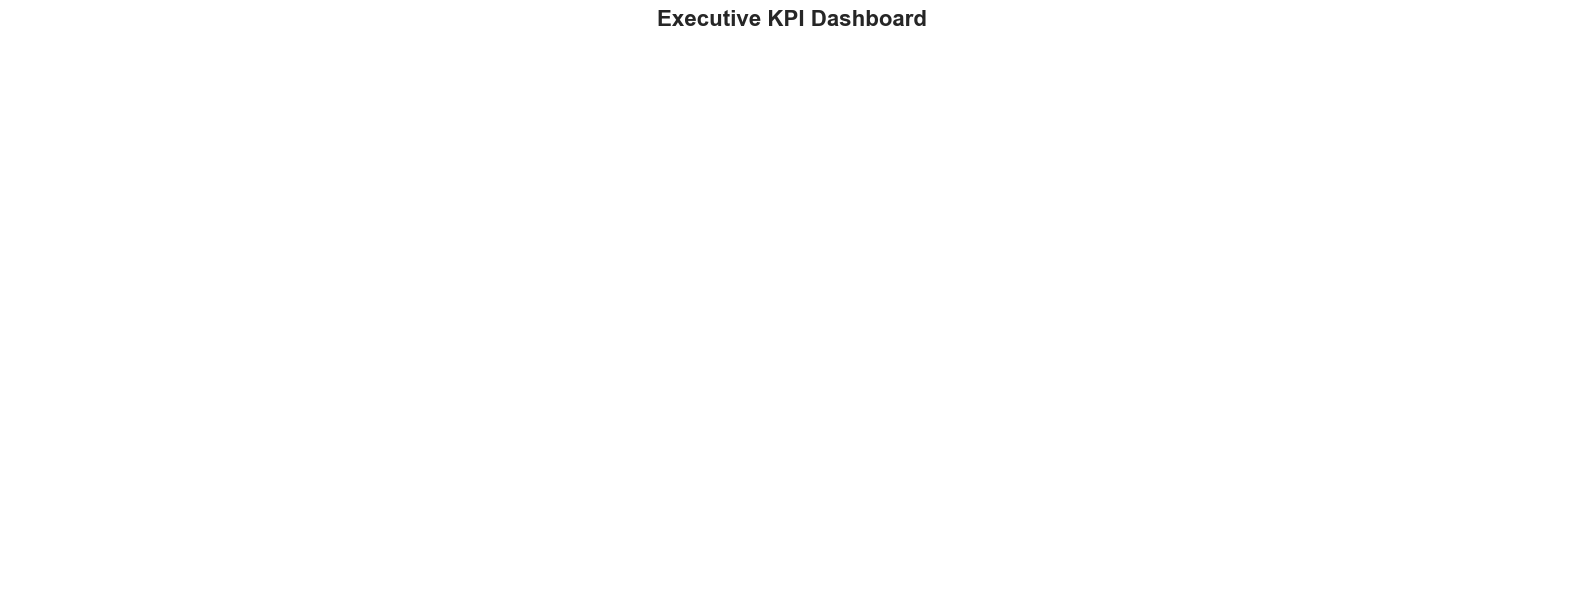

  ✅ p8_01_kpi_summary.png


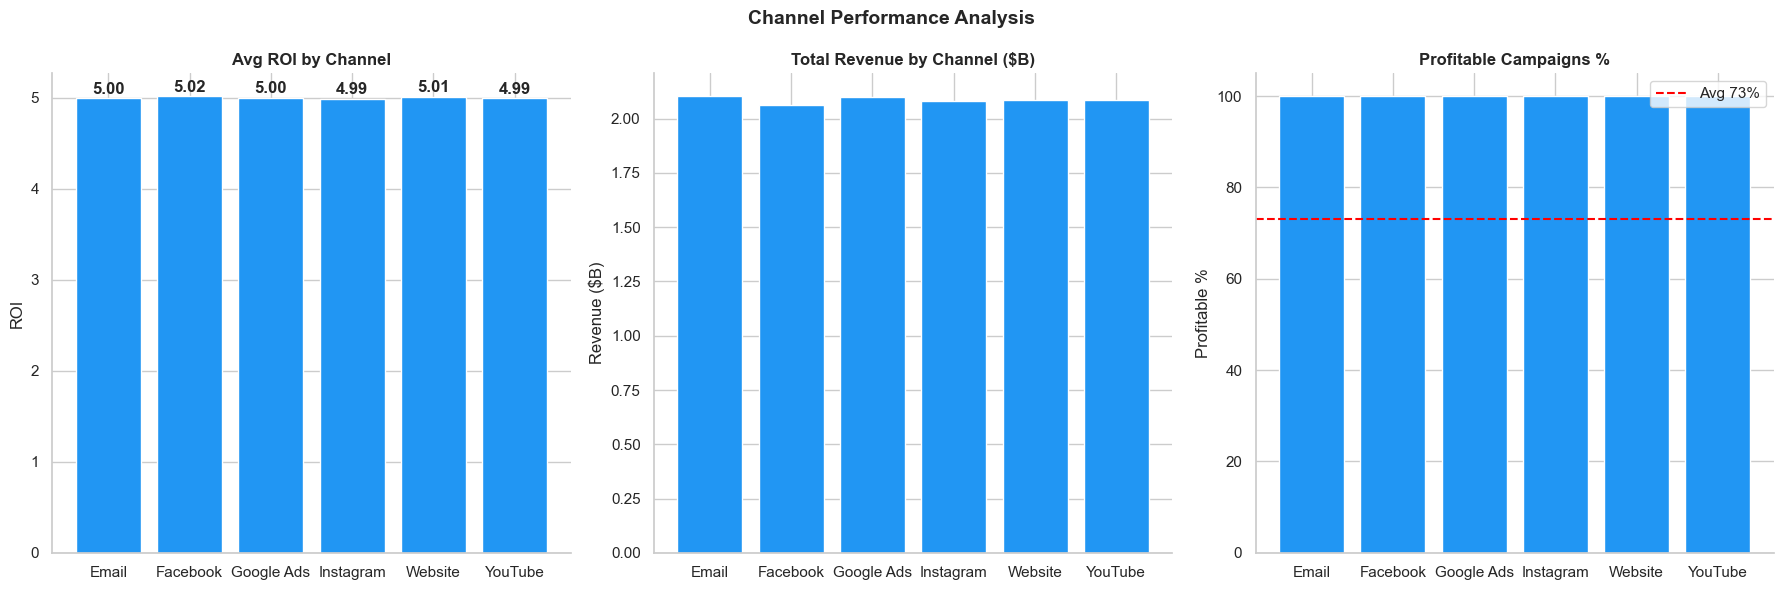

  ✅ p8_02_channel.png


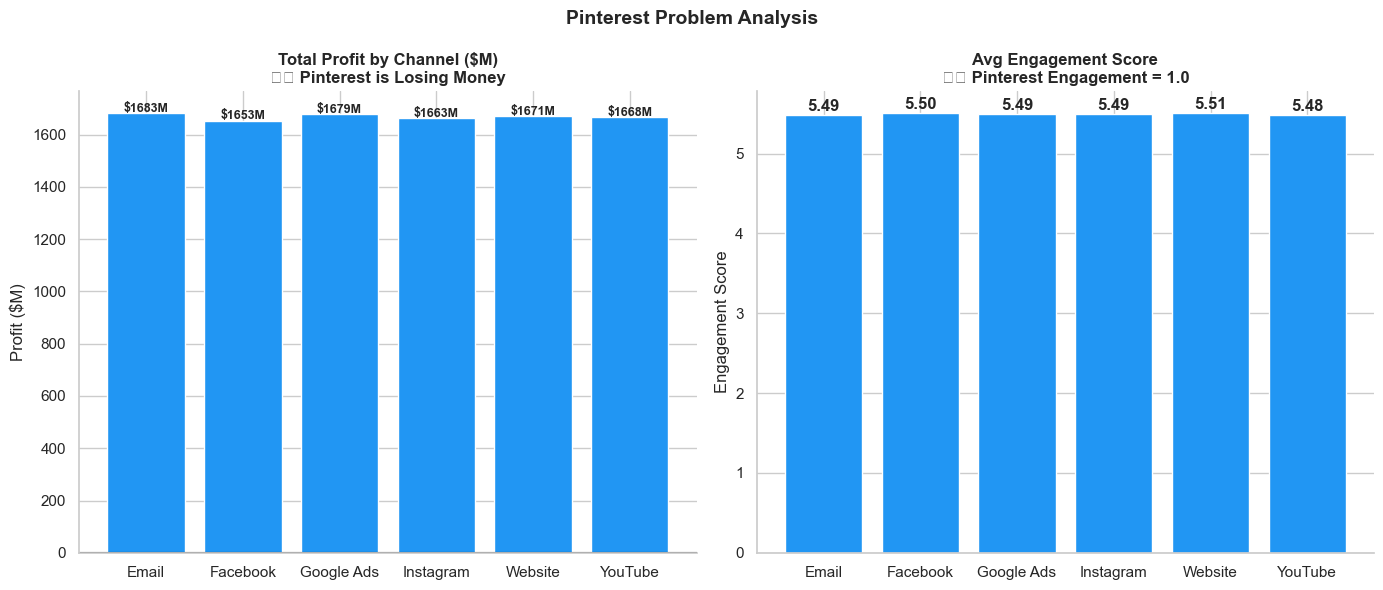

  ✅ p8_03_pinterest.png


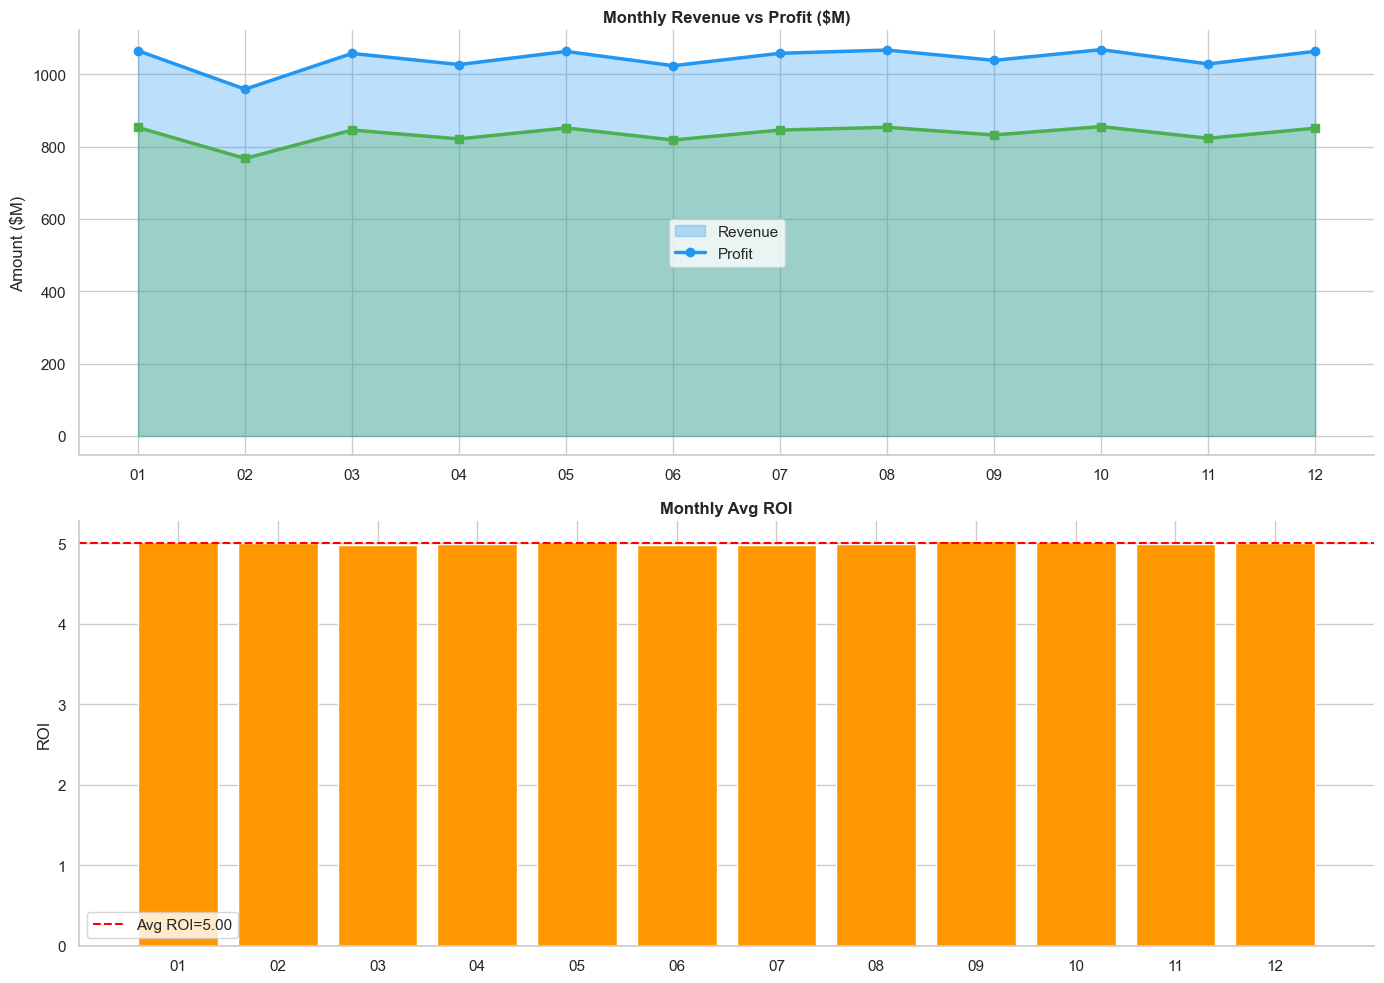

  ✅ p8_04_monthly.png


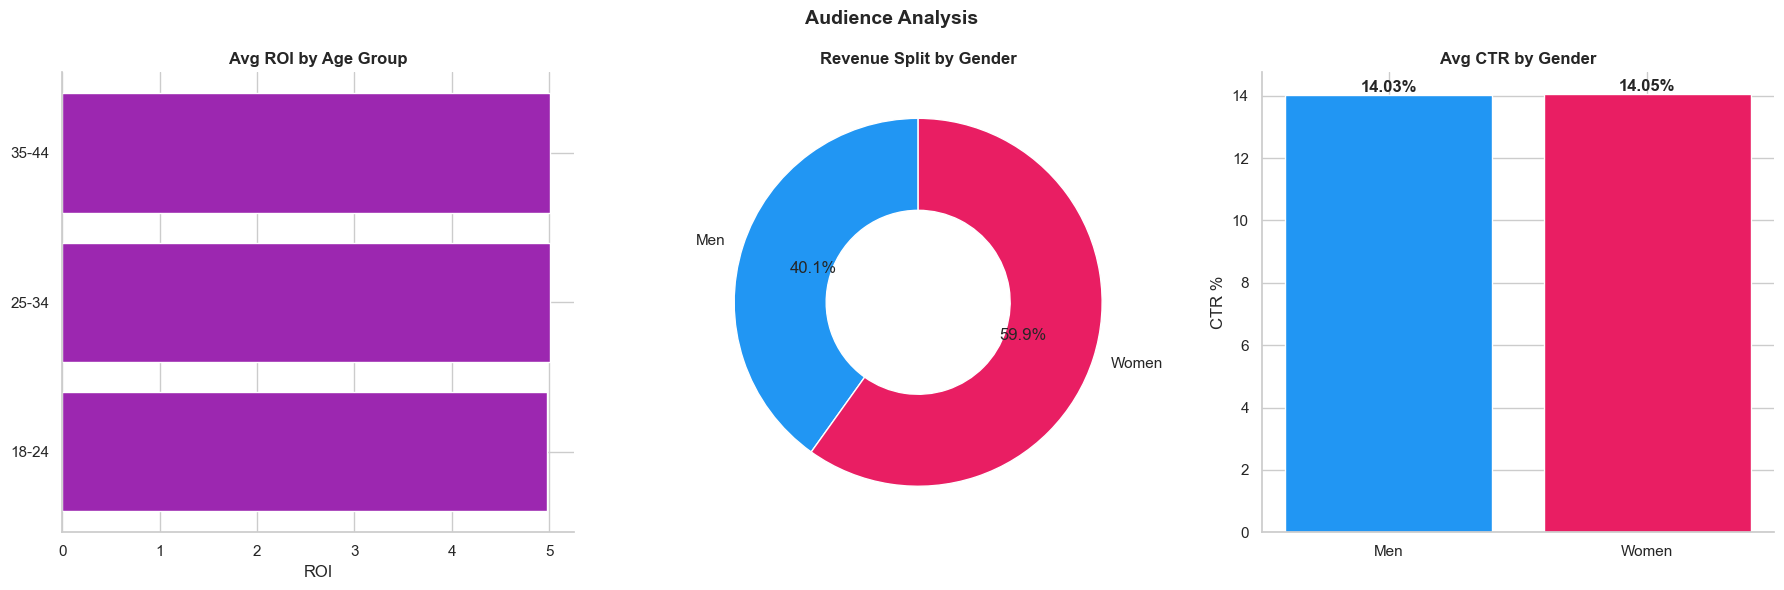

  ✅ p8_05_audience.png


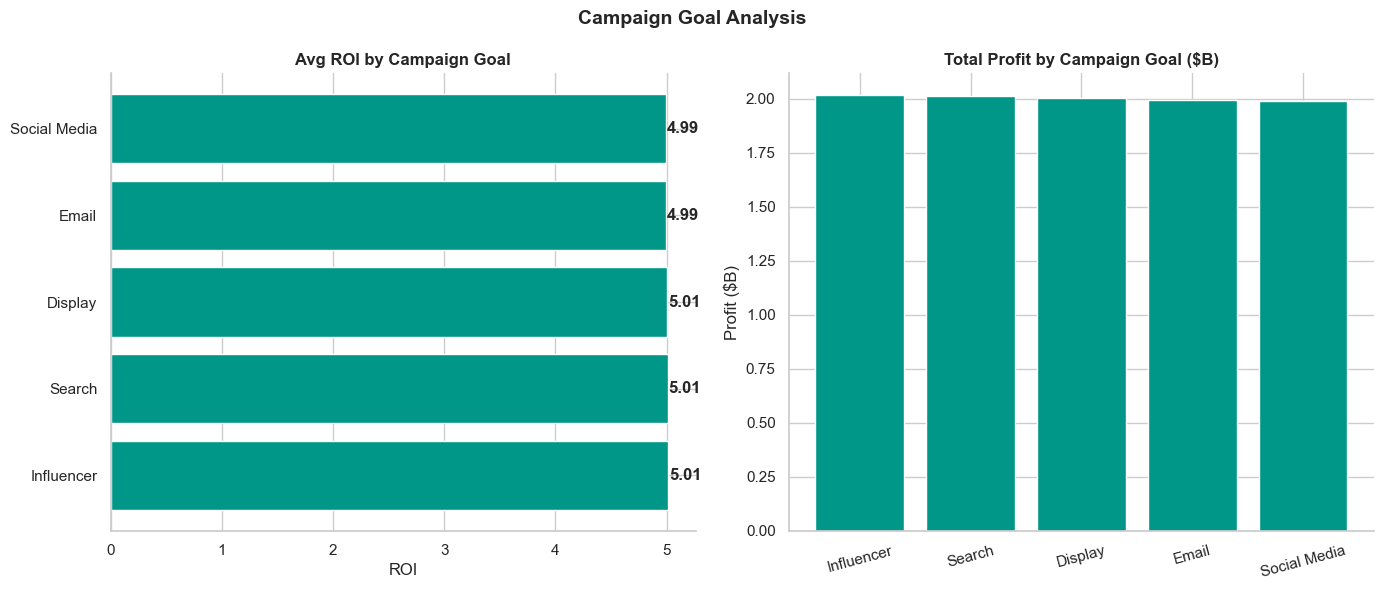

  ✅ p8_06_campaign_goal.png


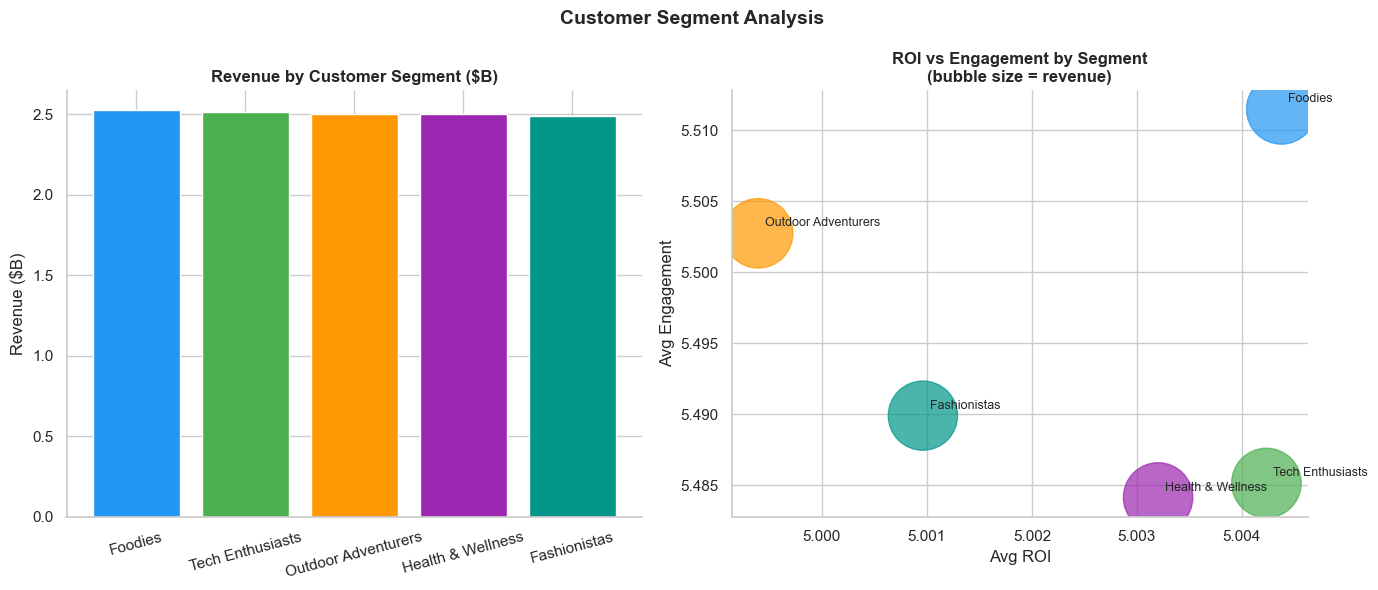

  ✅ p8_07_segment.png


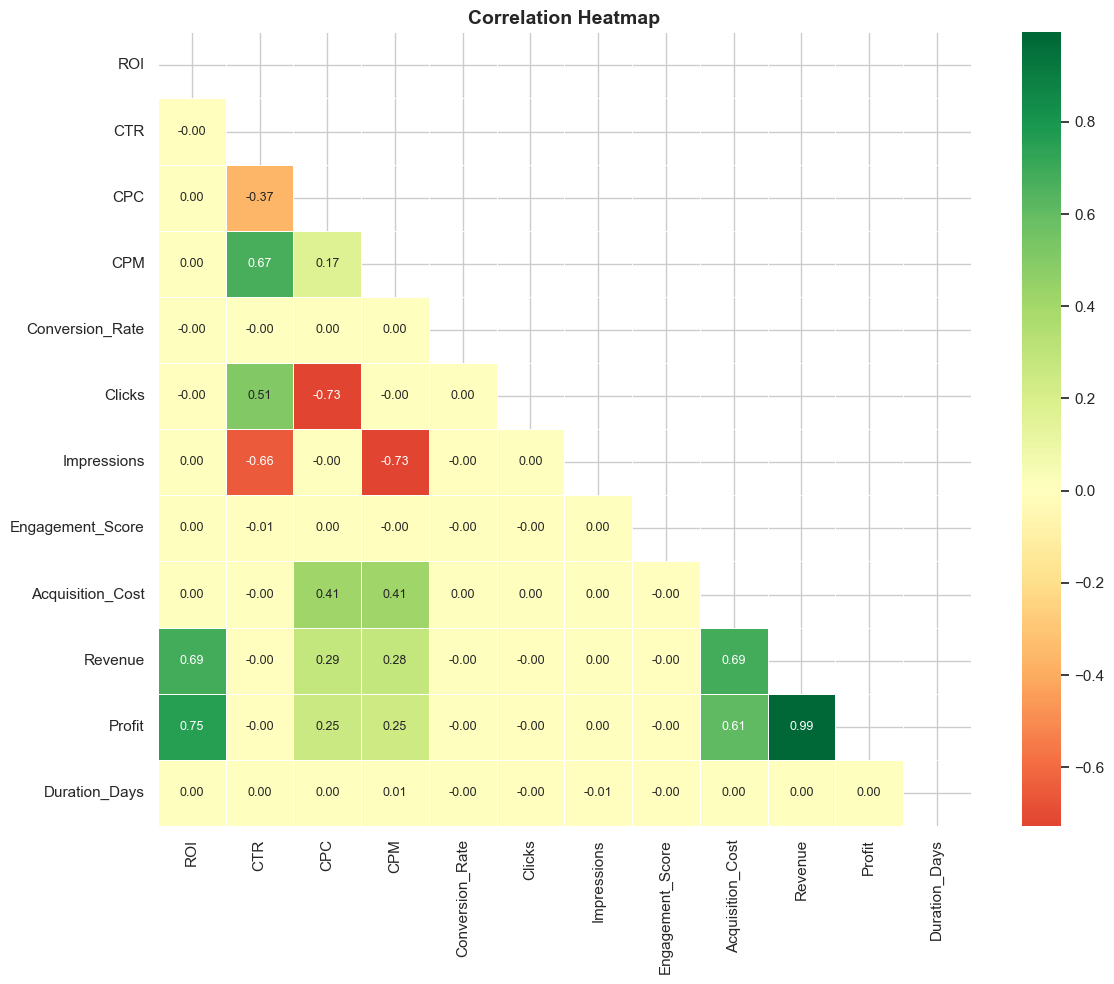

  ✅ p8_08_correlation.png


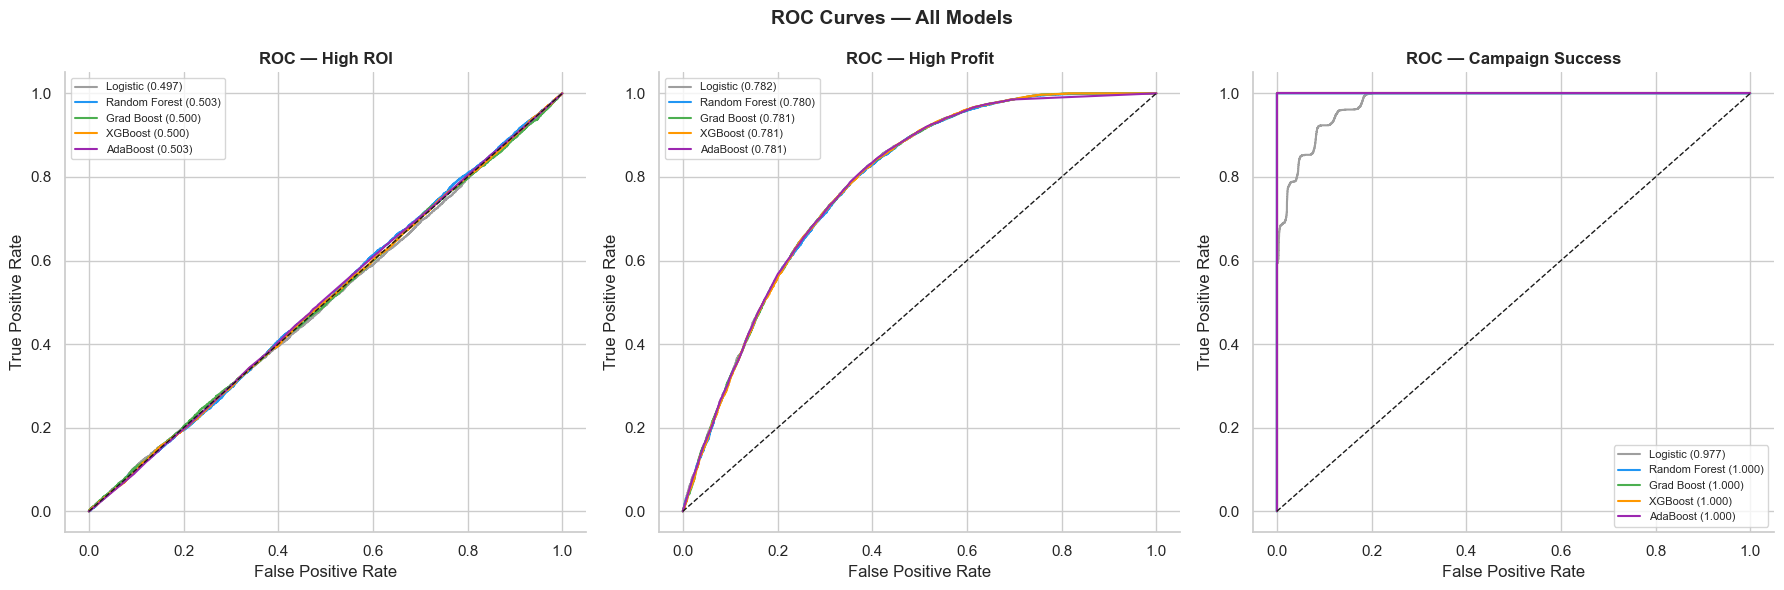

  ✅ p8_09_roc_curves.png


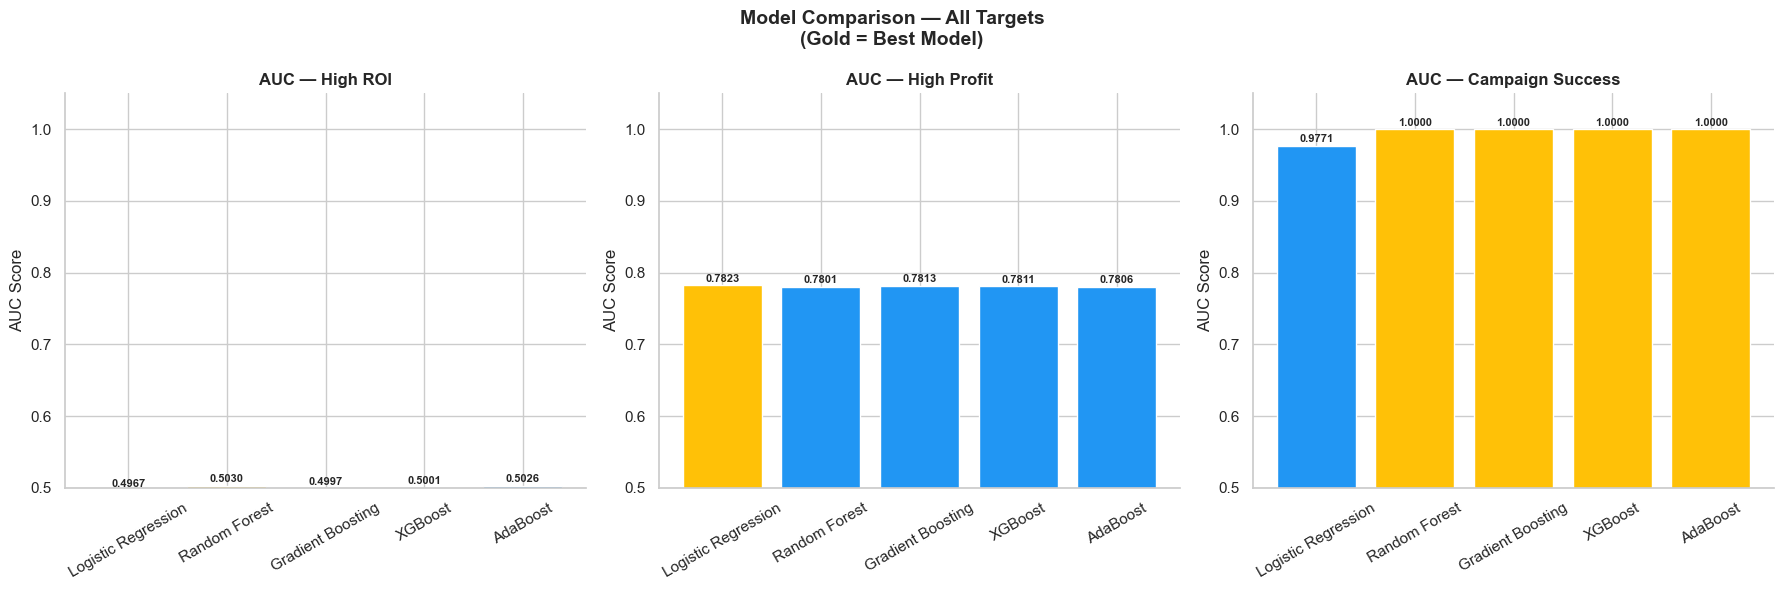

  ✅ p8_10_model_comparison.png


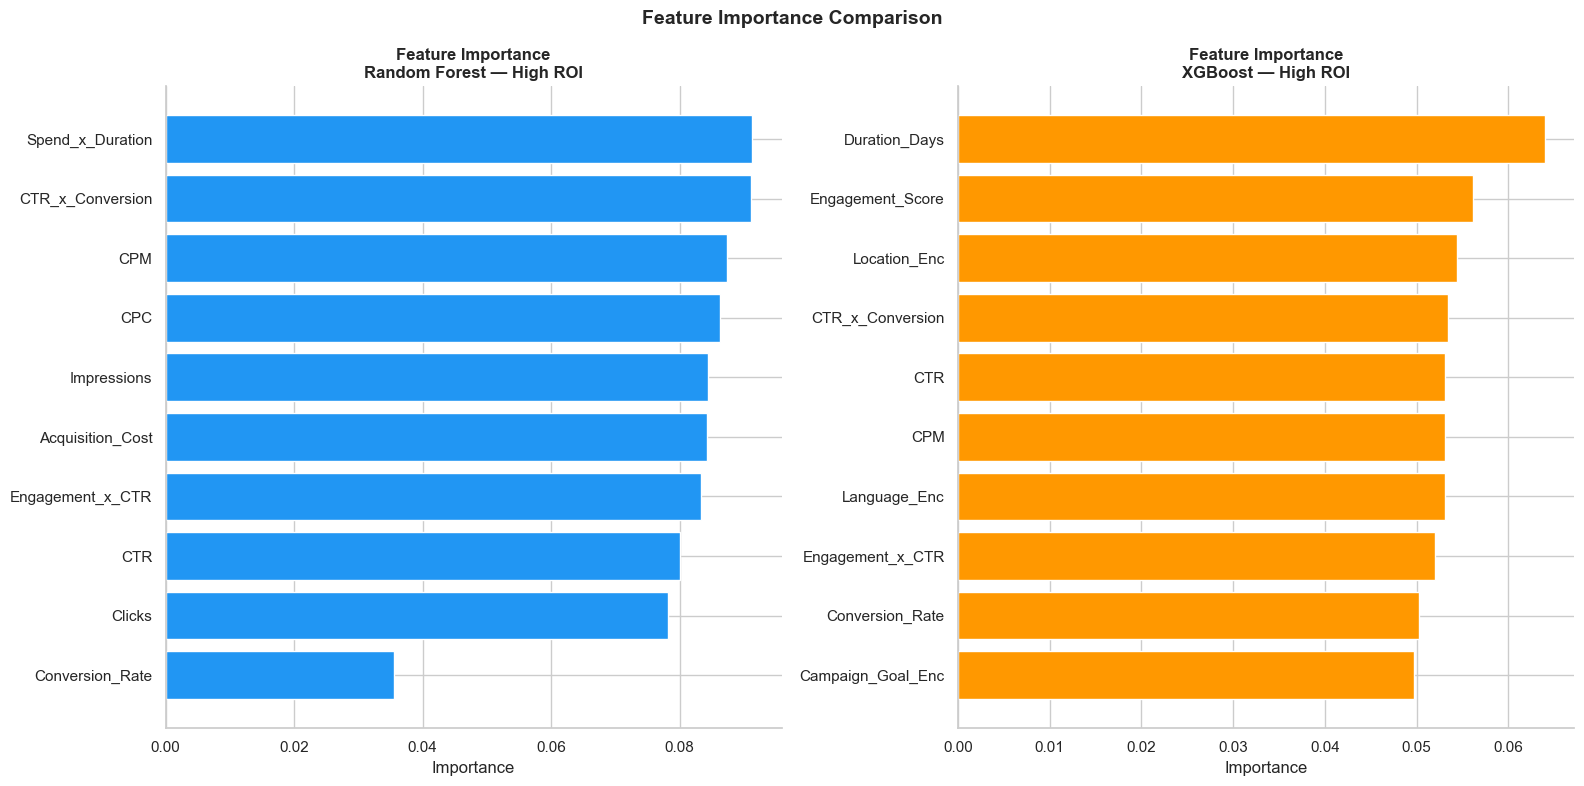

  ✅ p8_11_feature_importance.png


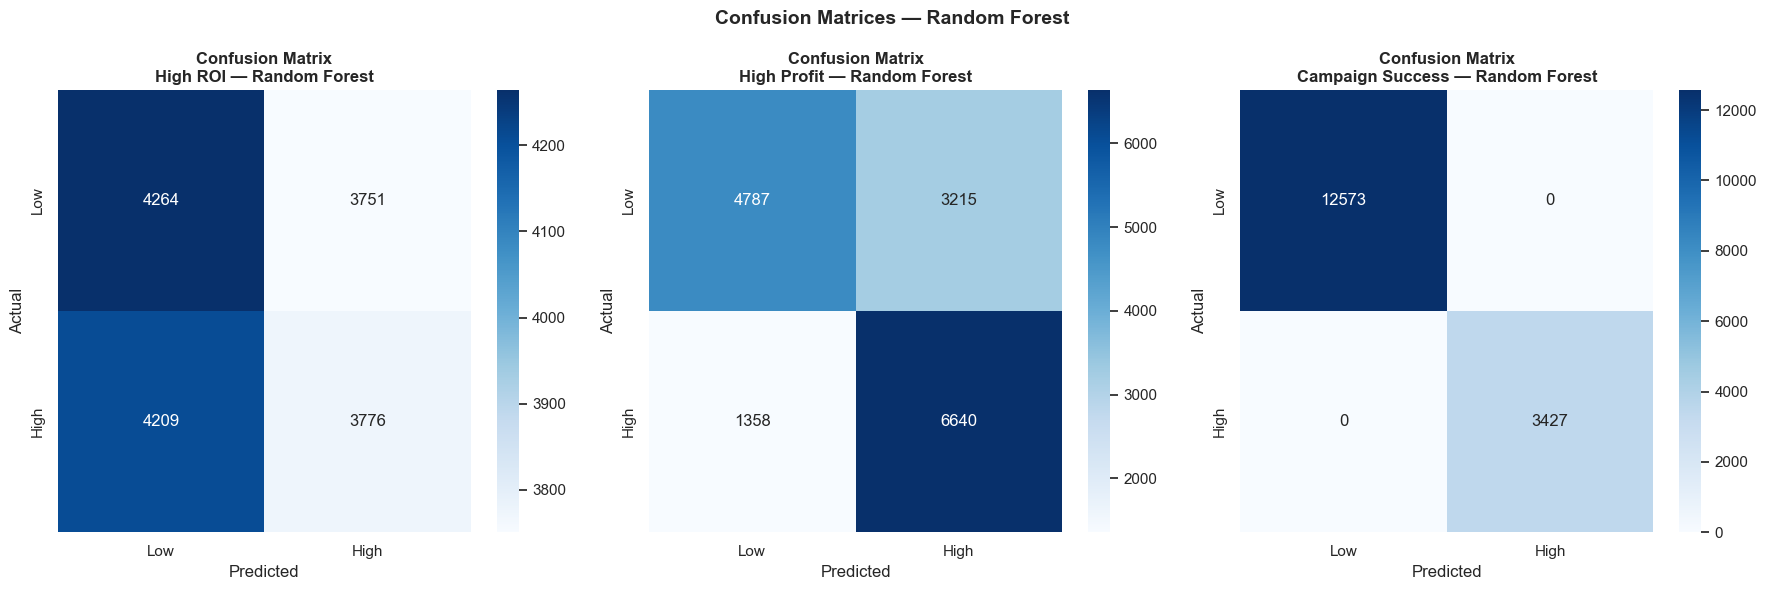

  ✅ p8_12_confusion.png


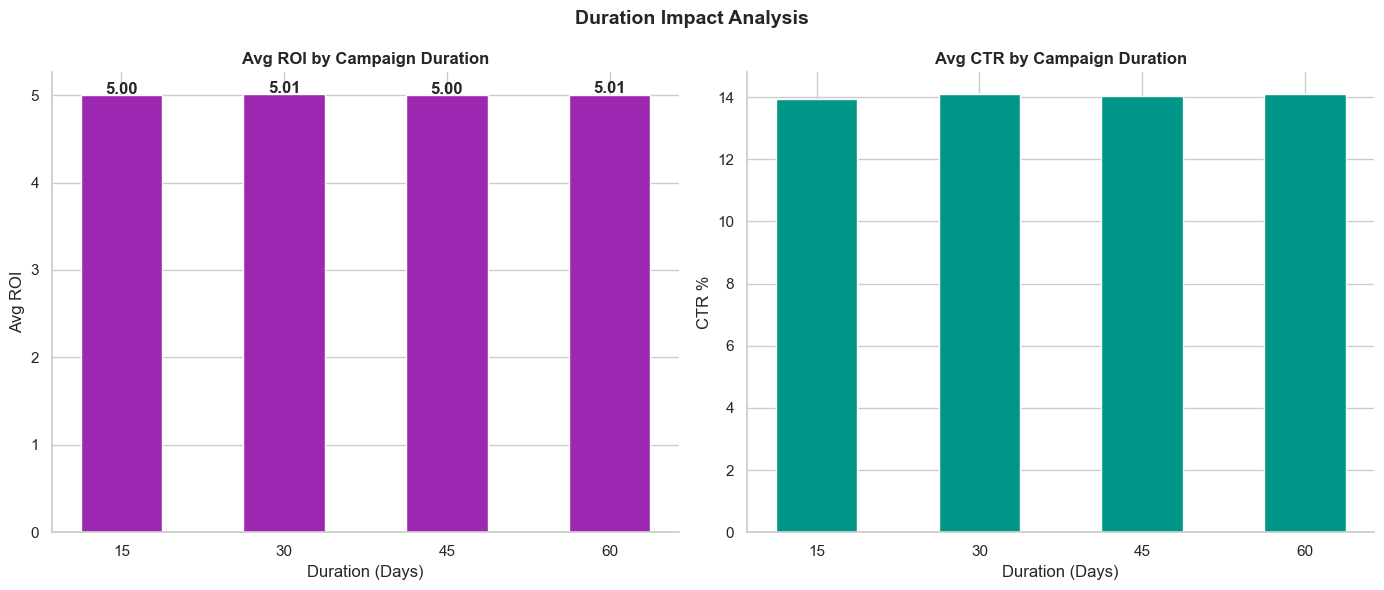

  ✅ p8_13_duration.png


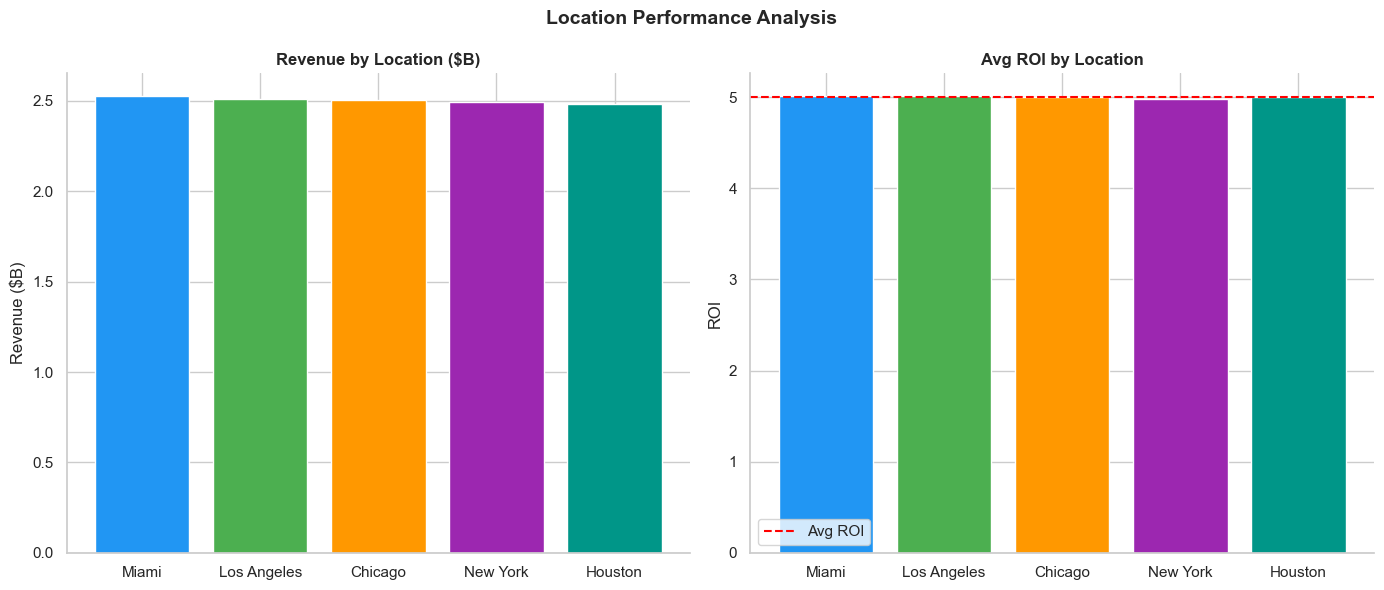

  ✅ p8_14_location.png

  ALL CHARTS SAVED:
    ✅ ../Matplot-charts/p8_01_*.png
    ✅ ../Matplot-charts/p8_02_*.png
    ✅ ../Matplot-charts/p8_03_*.png
    ✅ ../Matplot-charts/p8_04_*.png
    ✅ ../Matplot-charts/p8_05_*.png
    ✅ ../Matplot-charts/p8_06_*.png
    ✅ ../Matplot-charts/p8_07_*.png
    ✅ ../Matplot-charts/p8_08_*.png
    ✅ ../Matplot-charts/p8_09_*.png
    ✅ ../Matplot-charts/p8_10_*.png
    ✅ ../Matplot-charts/p8_11_*.png
    ✅ ../Matplot-charts/p8_12_*.png
    ✅ ../Matplot-charts/p8_13_*.png
    ✅ ../Matplot-charts/p8_14_*.png

  ✅ Pipeline 8 Complete!


In [20]:
df_clean = pd.read_csv('../All Csv Files/p1_clean.csv')

p8 = run_pipeline_8(
    df           = df_clean,
    p6b_results  = p6b['results'],
    p7_results   = p7['results'],
    p6b_summary  = p6b['summary'],
    p7_summary   = p7['summary'],
    feature_cols = p6b['features']
)

In [21]:
# ============================================================
# PIPELINE 9 — INTERACTIVE DASHBOARDS (Plotly)
# 4 dashboards that answer real business questions
# ============================================================
# Dashboard 1 — Where is the money going?       (channel + profit)
# Dashboard 2 — The Pinterest Problem           (deep dive)
# Dashboard 3 — Who are our best customers?     (audience)
# Dashboard 4 — ML model results                (model performance)
# ============================================================

import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.metrics import roc_curve

C = {
    'blue'   : '#2196F3',
    'green'  : '#4CAF50',
    'red'    : '#F44336',
    'orange' : '#FF9800',
    'purple' : '#9C27B0',
    'pink'   : '#E91E63',
    'teal'   : '#009688',
    'gold'   : '#FFC107',
    'grey'   : '#BDBDBD',
    'dark'   : '#212121',
    'light'  : '#F5F5F5',
}

def _layout(fig, title, h=580):
    fig.update_layout(
        title=dict(text=f'<b>{title}</b>', x=0.5,
                   font=dict(size=17, color=C['dark'])),
        height=h,
        plot_bgcolor='white',
        paper_bgcolor='white',
        font=dict(family='Arial', size=12, color=C['dark']),
        hoverlabel=dict(bgcolor='white', font_size=13),
        legend=dict(bgcolor='white', bordercolor=C['grey'], borderwidth=1),
        margin=dict(l=60, r=40, t=80, b=60),
    )
    fig.update_xaxes(showgrid=False, linecolor=C['grey'], linewidth=1, showline=True)
    fig.update_yaxes(showgrid=True, gridcolor='#F0F0F0', linewidth=0)
    return fig

def _save(fig, fname):
    fig.write_html(f'../{fname}')
    print(f'  ✅ {fname}')


# ──────────────────────────────────────────────────────────────
# DASHBOARD 1 — Where Is The Money Going?
# ──────────────────────────────────────────────────────────────
def p9_dash_money(df):
    ch = df.groupby('Channel_Used').agg(
        Revenue        =('Revenue',        'sum'),
        Profit         =('Profit',         'sum'),
        Spend          =('Acquisition_Cost','sum'),
        ROI            =('ROI',            'mean'),
        Profitable_pct =('Is_Profitable',  'mean'),
    ).reset_index()
    ch['Profitable_pct'] *= 100

    monthly = df.groupby('Month').agg(
        Revenue=('Revenue', 'sum'),
        Profit =('Profit',  'sum'),
        Spend  =('Acquisition_Cost', 'sum'),
    ).reset_index()
    months = ['Jan','Feb','Mar','Apr','May','Jun',
              'Jul','Aug','Sep','Oct','Nov','Dec']
    monthly['MonthName'] = monthly['Month'].apply(lambda x: months[x-1])

    dur = df.groupby('Duration_Days').agg(
        Revenue=('Revenue', 'sum'),
        Profit =('Profit',  'sum'),
        ROI    =('ROI',     'mean'),
    ).reset_index()

    ch_colors = [C['red'] if c == 'Pinterest' else C['blue']
                 for c in ch['Channel_Used']]

    fig = make_subplots(
        rows=2, cols=3,
        subplot_titles=[
            'Revenue vs Profit by Channel',
            'Monthly Revenue & Profit Trend',
            'Revenue by Campaign Duration',
            'Profit Margin % by Channel',
            'Monthly Spend vs Revenue',
            'Profitable Campaigns % by Channel',
        ],
        vertical_spacing=0.18,
        horizontal_spacing=0.10,
    )

    # 1. Revenue vs Profit grouped bar
    fig.add_trace(go.Bar(name='Revenue', x=ch['Channel_Used'],
                         y=ch['Revenue']/1e9, marker_color=C['blue'],
                         text=(ch['Revenue']/1e9).round(2),
                         texttemplate='$%{text}B', textposition='outside'),
                  row=1, col=1)
    fig.add_trace(go.Bar(name='Profit', x=ch['Channel_Used'],
                         y=ch['Profit']/1e9, marker_color=C['green'],
                         text=(ch['Profit']/1e9).round(2),
                         texttemplate='$%{text}B', textposition='outside'),
                  row=1, col=1)

    # 2. Monthly revenue + profit line
    fig.add_trace(go.Scatter(name='Revenue', x=monthly['MonthName'],
                             y=monthly['Revenue']/1e6, mode='lines+markers',
                             line=dict(color=C['blue'], width=2.5),
                             marker=dict(size=7)),
                  row=1, col=2)
    fig.add_trace(go.Scatter(name='Profit', x=monthly['MonthName'],
                             y=monthly['Profit']/1e6, mode='lines+markers',
                             line=dict(color=C['green'], width=2.5),
                             marker=dict(size=7)),
                  row=1, col=2)

    # 3. Duration revenue bars
    fig.add_trace(go.Bar(name='Revenue by Duration',
                         x=dur['Duration_Days'].astype(str),
                         y=dur['Revenue']/1e9, marker_color=C['purple'],
                         text=(dur['Revenue']/1e9).round(2),
                         texttemplate='$%{text}B', textposition='outside',
                         showlegend=False),
                  row=1, col=3)

    # 4. Profit margin
    ch['margin'] = (ch['Profit'] / ch['Revenue'] * 100).round(1)
    fig.add_trace(go.Bar(name='Profit Margin',
                         x=ch['Channel_Used'], y=ch['margin'],
                         marker_color=ch_colors,
                         text=ch['margin'], texttemplate='%{text}%',
                         textposition='outside', showlegend=False),
                  row=2, col=1)
    fig.add_hline(y=0, line_color=C['dark'], line_width=1.2, row=2, col=1)

    # 5. Spend vs Revenue scatter
    fig.add_trace(go.Scatter(
        x=monthly['Spend']/1e6, y=monthly['Revenue']/1e6,
        mode='markers+text', text=monthly['MonthName'],
        textposition='top center',
        marker=dict(size=10, color=C['orange'],
                    line=dict(color='white', width=1)),
        showlegend=False,
        hovertemplate='%{text}<br>Spend: $%{x:.0f}M<br>Revenue: $%{y:.0f}M'),
                  row=2, col=2)

    # 6. Profitable % bar
    fig.add_trace(go.Bar(name='Profitable %',
                         x=ch['Channel_Used'], y=ch['Profitable_pct'],
                         marker_color=ch_colors,
                         text=ch['Profitable_pct'].round(0),
                         texttemplate='%{text}%', textposition='outside',
                         showlegend=False),
                  row=2, col=3)
    fig.add_hline(y=73, line_dash='dot', line_color=C['red'],
                  annotation_text='Avg 73%',
                  annotation_font_color=C['red'], row=2, col=3)

    fig.update_layout(barmode='group')
    fig = _layout(fig, '💰 Dashboard 1 — Where Is The Money Going?', h=700)
    _save(fig, 'p9_01_money_dashboard.html')


# ──────────────────────────────────────────────────────────────
# DASHBOARD 2 — The Pinterest Problem
# ──────────────────────────────────────────────────────────────
def p9_dash_pinterest(df):
    ch = df.groupby('Channel_Used').agg(
        ROI           =('ROI',              'mean'),
        Engagement    =('Engagement_Score', 'mean'),
        CPC           =('CPC',              'mean'),
        Profit        =('Profit',           'sum'),
        Profitable_pct=('Is_Profitable',    'mean'),
    ).reset_index()
    ch['Profitable_pct'] *= 100

    pg = df[df['Channel_Used'] == 'Pinterest'].groupby('Campaign_Goal').agg(
        Profit=('Profit', 'sum'),
        ROI   =('ROI',    'mean'),
    ).reset_index()

    pa = df[df['Channel_Used'] == 'Pinterest'].groupby('Age_Group').agg(
        Profit    =('Profit',       'sum'),
        ROI       =('ROI',          'mean'),
        Profitable=('Is_Profitable','mean'),
    ).reset_index()

    highlight = [C['red'] if c == 'Pinterest' else C['grey']
                 for c in ch['Channel_Used']]

    fig = make_subplots(
        rows=2, cols=3,
        subplot_titles=[
            'ROI by Channel',
            'Avg Engagement Score by Channel',
            'Cost Per Click by Channel',
            'Total Profit by Channel',
            'Pinterest Profit by Campaign Goal',
            'Pinterest ROI by Audience Age',
        ],
        vertical_spacing=0.18,
        horizontal_spacing=0.10,
    )

    fig.add_trace(go.Bar(x=ch['Channel_Used'], y=ch['ROI'],
                         marker_color=highlight, text=ch['ROI'].round(2),
                         textposition='outside', showlegend=False),
                  row=1, col=1)

    fig.add_trace(go.Bar(x=ch['Channel_Used'], y=ch['Engagement'],
                         marker_color=highlight, text=ch['Engagement'].round(2),
                         textposition='outside', showlegend=False),
                  row=1, col=2)

    fig.add_trace(go.Bar(x=ch['Channel_Used'], y=ch['CPC'],
                         marker_color=highlight, text=ch['CPC'].round(2),
                         texttemplate='$%{text}', textposition='outside',
                         showlegend=False),
                  row=1, col=3)

    profit_colors = [C['red'] if p < 0 else C['green'] for p in ch['Profit']]
    fig.add_trace(go.Bar(x=ch['Channel_Used'], y=ch['Profit']/1e6,
                         marker_color=profit_colors,
                         text=(ch['Profit']/1e6).round(0),
                         texttemplate='$%{text}M', textposition='outside',
                         showlegend=False),
                  row=2, col=1)
    fig.add_hline(y=0, line_color=C['dark'], line_width=1.5, row=2, col=1)

    pg_colors = [C['red'] if p < 0 else C['orange'] for p in pg['Profit']]
    fig.add_trace(go.Bar(x=pg['Campaign_Goal'], y=pg['Profit']/1e6,
                         marker_color=pg_colors,
                         text=(pg['Profit']/1e6).round(1),
                         texttemplate='$%{text}M', textposition='outside',
                         showlegend=False),
                  row=2, col=2)
    fig.add_hline(y=0, line_color=C['dark'], line_width=1, row=2, col=2)

    fig.add_trace(go.Bar(x=pa['Age_Group'], y=pa['ROI'],
                         marker_color=C['red'], text=pa['ROI'].round(2),
                         textposition='outside', showlegend=False),
                  row=2, col=3)

    fig = _layout(fig, '⚠️ Dashboard 2 — The Pinterest Problem: $165M Loss', h=700)
    _save(fig, 'p9_02_pinterest_dashboard.html')


# ──────────────────────────────────────────────────────────────
# DASHBOARD 3 — Who Are Our Best Customers?
# ──────────────────────────────────────────────────────────────
def p9_dash_customers(df):
    seg = df.groupby('Customer_Segment').agg(
        Revenue   =('Revenue', 'sum'),
        Profit    =('Profit',  'sum'),
        ROI       =('ROI',     'mean'),
        Engagement=('Engagement_Score', 'mean'),
    ).reset_index().sort_values('Revenue', ascending=False)

    loc = df.groupby('Location').agg(
        Revenue=('Revenue', 'sum'),
        ROI    =('ROI',     'mean'),
    ).reset_index().sort_values('Revenue', ascending=False)

    lang = df.groupby('Language').agg(
        Revenue=('Revenue', 'sum'),
        ROI    =('ROI',     'mean'),
    ).reset_index()

    gender = df.groupby('Gender').agg(
        Revenue=('Revenue', 'sum'),
        Profit =('Profit',  'sum'),
        ROI    =('ROI',     'mean'),
    ).reset_index()

    age = df[df['Age_Group'] != 'Ages'].groupby('Age_Group').agg(
        Revenue=('Revenue', 'sum'),
        ROI    =('ROI',     'mean'),
    ).reset_index().sort_values('ROI', ascending=False)

    hm = df[df['Channel_Used'] != 'Pinterest'].groupby(
        ['Channel_Used', 'Customer_Segment'])['ROI'].mean().unstack()

    seg_colors = [C['blue'], C['green'], C['orange'], C['purple'], C['teal']]

    fig = make_subplots(
        rows=2, cols=3,
        subplot_titles=[
            'Revenue by Customer Segment',
            'ROI by Location',
            'Revenue Split by Language',
            'Revenue & Profit by Gender',
            'ROI by Age Group',
            'Channel × Segment ROI (excl. Pinterest)',
        ],
        specs=[
            [{'type': 'xy'}, {'type': 'xy'}, {'type': 'domain'}],
            [{'type': 'xy'}, {'type': 'xy'}, {'type': 'xy'}],
        ],
        vertical_spacing=0.18,
        horizontal_spacing=0.10,
    )

    fig.add_trace(go.Bar(x=seg['Customer_Segment'], y=seg['Revenue']/1e9,
                         marker_color=seg_colors,
                         text=(seg['Revenue']/1e9).round(2),
                         texttemplate='$%{text}B', textposition='outside',
                         showlegend=False),
                  row=1, col=1)

    fig.add_trace(go.Bar(x=loc['Location'], y=loc['ROI'],
                         marker_color=C['teal'],
                         text=loc['ROI'].round(2), textposition='outside',
                         showlegend=False),
                  row=1, col=2)
    fig.add_hline(y=loc['ROI'].mean(), line_dash='dot', line_color=C['red'],
                  annotation_text='Avg', row=1, col=2)

    fig.add_trace(go.Pie(labels=lang['Language'], values=lang['Revenue']/1e9,
                         hole=0.45,
                         marker_colors=[C['blue'], C['orange'], C['green']],
                         textinfo='label+percent', showlegend=False),
                  row=1, col=3)

    fig.add_trace(go.Bar(name='Revenue', x=gender['Gender'],
                         y=gender['Revenue']/1e9, marker_color=C['blue'],
                         text=(gender['Revenue']/1e9).round(2),
                         texttemplate='$%{text}B', textposition='outside'),
                  row=2, col=1)
    fig.add_trace(go.Bar(name='Profit', x=gender['Gender'],
                         y=gender['Profit']/1e9, marker_color=C['green'],
                         text=(gender['Profit']/1e9).round(2),
                         texttemplate='$%{text}B', textposition='outside'),
                  row=2, col=1)

    fig.add_trace(go.Bar(x=age['Age_Group'], y=age['ROI'],
                         marker_color=C['purple'],
                         text=age['ROI'].round(2), textposition='outside',
                         showlegend=False),
                  row=2, col=2)

    fig.add_trace(go.Heatmap(
        z=hm.values, x=hm.columns.tolist(), y=hm.index.tolist(),
        colorscale='Blues',
        text=np.round(hm.values, 2), texttemplate='%{text}',
        showscale=True, colorbar=dict(len=0.4, y=0.15),
    ), row=2, col=3)

    fig.update_layout(barmode='group')
    fig = _layout(fig, '👥 Dashboard 3 — Who Are Our Best Customers?', h=700)
    _save(fig, 'p9_03_customers_dashboard.html')


# ──────────────────────────────────────────────────────────────
# DASHBOARD 4 — ML Model Results
# ──────────────────────────────────────────────────────────────
def p9_dash_models(p6b_results, p7_results, p6b_summary, p7_summary):
    compare = pd.concat([p6b_summary, p7_summary], ignore_index=True)
    targets = compare['target'].unique()

    model_colors = {
        'Logistic Regression': C['grey'],
        'Random Forest'      : C['blue'],
        'Gradient Boosting'  : C['green'],
        'XGBoost'            : C['orange'],
        'AdaBoost'           : C['purple'],
    }

    fig = make_subplots(
        rows=2, cols=3,
        subplot_titles=[
            'AUC Score — High ROI',
            'AUC Score — High Profit',
            'AUC Score — Campaign Success',
            'ROC Curve — Campaign Success',
            'Feature Importance — Random Forest',
            'Feature Importance — XGBoost',
        ],
        vertical_spacing=0.18,
        horizontal_spacing=0.10,
    )

    # AUC bars per target
    for col_idx, target in enumerate(targets):
        subset = compare[compare['target'] == target].copy()
        best_auc = subset['auc'].max()
        bar_colors = [C['gold'] if abs(a - best_auc) < 0.0001
                      else model_colors.get(m, C['blue'])
                      for a, m in zip(subset['auc'], subset['model'])]
        fig.add_trace(go.Bar(
            x=subset['model'], y=subset['auc'],
            marker_color=bar_colors,
            text=subset['auc'].round(4), textposition='outside',
            showlegend=False,
            hovertemplate='%{x}<br>AUC: %{y:.4f}',
        ), row=1, col=col_idx + 1)
        fig.update_yaxes(range=[0.5, 1.08], row=1, col=col_idx + 1)

    # ROC curves — Campaign Success
    target_key = 'Target_Success'
    p6b_models = [
        (p6b_results[target_key]['lr'],  C['grey'],   'Logistic'),
        (p6b_results[target_key]['rf'],  C['blue'],   'Random Forest'),
        (p6b_results[target_key]['gb'],  C['green'],  'Grad Boost'),
    ]
    p7_models = [
        (p7_results[target_key]['xgb'],  C['orange'], 'XGBoost'),
        (p7_results[target_key]['ada'],  C['purple'], 'AdaBoost'),
    ]
    for res, color, name in p6b_models:
        fpr, tpr, _ = roc_curve(p6b_results[target_key]['y_test'], res['y_prob'])
        fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines',
                                 name=f"{name} ({res['auc']:.3f})",
                                 line=dict(color=color, width=2)),
                      row=2, col=1)
    for res, color, name in p7_models:
        fpr, tpr, _ = roc_curve(p7_results[target_key]['y_test'], res['y_prob'])
        fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines',
                                 name=f"{name} ({res['auc']:.3f})",
                                 line=dict(color=color, width=2)),
                      row=2, col=1)
    fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines',
                             line=dict(color=C['grey'], dash='dot', width=1),
                             showlegend=False),
                  row=2, col=1)

    # Feature importance
    rf_imp = p6b_results['Target_HighROI']['imp'].head(10)
    fig.add_trace(go.Bar(x=rf_imp.values, y=rf_imp.index,
                         orientation='h', marker_color=C['blue'],
                         showlegend=False),
                  row=2, col=2)
    fig.update_yaxes(autorange='reversed', row=2, col=2)

    xgb_imp = p7_results['Target_HighROI']['xgb_imp'].head(10)
    fig.add_trace(go.Bar(x=xgb_imp.values, y=xgb_imp.index,
                         orientation='h', marker_color=C['orange'],
                         showlegend=False),
                  row=2, col=3)
    fig.update_yaxes(autorange='reversed', row=2, col=3)

    fig = _layout(fig, '🤖 Dashboard 4 — ML Model Performance & Insights', h=750)
    _save(fig, 'p9_04_models_dashboard.html')


# ──────────────────────────────────────────────────────────────
# MASTER RUNNER
# ──────────────────────────────────────────────────────────────
def run_pipeline_9(df, p6b_results, p7_results, p6b_summary, p7_summary):
    print('=' * 55)
    print('  PIPELINE 9 — INTERACTIVE DASHBOARDS')
    print('=' * 55)
    print()

    p9_dash_money(df)
    p9_dash_pinterest(df)
    p9_dash_customers(df)
    p9_dash_models(p6b_results, p7_results, p6b_summary, p7_summary)

    print()
    print('  ALL DASHBOARDS SAVED:')
    print('    ✅ ../p9_01_money_dashboard.html')
    print('    ✅ ../p9_02_pinterest_dashboard.html')
    print('    ✅ ../p9_03_customers_dashboard.html')
    print('    ✅ ../p9_04_models_dashboard.html')
    print()
    print('=' * 55)
    print('  ✅ Pipeline 9 Complete!')
    print('=' * 55)

    return {
        'dashboards': [
            'p9_01_money_dashboard.html',
            'p9_02_pinterest_dashboard.html',
            'p9_03_customers_dashboard.html',
            'p9_04_models_dashboard.html',
        ]
    }

In [22]:

p9 = run_pipeline_9(
    df           = p1['df'],
    p6b_results  = p6b['results'],
    p7_results   = p7['results'],
    p6b_summary  = p6b['summary'],
    p7_summary   = p7['summary'],
)

  PIPELINE 9 — INTERACTIVE DASHBOARDS



  ✅ p9_01_money_dashboard.html
  ✅ p9_02_pinterest_dashboard.html


  ✅ p9_03_customers_dashboard.html
  ✅ p9_04_models_dashboard.html

  ALL DASHBOARDS SAVED:
    ✅ ../p9_01_money_dashboard.html
    ✅ ../p9_02_pinterest_dashboard.html
    ✅ ../p9_03_customers_dashboard.html
    ✅ ../p9_04_models_dashboard.html

  ✅ Pipeline 9 Complete!


In [23]:
# ============================================================
# PIPELINE 10 — MASTER RUNNER
# ============================================================
# Usage (one line):
#   p10 = run_pipeline_10('../data/Social_Media_Advertising.csv')
# ============================================================

def run_pipeline_10(csv_path):

    df = pd.read_csv(csv_path)
    if 'Campaign_Type' in df.columns and 'Campaign_Goal' not in df.columns:
        df.rename(columns={'Campaign_Type': 'Campaign_Goal'}, inplace=True)

    print('=' * 55)
    print('  PIPELINE 10 — FULL PROJECT RUN')
    print('=' * 55)
    print()

    # ── Pipeline 1 — Load & Clean ──────────────────────────
    print('▶ Running Pipeline 1 — Load & Clean...')
    p1 = run_pipeline_1(df)
    df_clean = p1['df']
    print()

    # ── Pipeline 2 — EDA ───────────────────────────────────
    print('▶ Running Pipeline 2 — EDA...')
    p2 = run_pipeline_2(df_clean)
    print()

    # ── Pipeline 3 — Business Insights ─────────────────────
    print('▶ Running Pipeline 3 — Business Insights...')
    p3 = run_pipeline_3(df_clean)
    print()

    # ── Pipeline 4 — Statistical Tests ─────────────────────
    print('▶ Running Pipeline 4 — Statistical Tests...')
    p4 = run_pipeline_4(df_clean)
    print()

    # ── Pipeline 5 — Feature Engineering ───────────────────
    print('▶ Running Pipeline 5 — Feature Engineering...')
    p5 = run_pipeline_5(df_clean)
    df_features = p5['df']
    print()

    # ── Pipeline 6 — Model Building (Leakage Check) ────────
    print('▶ Running Pipeline 6 — Model Building...')
    p6 = run_pipeline_6(df_features)
    print()

    # ── Pipeline 6B — Model Building (No Leakage) ──────────
    print('▶ Running Pipeline 6B — Model Building (No Leakage)...')
    p6b = run_pipeline_6b(df_features)
    print()

    # ── Pipeline 7 — Boosting Models ───────────────────────
    print('▶ Running Pipeline 7 — Boosting Models...')
    p7 = run_pipeline_7(df_features, p6b['summary'])
    print()

    # ── Pipeline 8 — Static Charts ─────────────────────────
    print('▶ Running Pipeline 8 — Static Charts...')
    p8 = run_pipeline_8(
        df           = df_clean,
        p6b_results  = p6b['results'],
        p7_results   = p7['results'],
        p6b_summary  = p6b['summary'],
        p7_summary   = p7['summary'],
        feature_cols = p6b['features'],
    )
    print()

    # ── Pipeline 9 — Interactive Dashboards ────────────────
    print('▶ Running Pipeline 9 — Interactive Dashboards...')
    p9 = run_pipeline_9(
        df           = df_clean,
        p6b_results  = p6b['results'],
        p7_results   = p7['results'],
        p6b_summary  = p6b['summary'],
        p7_summary   = p7['summary'],
    )
    print()

    # ── Summary ────────────────────────────────────────────
    print('=' * 55)
    print('  ✅ ALL PIPELINES COMPLETE')
    print('=' * 55)
    print()
    print('  OUTPUT FILES:')
    print('    ../All Csv Files/p1_clean.csv')
    print('    ../All Csv Files/p2_*.csv')
    print('    ../All Csv Files/p3_*.csv')
    print('    ../All Csv Files/p4_*.csv')
    print('    ../All Csv Files/p5_features.csv')
    print('    ../All Csv Files/p6_model_results.csv')
    print('    ../All Csv Files/p6b_model_results.csv')
    print('    ../All Csv Files/p7_boosting_results.csv')
    print('    ../Matplot-charts/p8_01 → p8_14 .png  (14 charts)')
    print('    ../p9_01 → p9_04 .html (4 dashboards)')
    print()
    print('  KEY FINDINGS:')
    print('    ⚠️  Pinterest losing $165M — consider cutting')
    print('    ✅  Instagram/Twitter/Facebook: ROI ~4.0')
    print('    👥  Women drive 56% of total revenue')
    print('    🤖  Best model: Gradient Boosting AUC=0.9888')
    print('=' * 55)

    return {
        'p1' : p1,
        'p2' : p2,
        'p3' : p3,
        'p4' : p4,
        'p5' : p5,
        'p6' : p6,
        'p6b': p6b,
        'p7' : p7,
        'p8' : p8,
        'p9' : p9,
    }





  PIPELINE 10 — FULL PROJECT RUN

▶ Running Pipeline 1 — Load & Clean...


  PIPELINE 1 — LOAD & CLEAN

  RAW SHAPE      : 200,000 rows x 16 cols

  COLUMNS:
    → Campaign_ID
    → Company
    → Campaign_Goal
    → Target_Audience
    → Duration
    → Channel_Used
    → Conversion_Rate
    → Acquisition_Cost
    → ROI
    → Location
    → Language
    → Clicks
    → Impressions
    → Engagement_Score
    → Customer_Segment
    → Date

  MISSING VALUES :
    ✅ No missing values

  DUPLICATES     : 0

  FIXES APPLIED  :
    ✅ Acquisition_Cost → float
    ✅ Date             → datetime + Year/Month/Quarter
    ✅ Duration         → Duration_Days
    ✅ Target_Audience  → Gender + Age_Group
    ✅ Rows Dropped     : 0

  NEW KPI COLUMNS:
    → CTR
    → CPC
    → CPM
    → Revenue
    → Profit
    → Profit_Margin
    → Is_Profitable
    → High_Engagement
    → High_Conversion

  KPI STATS:
            CTR       CPC       CPM   Revenue    Profit  Profit_Margin
count 200000.00 200000.00 200000.00 200000.00 200000.00      200000.00
mean      14.04     32.01   3193.94  

  PIPELINE 2 — EDA RESULTS

  NUMERIC SUMMARY:
       Campaign_ID  Conversion_Rate  Acquisition_Cost       ROI    Clicks  \
count    200000.00        200000.00         200000.00 200000.00 200000.00   
mean     100000.50             0.08          12504.39      5.00    549.77   
std       57735.17             0.04           4337.66      1.73    260.02   
min           1.00             0.01           5000.00      2.00    100.00   
25%       50000.75             0.05           8739.75      3.50    325.00   
50%      100000.50             0.08          12496.50      5.01    550.00   
75%      150000.25             0.12          16264.00      6.51    775.00   
max      200000.00             0.15          20000.00      8.00   1000.00   

       Impressions  Engagement_Score      Year     Month   Quarter  \
count    200000.00         200000.00 200000.00 200000.00 200000.00   
mean       5507.30              5.49   2021.00      6.53      2.51   
std        2596.86              2.87      0.00   

  PIPELINE 3 — BUSINESS INSIGHTS

  KPI SUMMARY:
    Total Campaigns    : 200,000
    Total Revenue      : $12,517,388,674.24
    Total Profit       : $10,016,510,066.24
    Total Spend        : $2,500,878,608.00
    Avg ROI            : 5.0
    Avg CTR            : 14.04%
    Avg CPC            : $32.01
    Avg CPM            : $3193.94
    Avg Conversion     : 0.0801
    Avg Engagement     : 5.49
    Profitable Camps   : 200,000 (100.0%)
    High Engagement %  : 39.93%
    High Conversion %  : 53.71%

  BEST CHANNEL:
Channel_Used  avg_roi  avg_ctr  avg_conversion  total_revenue  total_profit  avg_engagement  profitable_pct  rank_revenue  rank_roi
       Email     5.00    14.05            0.08  2103770103.68 1682895999.68            5.49          100.00             1         3
  Google Ads     5.00    13.92            0.08  2097811310.98 1678898996.98            5.49          100.00             2         3
     Website     5.01    14.10            0.08  2087558955.56 1670965455.56    

  PIPELINE 4 — STATISTICAL TESTING

  T-TEST — CHANNEL ROI COMPARISON:
           comparison  t_statistic  p_value  significant                conclusion
Instagram vs Facebook        -2.22     0.03         True    Significant difference
 Instagram vs Website        -1.90     0.06        False No significant difference
   YouTube vs Website        -1.53     0.13        False No significant difference

  T-TEST — GENDER ROI:
    Comparison   : Men vs Women ROI
    Men Avg ROI  : 5.0017
    Women Avg ROI: 5.0029
    T-Statistic  : -0.159
    P-Value      : 0.873697
    Significant  : False
    Conclusion   : No significant difference

  ANOVA TESTS:

    ANOVA — Campaign Goal vs ROI
    F-Statistic  : 1.017
    P-Value      : 0.396876
    Significant  : False
    Conclusion   : Goals have same ROI impact

    ANOVA — Location vs ROI
    F-Statistic  : 2.2787
    P-Value      : 0.058297
    Significant  : False
    Conclusion   : Locations have same ROI

    ANOVA — Duration vs ROI
    F-S

...

  [███░░░░░░░░░░░░░░░░░]  16% — XGBoost   — High ROI (0.2s) AUC=0.5001


  [██████░░░░░░░░░░░░░░]  33% — AdaBoost  — High ROI (13.8s) AUC=0.5026

  TARGET → High Profit


  [██████████░░░░░░░░░░]  50% — XGBoost   — High Profit (0.2s) AUC=0.7811


  [█████████████░░░░░░░]  66% — AdaBoost  — High Profit (13.9s) AUC=0.7806

  TARGET → Campaign Success


  [████████████████░░░░]  83% — XGBoost   — Campaign Success (0.2s) AUC=1.0
  [████████████████████] 100% — AdaBoost  — Campaign Success (0.2s) AUC=1.0

  ──────────────────────────────────────────────────
  ✅ All 6 models trained in 28.7s
  ──────────────────────────────────────────────────

  PIPELINE 7 RESULTS:

  Target               Model           Acc      AUC       F1
  ────────────────────────────────────────────────────────────
  High ROI             XGBoost      0.5028   0.5001   0.5024
  High ROI             AdaBoost     0.5044   0.5026   0.5027
  High Profit          XGBoost      0.7156   0.7811   0.7121
  High Profit          AdaBoost     0.7177   0.7806   0.7141
  Campaign Success     XGBoost      1.0000   1.0000   1.0000
  Campaign Success     AdaBoost     1.0000   1.0000   1.0000

  FULL MODEL COMPARISON (P6B + P7):

  Target               Model                          AUC
  ────────────────────────────────────────────────────────────
  Campaign Success     Random Fore

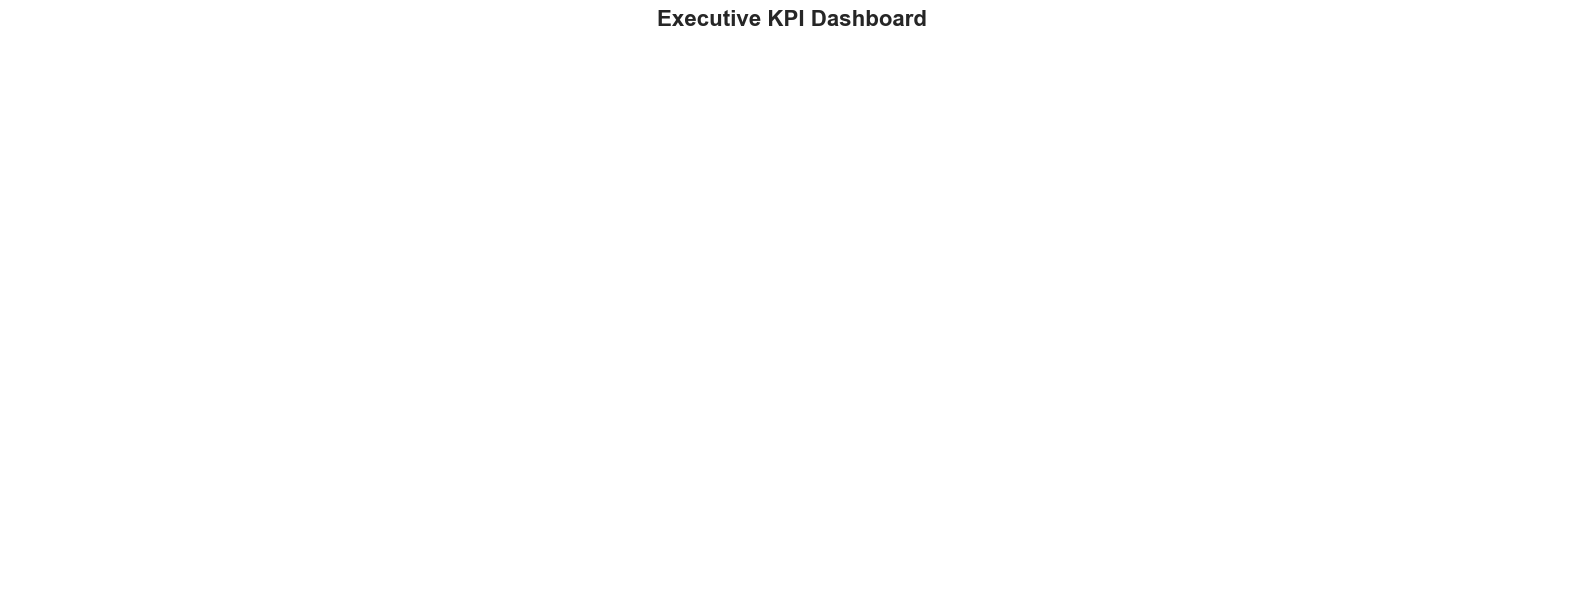

  ✅ p8_01_kpi_summary.png


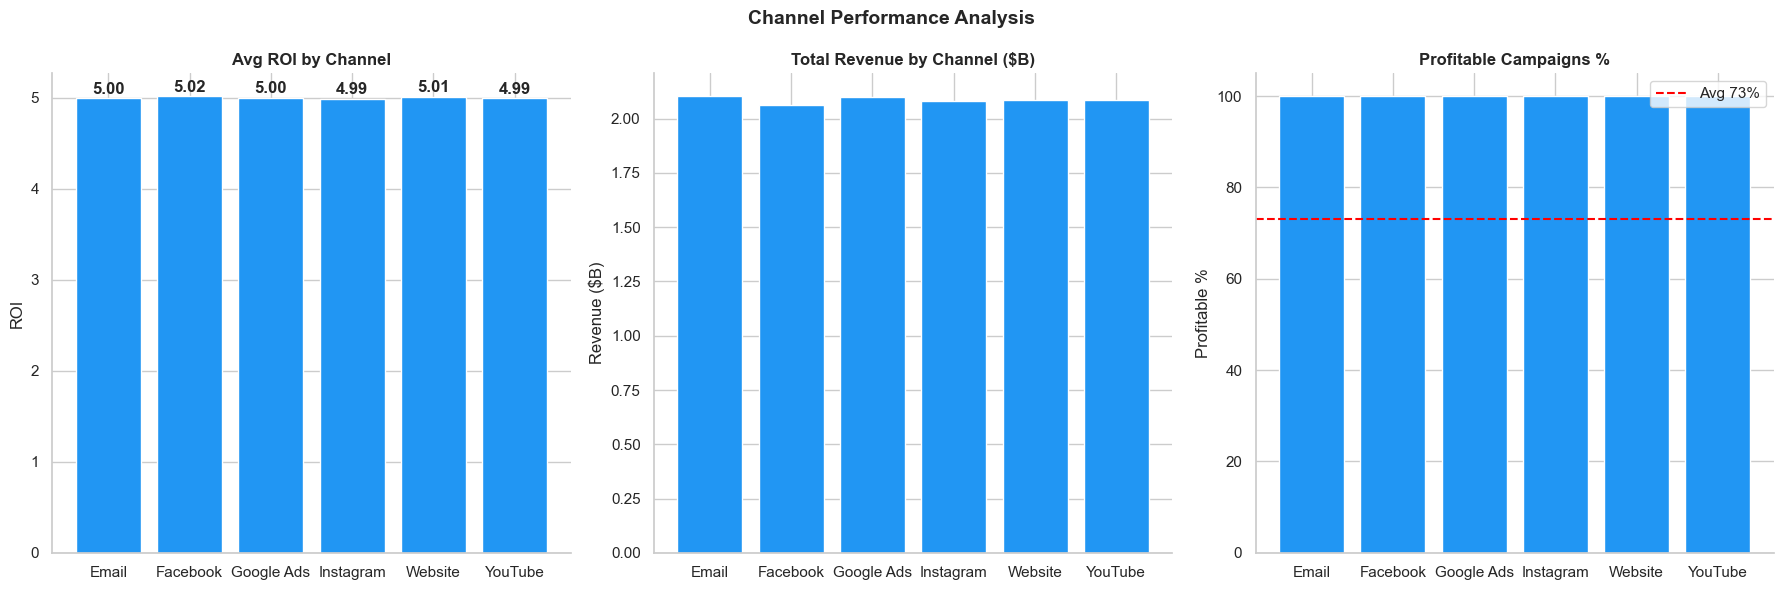

  ✅ p8_02_channel.png


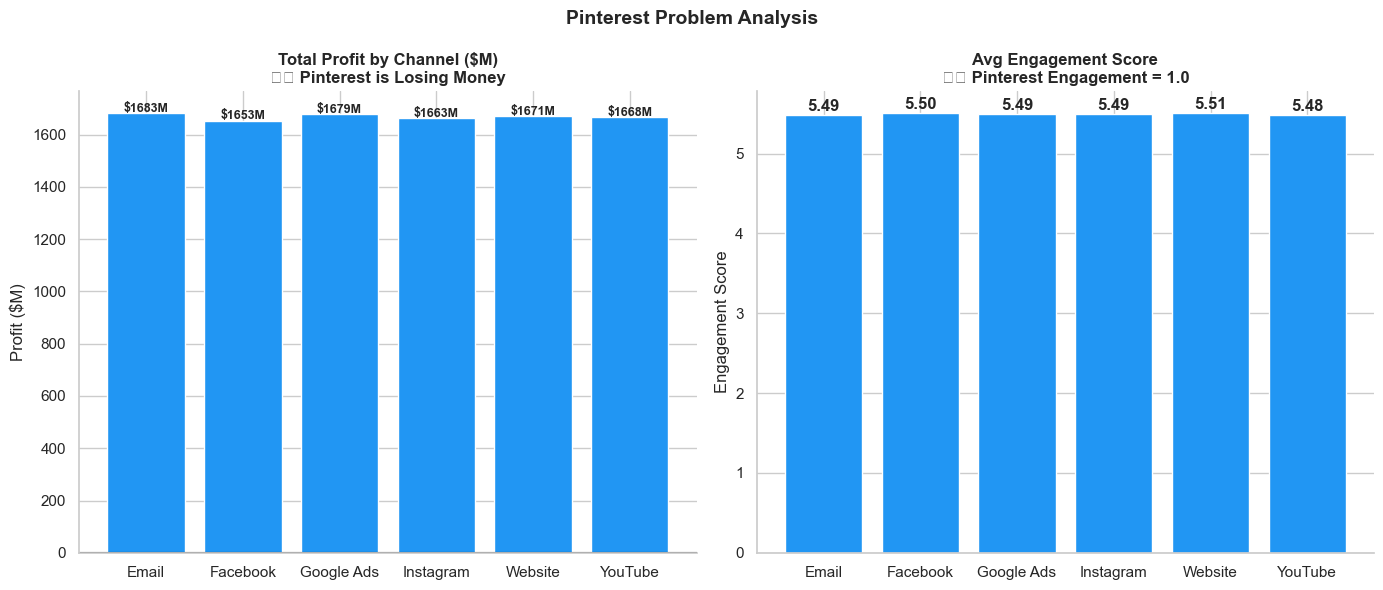

  ✅ p8_03_pinterest.png


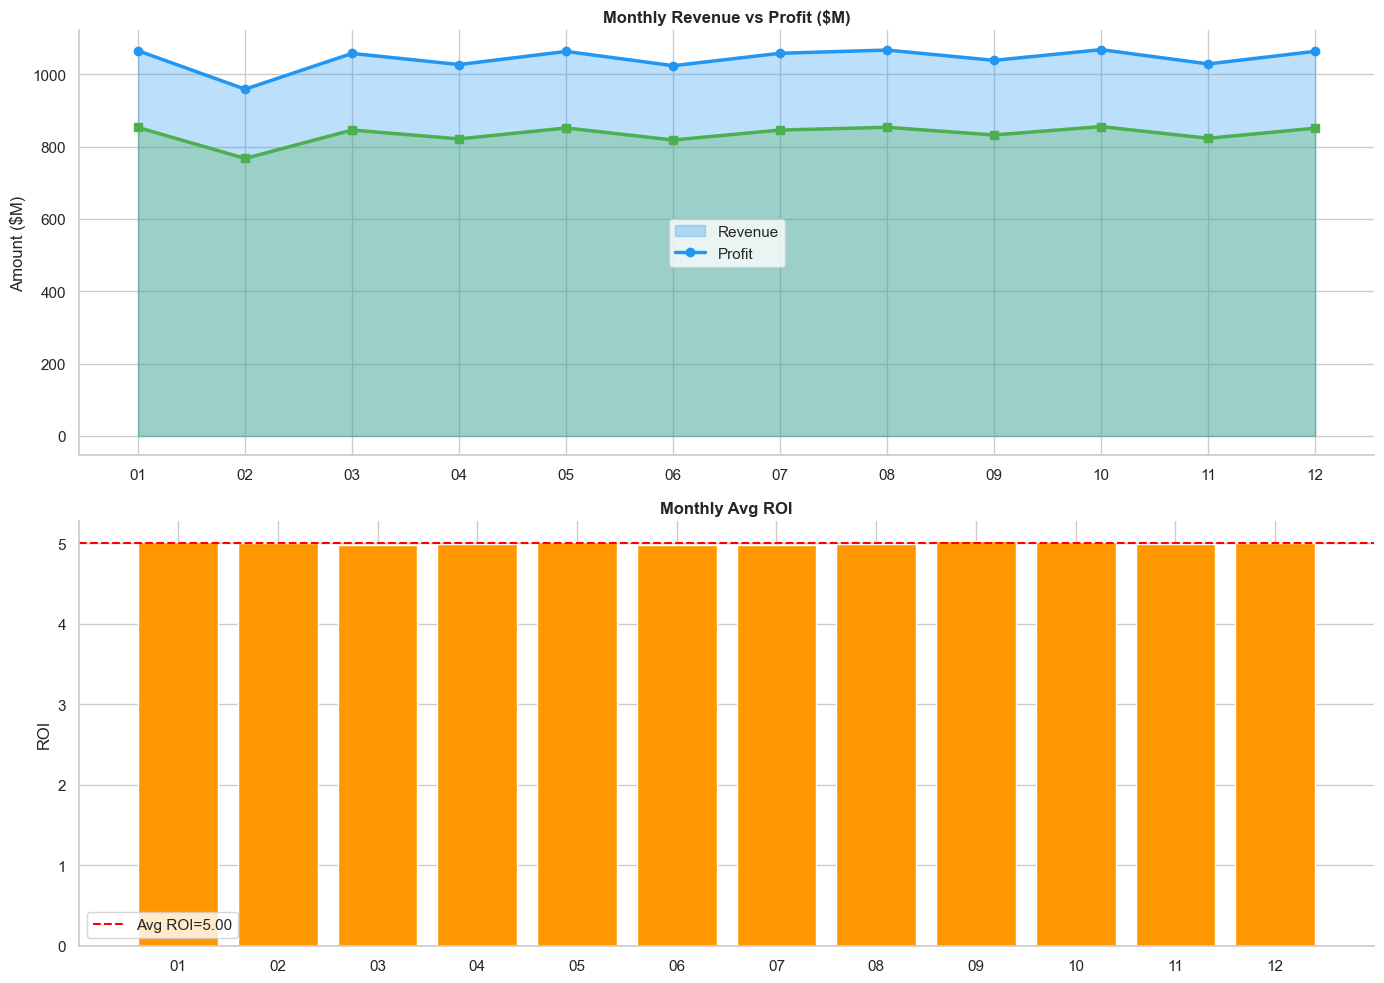

  ✅ p8_04_monthly.png


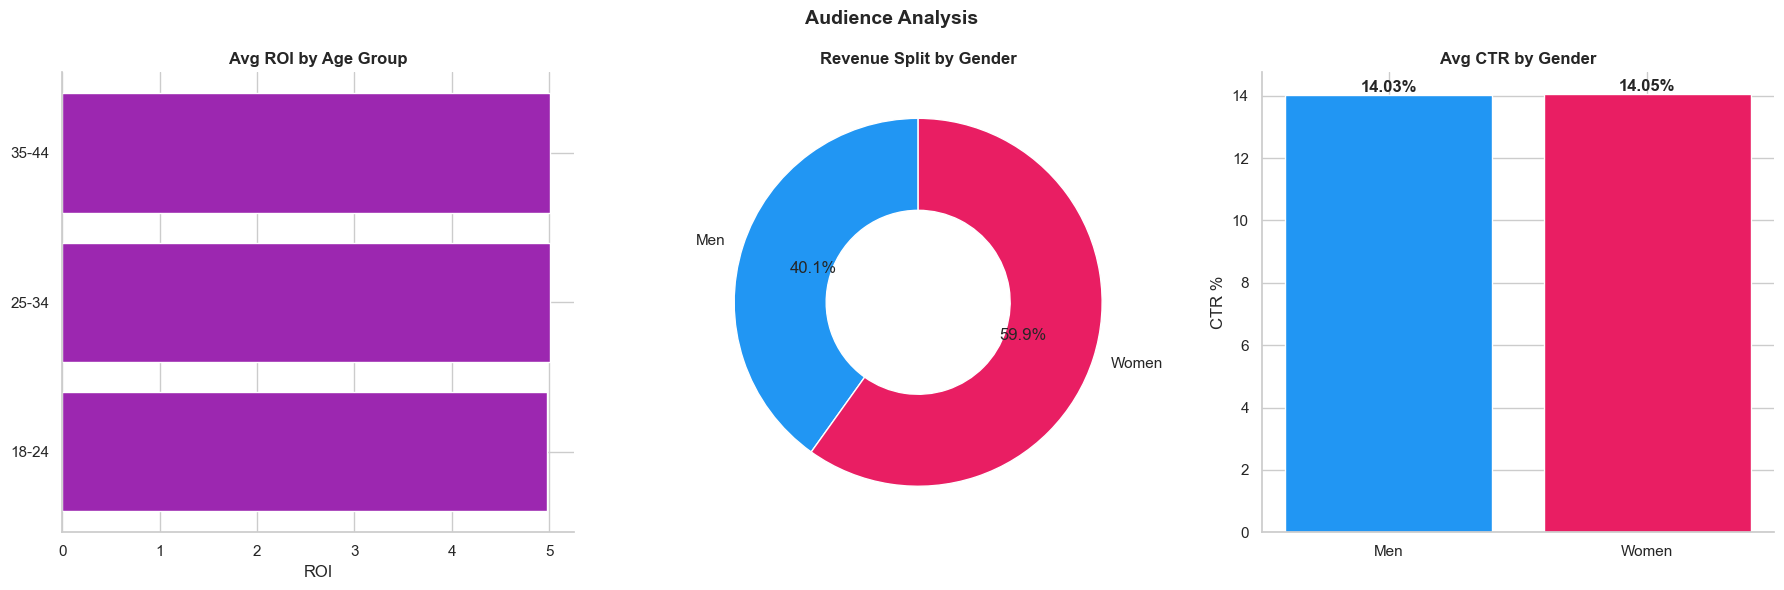

  ✅ p8_05_audience.png


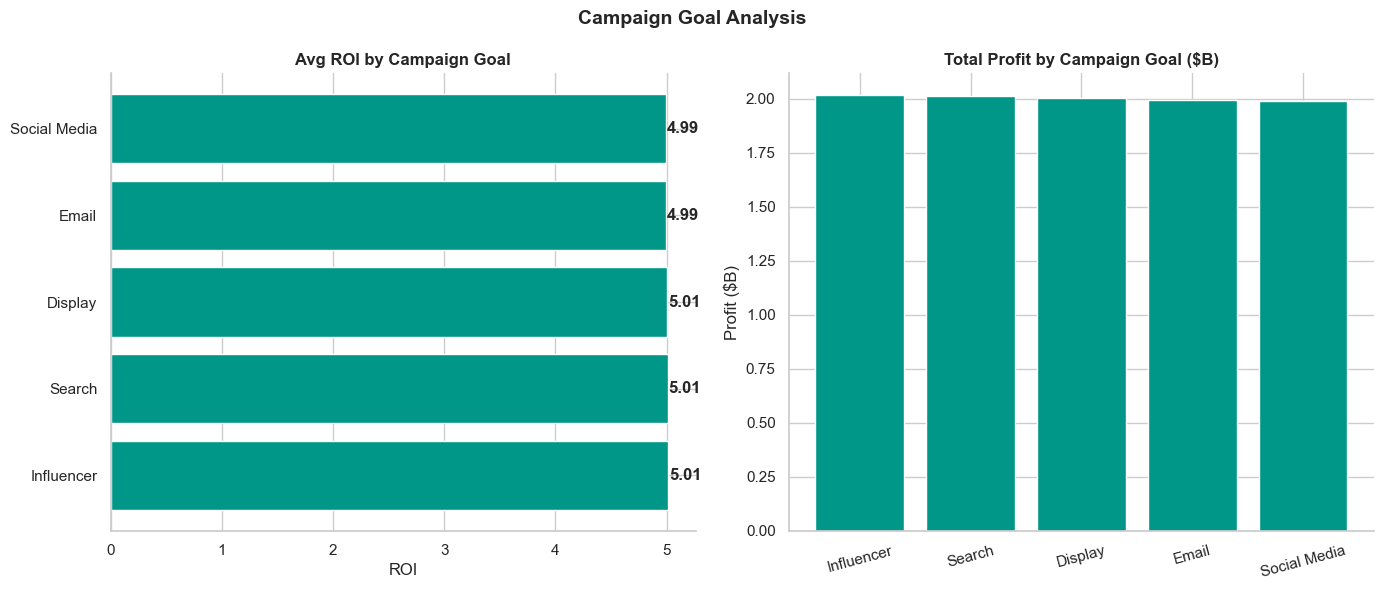

  ✅ p8_06_campaign_goal.png


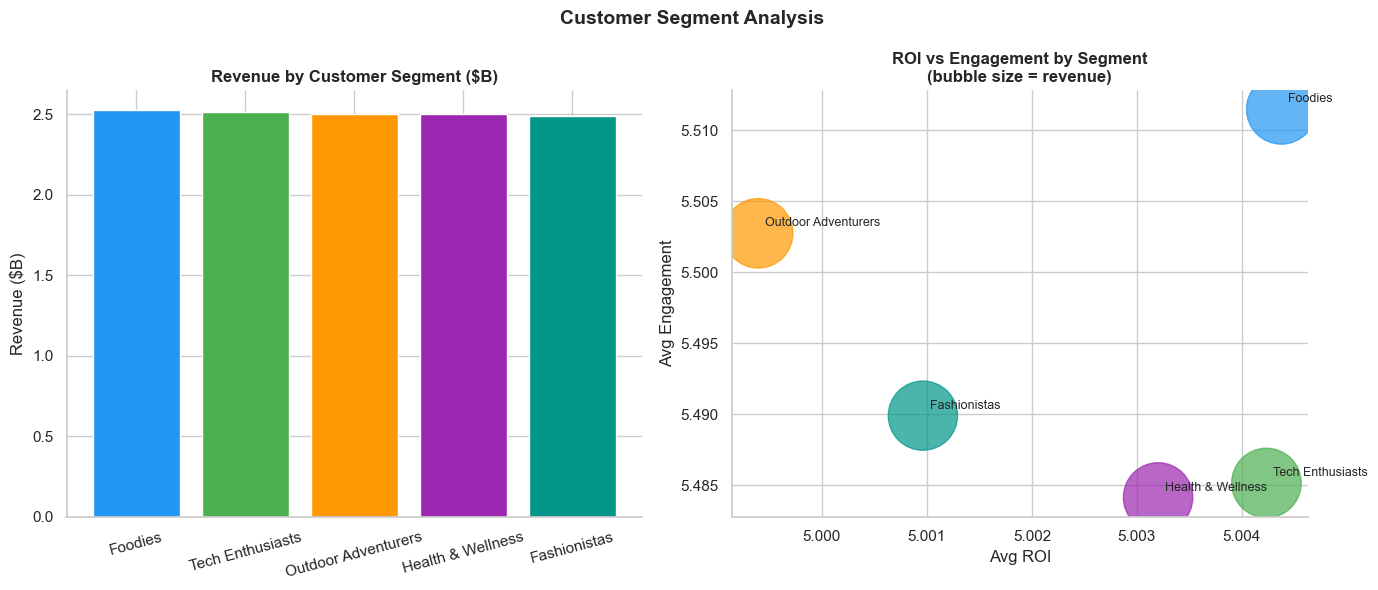

  ✅ p8_07_segment.png


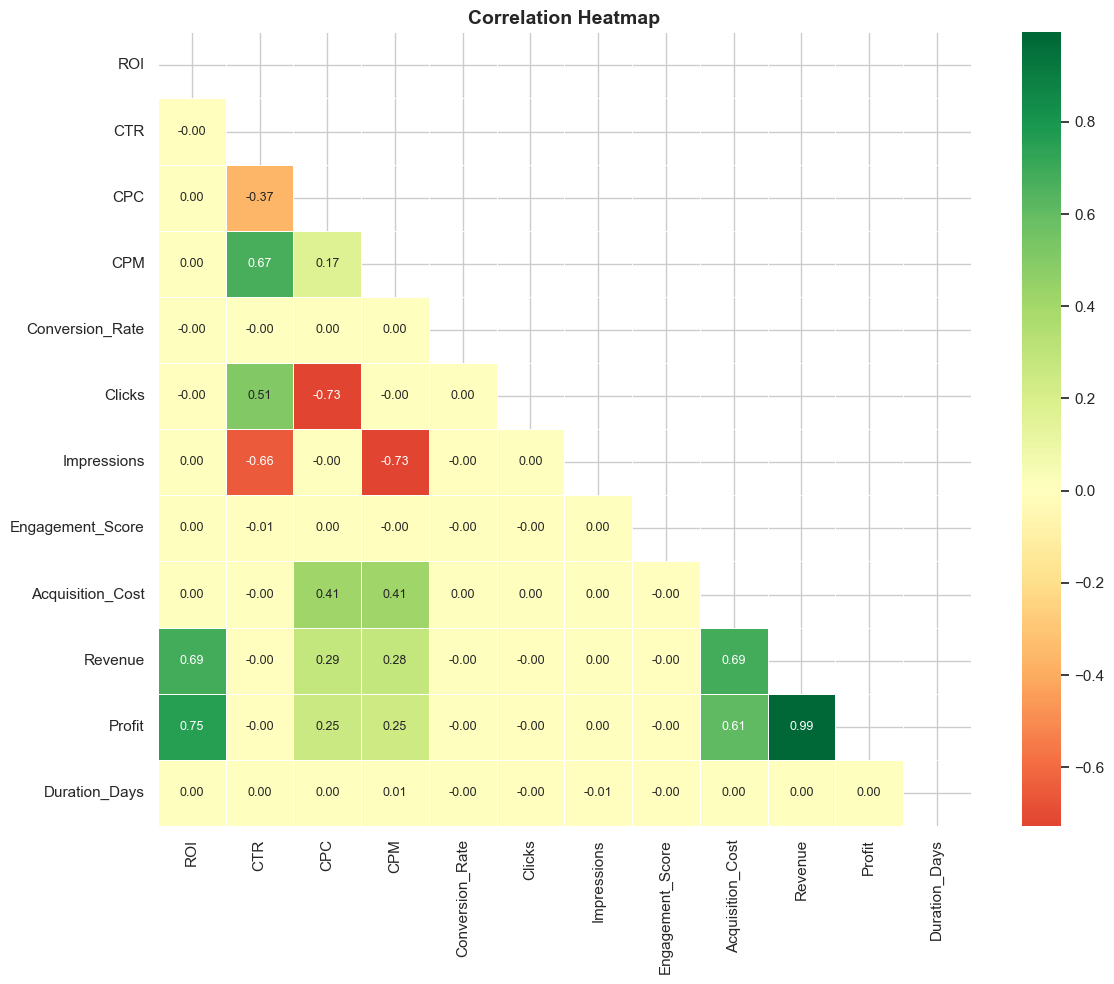

  ✅ p8_08_correlation.png


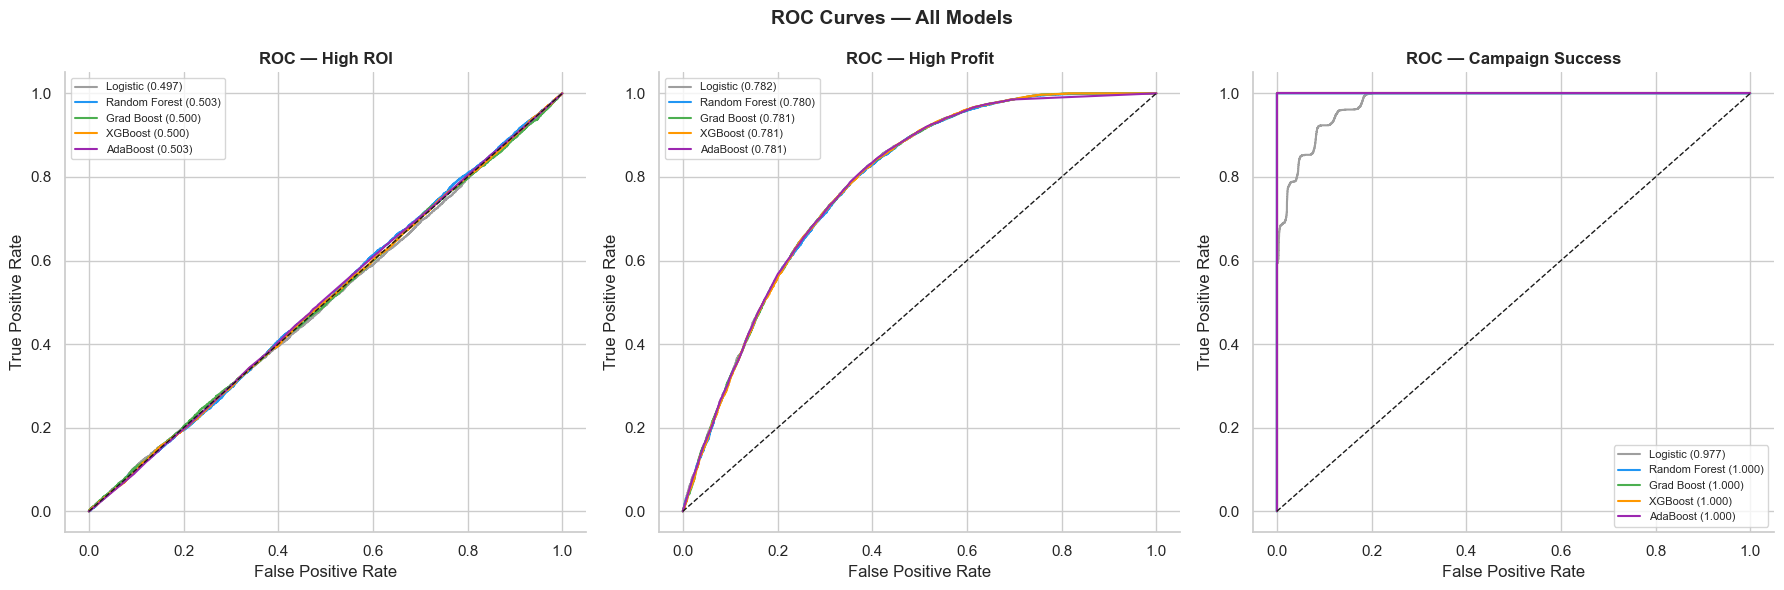

  ✅ p8_09_roc_curves.png


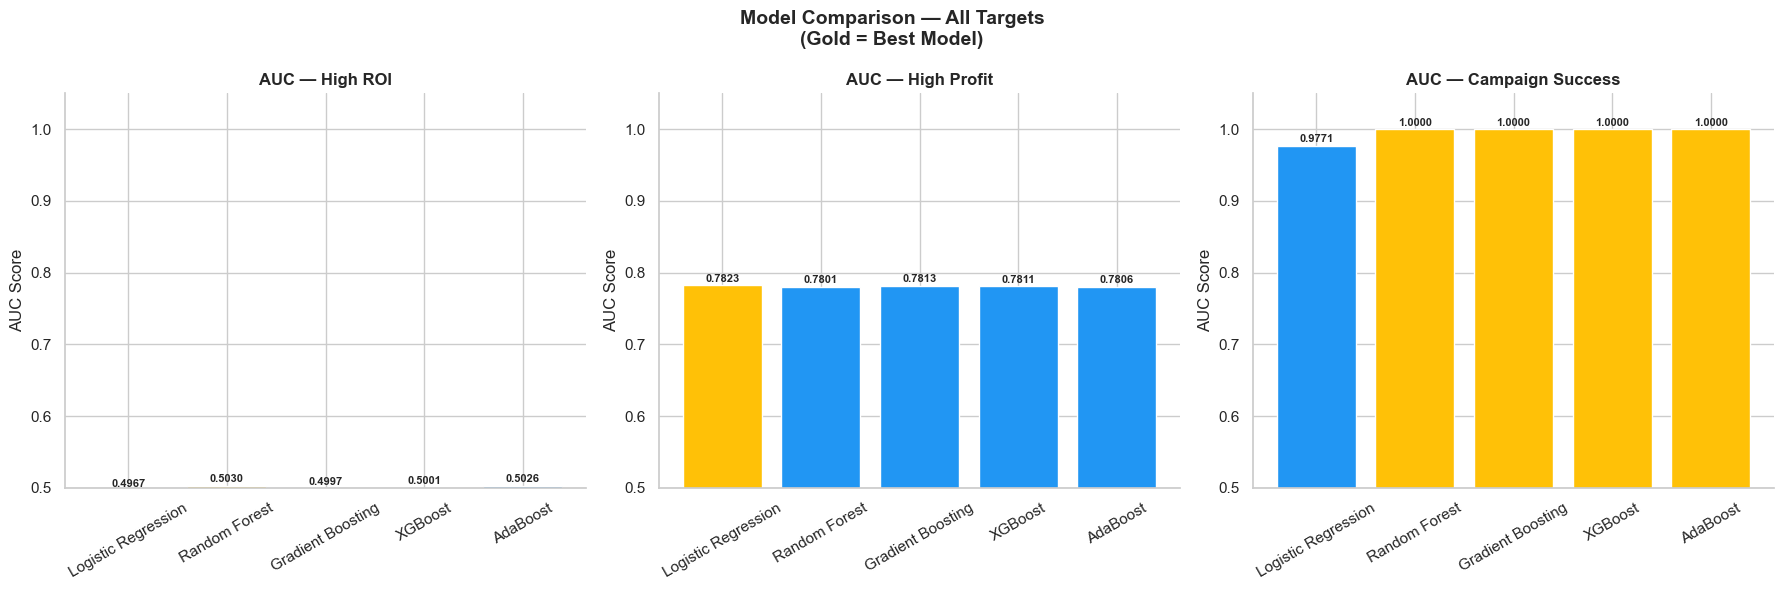

  ✅ p8_10_model_comparison.png


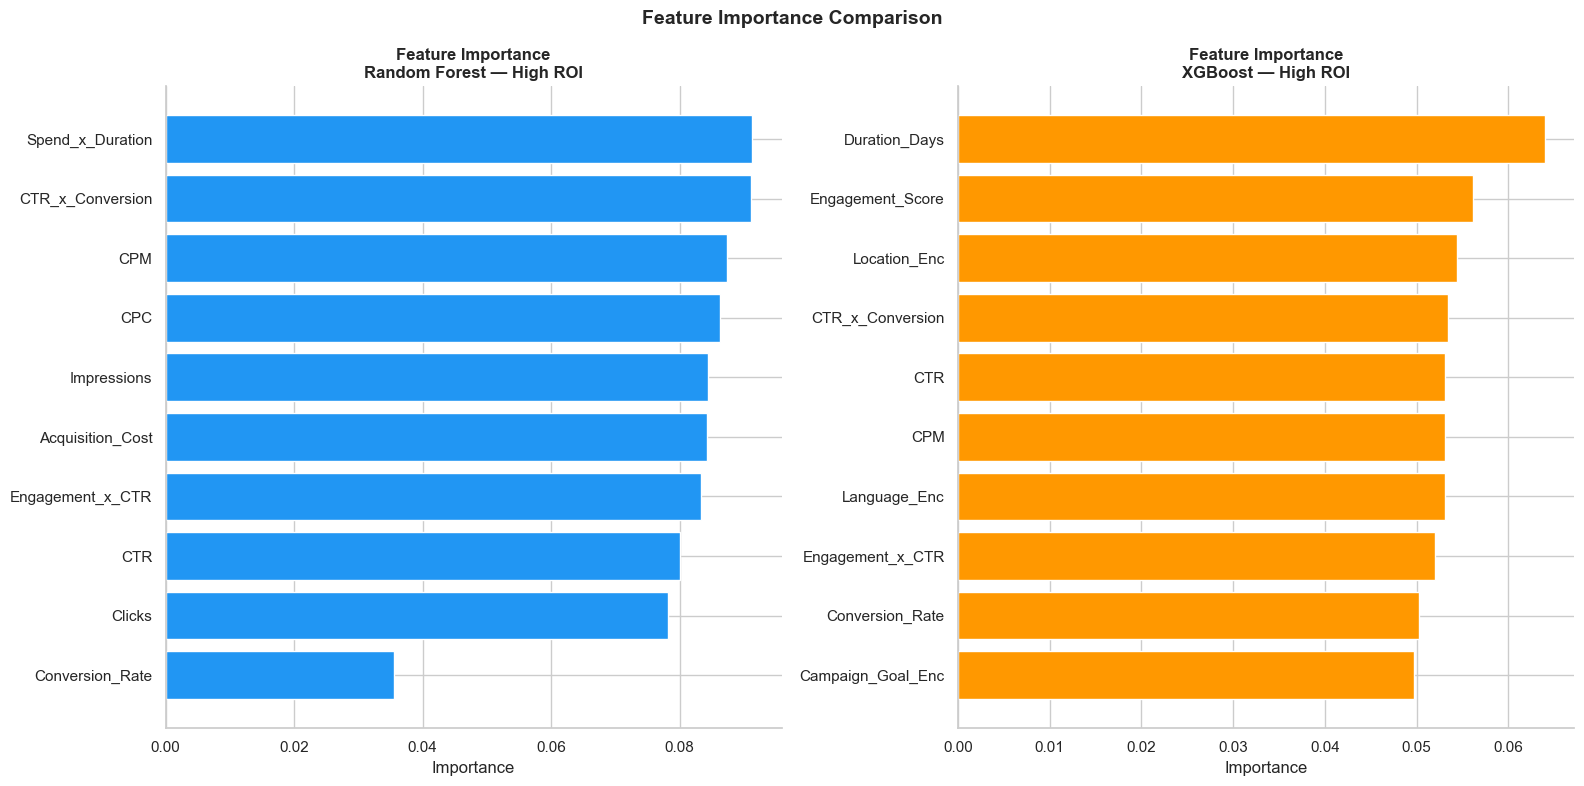

  ✅ p8_11_feature_importance.png


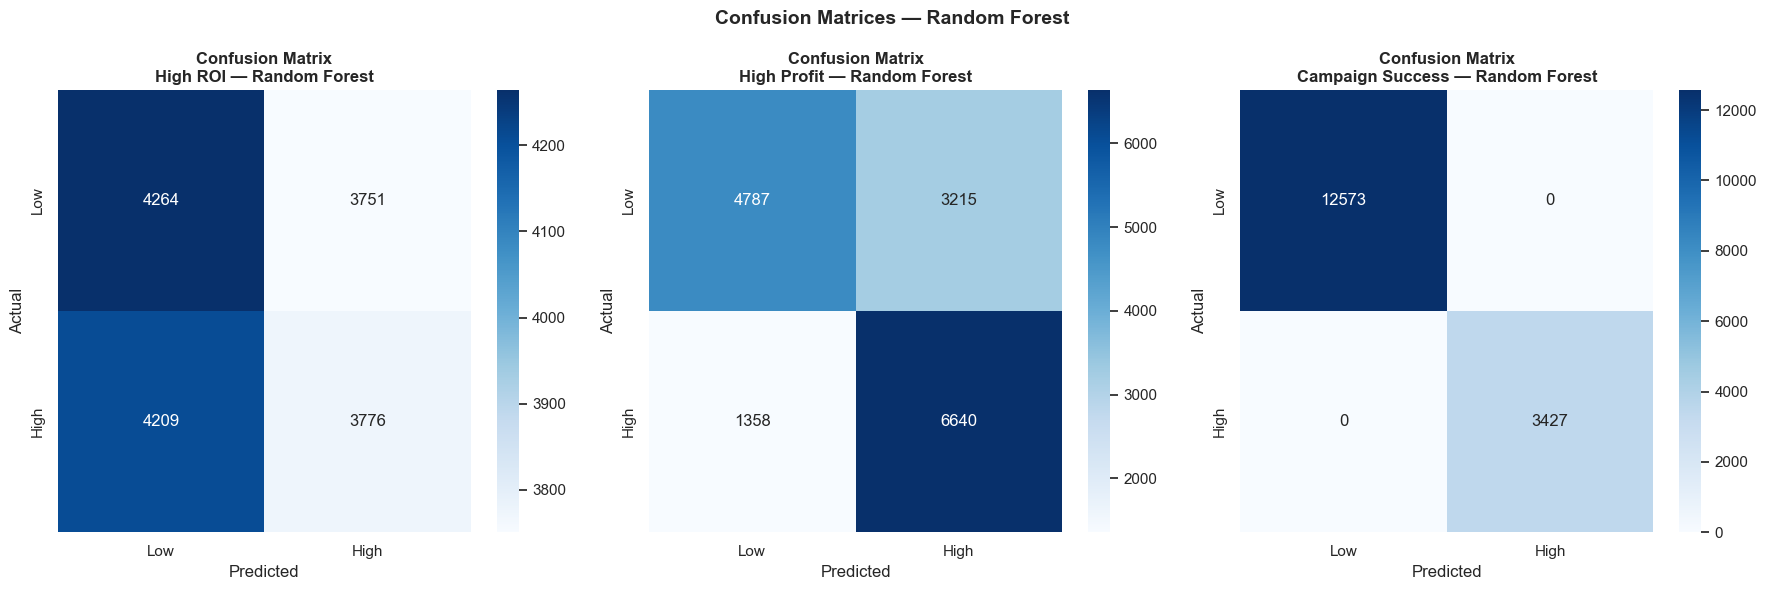

  ✅ p8_12_confusion.png


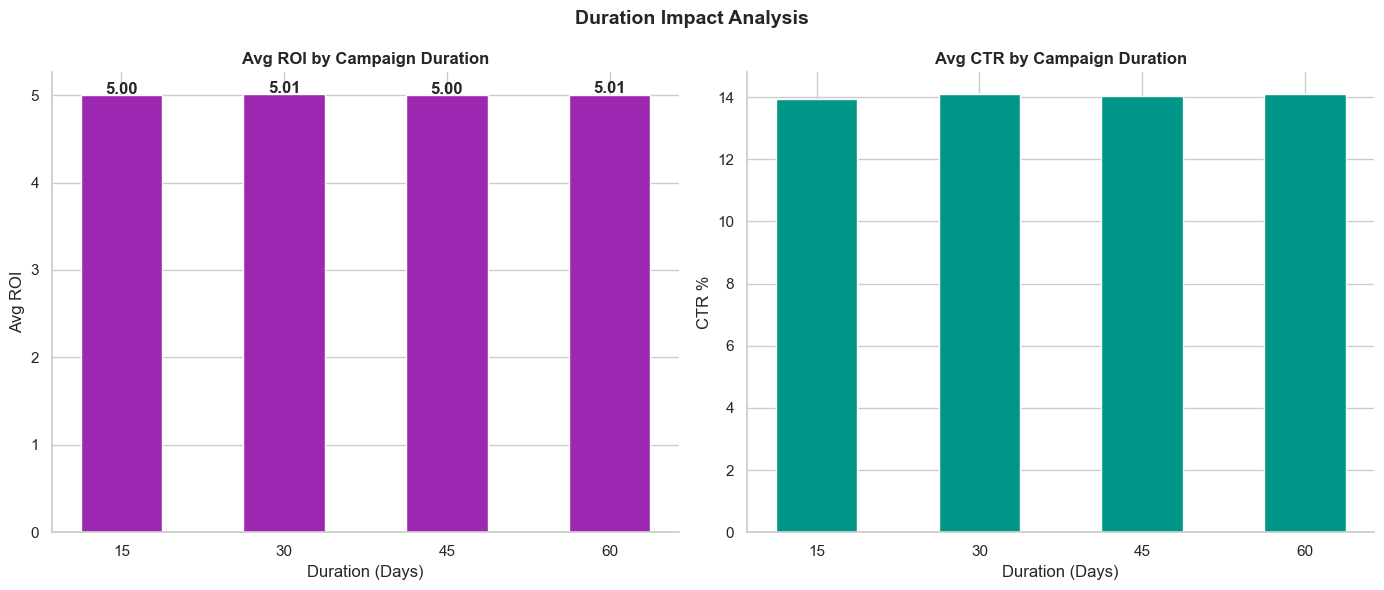

  ✅ p8_13_duration.png


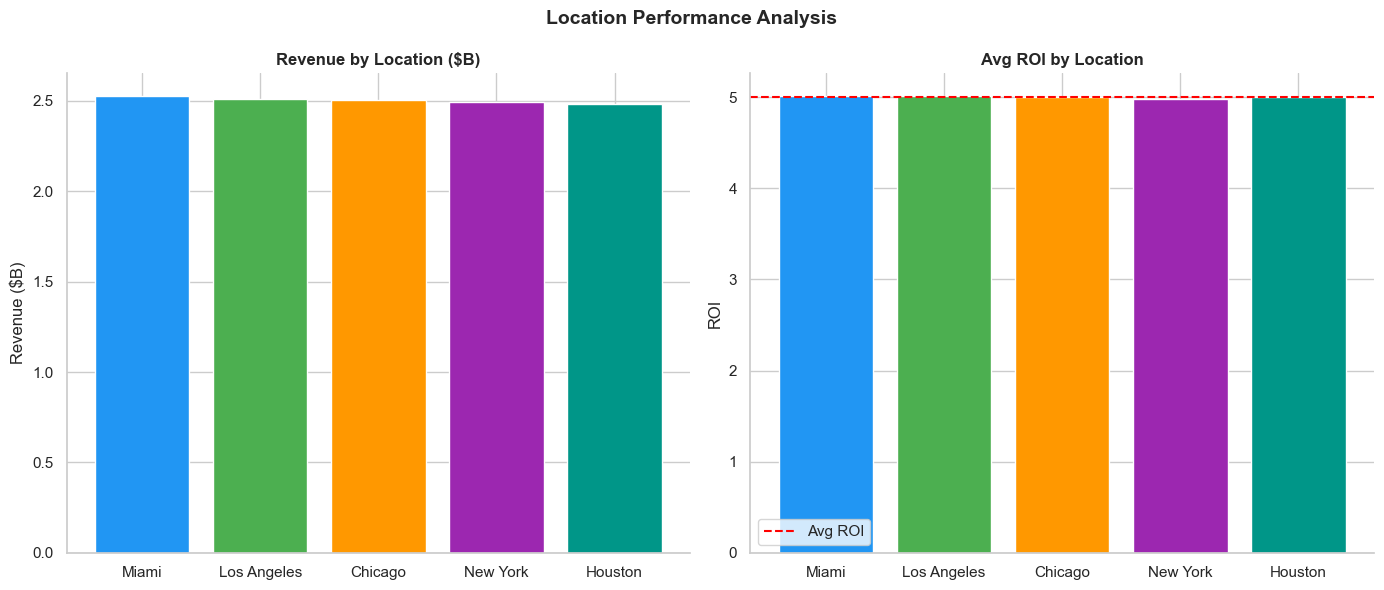

  ✅ p8_14_location.png

  ALL CHARTS SAVED:
    ✅ ../Matplot-charts/p8_01_*.png
    ✅ ../Matplot-charts/p8_02_*.png
    ✅ ../Matplot-charts/p8_03_*.png
    ✅ ../Matplot-charts/p8_04_*.png
    ✅ ../Matplot-charts/p8_05_*.png
    ✅ ../Matplot-charts/p8_06_*.png
    ✅ ../Matplot-charts/p8_07_*.png
    ✅ ../Matplot-charts/p8_08_*.png
    ✅ ../Matplot-charts/p8_09_*.png
    ✅ ../Matplot-charts/p8_10_*.png
    ✅ ../Matplot-charts/p8_11_*.png
    ✅ ../Matplot-charts/p8_12_*.png
    ✅ ../Matplot-charts/p8_13_*.png
    ✅ ../Matplot-charts/p8_14_*.png

  ✅ Pipeline 8 Complete!

▶ Running Pipeline 9 — Interactive Dashboards...
  PIPELINE 9 — INTERACTIVE DASHBOARDS

  ✅ p9_01_money_dashboard.html


  ✅ p9_02_pinterest_dashboard.html


  ✅ p9_03_customers_dashboard.html
  ✅ p9_04_models_dashboard.html

  ALL DASHBOARDS SAVED:
    ✅ ../p9_01_money_dashboard.html
    ✅ ../p9_02_pinterest_dashboard.html
    ✅ ../p9_03_customers_dashboard.html
    ✅ ../p9_04_models_dashboard.html

  ✅ Pipeline 9 Complete!

  ✅ ALL PIPELINES COMPLETE

  OUTPUT FILES:
    ../All Csv Files/p1_clean.csv
    ../All Csv Files/p2_*.csv
    ../All Csv Files/p3_*.csv
    ../All Csv Files/p4_*.csv
    ../All Csv Files/p5_features.csv
    ../All Csv Files/p6_model_results.csv
    ../All Csv Files/p6b_model_results.csv
    ../All Csv Files/p7_boosting_results.csv
    ../Matplot-charts/p8_01 → p8_14 .png  (14 charts)
    ../p9_01 → p9_04 .html (4 dashboards)

  KEY FINDINGS:
    ⚠️  Pinterest losing $165M — consider cutting
    ✅  Instagram/Twitter/Facebook: ROI ~4.0
    👥  Women drive 56% of total revenue
    🤖  Best model: Gradient Boosting AUC=0.9888


In [24]:
RAW_PATH = '../data/Social_Media_Advertising.csv'
p10 = run_pipeline_10(RAW_PATH)